# Dynamic State-Space Model for Manchester City

## 1.1 Data Alignment

The first stage aligns Manchester City's match-level FBref performance data
with the Bayesian structural strength estimates developed in the previous
modeling stage.

The objective is to construct a match-level dataset in which each Manchester
City fixture contains:

- Manchester City's structural strength;
- the opponent's structural strength;
- venue information;
- observed match-performance variables from FBref.

## 1.2 Construction of the Raw Match-State Vector

Each Premier League fixture is represented by a compact observable
performance vector describing Manchester City's match state.

To limit dimensionality relative to the available sample size, the initial
state representation contains four interpretable dimensions:

$$
\mathbf{x}_t =
[
PossDiff_t,\,
ShotDiff_t,\,
SOTRateDiff_t,\,
FinishingDiff_t
]^T
$$

where each component measures Manchester City's performance relative to its
opponent within the same match.

This raw state does not yet account for opponent strength or venue. These
effects are introduced in the next stage through the Bayesian structural
strength baseline.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==================================================
# Step 1: Construct Manchester City match-state data
# ==================================================

HERE = Path.cwd()

city_files = {
    "2023/24": HERE / "Manchester_City_FBref_2023_2024.xlsx",
    "2024/25": HERE / "Manchester_City_FBref_2024_2025.xlsx",
    "2025/26": HERE / "Manchester_City_FBref_2025_2026.xlsx",
}

season_data = []

for season, file in city_files.items():

    # Shooting is used as the match-level backbone
    shooting = pd.read_excel(
        file,
        sheet_name="Shooting"
    )

    # Some workbooks contain multiple competitions
    if "Comp" in shooting.columns:
        shooting = shooting[
            shooting["Comp"] == "Premier League"
        ].copy()

    shooting["Date"] = pd.to_datetime(
        shooting["Date"]
    )

    shooting["Season"] = season

    season_data.append(shooting)


# Combine seasons chronologically
city_matches = pd.concat(
    season_data,
    ignore_index=True
)

city_matches = (
    city_matches
    .sort_values("Date")
    .reset_index(drop=True)
)

In [2]:
# ==================================================
# Construct observable state variables
# ==================================================

# 1. Possession advantage
city_matches["Poss_Diff"] = (
    2 * city_matches["Poss"] - 100
)

# 2. Shot-volume advantage
city_matches["Shot_Diff"] = (
    city_matches["Sh"]
    - city_matches["against_Sh"]
)

# 3. Shot-on-target rate advantage
city_matches["SOT_Rate_Diff"] = (
    city_matches["SoT%"]
    - city_matches["against_SoT%"]
)

# 4. Finishing advantage
city_matches["Finishing_Diff"] = (
    city_matches["G/Sh"]
    - city_matches["against_G/Sh"]
)

In [3]:
# ==================================================
# Final raw state table
# ==================================================

state_vars = [
    "Poss_Diff",
    "Shot_Diff",
    "SOT_Rate_Diff",
    "Finishing_Diff"
]

city_state_raw = city_matches[
    [
        "Season",
        "Date",
        "Venue",
        "Opponent",
        "GF",
        "GA"
    ]
    + state_vars
].copy()

display(city_state_raw.head(10))

,Season,Date,Venue,Opponent,GF,GA,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
0,2023/24,2023-08-11,Away,Burnley,3,0,32,11,30.4,0.18
1,2023/24,2023-08-19,Home,Newcastle,1,0,20,7,14.3,0.07
2,2023/24,2023-08-27,Away,Sheffield United,2,1,60,24,-3.3,-0.10
3,2023/24,2023-09-02,Home,Fulham,5,1,36,1,4.7,0.54
4,2023/24,2023-09-16,Away,West Ham,3,1,38,23,1.7,-0.07
5,2023/24,2023-09-23,Home,Nottingham,2,0,14,-3,27.1,0.29
6,2023/24,2023-09-30,Away,Wolves,1,2,36,20,1.5,-0.29
7,2023/24,2023-10-08,Away,Arsenal,0,1,2,-8,8.3,-0.08
8,2023/24,2023-10-21,Home,Brighton,2,1,10,5,0.0,0.00
9,2023/24,2023-10-29,Away,Manchester Utd,3,0,22,14,4.7,0.14


In [4]:
# ==================================================
# Sanity check
# ==================================================

print("Matches per season:")
print(city_state_raw.groupby("Season").size())

print("\nMissing state values:")
print(city_state_raw[state_vars].isna().sum())

assert len(city_state_raw) == 114
assert city_state_raw[state_vars].notna().all().all()

print("\nRaw match-state construction passed.")

Matches per season:
Season
2023/24    38
2024/25    38
2025/26    38
dtype: int64

Missing state values:
Poss_Diff         0
Shot_Diff         0
SOT_Rate_Diff     0
Finishing_Diff    0
dtype: int64

Raw match-state construction passed.


## 2. Expected Performance Baseline

Raw match statistics cannot be interpreted independently of match difficulty.
A given level of possession or shot dominance may represent strong performance
against an elite opponent but underperformance against a substantially weaker
team.

For each observable state variable, the expected match performance is modeled
as a function of Manchester City's pre-match Bayesian strength advantage and
venue:

$$
x_{t,j}
=
\alpha_j
+
\beta_j\Delta S_t
+
\gamma_j Home_t
+
\epsilon_{t,j}
$$

where

$$
\Delta S_t = S_{City,t} - S_{Opponent,t}.
$$

The strength-adjusted residual is then defined as

$$
r_{t,j}
=
x_{t,j}
-
\hat{E}[x_{t,j}\mid\Delta S_t,Home_t].
$$

These residuals represent Manchester City's performance relative to the level
expected from structural team strength and venue.

In [5]:
# ==================================================
# 2.1: Load pre-match Bayesian strength history
# ==================================================

PROJECT_ROOT = HERE.parent.parent

PROCESSED = (
    PROJECT_ROOT
    / "processed_data"
    / "processed"
)

bayes_history = pd.read_csv(
    PROCESSED / "bayesian_match_strength_history.csv"
)

# CSV dates are stored as DD/MM/YYYY
bayes_history["Date"] = pd.to_datetime(
    bayes_history["Date"],
    dayfirst=True
)

# Match FBref season format
bayes_history["Season"] = (
    bayes_history["Season"]
    .str.replace("-", "/", regex=False)
)

print("Bayesian match history:", bayes_history.shape)
print("Seasons:", bayes_history["Season"].unique())

Bayesian match history: (1520, 8)
Seasons: ['2022/23' '2023/24' '2024/25' '2025/26']


In [6]:
# ==================================================
# 2.2: Extract Manchester City pre-match strengths
# ==================================================

city_bayes = bayes_history[
    (bayes_history["HomeTeam"] == "Man City")
    |
    (bayes_history["AwayTeam"] == "Man City")
].copy()

city_is_home = (
    city_bayes["HomeTeam"] == "Man City"
)

# Match City venue
city_bayes["Venue"] = np.where(
    city_is_home,
    "Home",
    "Away"
)

# Opponent
city_bayes["Opponent_Bayes"] = np.where(
    city_is_home,
    city_bayes["AwayTeam"],
    city_bayes["HomeTeam"]
)

# City's strength BEFORE the match
city_bayes["S_City"] = np.where(
    city_is_home,
    city_bayes["Home_Mean_Pre"],
    city_bayes["Away_Mean_Pre"]
)

# Opponent's strength BEFORE the match
city_bayes["S_Opp"] = np.where(
    city_is_home,
    city_bayes["Away_Mean_Pre"],
    city_bayes["Home_Mean_Pre"]
)

# Relative structural strength
city_bayes["Delta_S"] = (
    city_bayes["S_City"]
    - city_bayes["S_Opp"]
)

# We only need the three FBref seasons
city_bayes = city_bayes[
    city_bayes["Season"].isin(
        ["2023/24", "2024/25", "2025/26"]
    )
].copy()

print("City Bayesian matches:", len(city_bayes))

display(
    city_bayes[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent_Bayes",
            "S_City",
            "S_Opp",
            "Delta_S"
        ]
    ].head()
)

City Bayesian matches: 114


,Season,Date,Venue,Opponent_Bayes,S_City,S_Opp,Delta_S
380,2023/24,2023-08-11,Away,Burnley,4.044898,-1.486890,5.531788
393,2023/24,2023-08-19,Home,Newcastle,4.205943,2.027340,2.178603
408,2023/24,2023-08-27,Away,Sheffield United,4.180046,-1.685135,5.865181
414,2023/24,2023-09-02,Home,Fulham,4.051851,-0.509849,4.561699
424,2023/24,2023-09-16,Away,West Ham,4.288938,0.079825,4.209113


In [7]:
# ==================================================
# Standardize opponent names
# ==================================================

opponent_name_map = {
    "Manchester Utd": "Man United",
    "Nottingham": "Nott'm Forest",
    "Nott'ham Forest": "Nott'm Forest",
    "Sheffield Utd": "Sheffield United",
    "Luton Town": "Luton",
    "Ipswich Town": "Ipswich",
    "Leicester City": "Leicester",
    "Leeds United": "Leeds",
    "Manchester City": "Man City"
}

city_state_raw["Opponent_Key"] = (
    city_state_raw["Opponent"]
    .replace(opponent_name_map)
)

city_bayes["Opponent_Key"] = (
    city_bayes["Opponent_Bayes"]
)

In [8]:
# ==================================================
# Align FBref state with Bayesian structural strength
# ==================================================

city_model_base = city_state_raw.merge(
    city_bayes[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent_Key",
            "S_City",
            "S_Opp",
            "Delta_S"
        ]
    ],
    on=[
        "Season",
        "Date",
        "Venue",
        "Opponent_Key"
    ],
    how="left",
    validate="one_to_one"
)

print("Total matches:", len(city_model_base))

print("\nMissing Bayesian values:")
print(
    city_model_base[
        ["S_City", "S_Opp", "Delta_S"]
    ].isna().sum()
)

assert len(city_model_base) == 114

assert (
    city_model_base[
        ["S_City", "S_Opp", "Delta_S"]
    ]
    .notna()
    .all()
    .all()
)

print("\nBayesian strength alignment passed.")

Total matches: 114

Missing Bayesian values:
S_City     0
S_Opp      0
Delta_S    0
dtype: int64

Bayesian strength alignment passed.


In [9]:
import statsmodels.api as sm
import pandas as pd

# ==================================================
# 2.3 Estimate expected-performance baseline
# ==================================================

baseline_data = city_model_base.copy()

# Home indicator
baseline_data["Home"] = (
    baseline_data["Venue"] == "Home"
).astype(int)

# Explanatory variables
X = baseline_data[
    ["Delta_S", "Home"]
].copy()

X = sm.add_constant(X)

baseline_models = {}
baseline_results = []

for var in state_vars:

    y = baseline_data[var]

    model = sm.OLS(y, X).fit()

    baseline_models[var] = model

    baseline_results.append({
        "Variable": var,
        "Intercept": model.params["const"],
        "Delta_S_coef": model.params["Delta_S"],
        "Home_coef": model.params["Home"],
        "R_squared": model.rsquared
    })

baseline_summary = pd.DataFrame(
    baseline_results
)

display(
    baseline_summary.round(3)
)

,Variable,Intercept,Delta_S_coef,Home_coef,R_squared
0,Poss_Diff,7.179,5.142,2.677,0.226
1,Shot_Diff,-2.246,2.356,4.439,0.236
2,SOT_Rate_Diff,3.716,-0.493,-3.795,0.008
3,Finishing_Diff,-0.004,0.002,0.003,0.000


In [10]:
# ==================================================
# 2.4 Construct strength-adjusted residual states
# ==================================================

residual_vars = []

for var in state_vars:

    model = baseline_models[var]

    expected_col = f"Expected_{var}"
    residual_col = f"r_{var}"

    # Expected performance
    baseline_data[expected_col] = (
        model.predict(X)
    )

    # Actual - expected
    baseline_data[residual_col] = (
        baseline_data[var]
        - baseline_data[expected_col]
    )

    residual_vars.append(residual_col)

In [11]:
# ==================================================
# Inspect strength-adjusted performance
# ==================================================

display_cols = [
    "Season",
    "Date",
    "Venue",
    "Opponent",
    "Delta_S"
]

for var in state_vars:
    display_cols += [
        var,
        f"Expected_{var}",
        f"r_{var}"
    ]

display(
    baseline_data[
        display_cols
    ].head(10).round(3)
)

,Season,Date,Venue,Opponent,Delta_S,Poss_Diff,Expected_Poss_Diff,r_Poss_Diff,Shot_Diff,Expected_Shot_Diff,r_Shot_Diff,SOT_Rate_Diff,Expected_SOT_Rate_Diff,r_SOT_Rate_Diff,Finishing_Diff,Expected_Finishing_Diff,r_Finishing_Diff
0,2023/24,2023-08-11,Away,Burnley,5.532,32,35.621,-3.621,11,10.787,0.213,30.4,0.992,29.408,0.18,0.006,0.174
1,2023/24,2023-08-19,Home,Newcastle,2.179,20,21.057,-1.057,7,7.326,-0.326,14.3,-1.152,15.452,0.07,0.003,0.067
2,2023/24,2023-08-27,Away,Sheffield United,5.865,60,37.335,22.665,24,11.572,12.428,-3.3,0.827,-4.127,-0.10,0.007,-0.107
3,2023/24,2023-09-02,Home,Fulham,4.562,36,33.310,2.690,1,12.940,-11.940,4.7,-2.326,7.026,0.54,0.008,0.532
4,2023/24,2023-09-16,Away,West Ham,4.209,38,28.820,9.180,23,7.671,15.329,1.7,1.643,0.057,-0.07,0.004,-0.074
5,2023/24,2023-09-23,Home,Nottingham,5.913,14,40.258,-26.258,-3,16.124,-19.124,27.1,-2.992,30.092,0.29,0.010,0.280
6,2023/24,2023-09-30,Away,Wolves,5.850,36,37.256,-1.256,20,11.536,8.464,1.5,0.835,0.665,-0.29,0.007,-0.297
7,2023/24,2023-10-08,Away,Arsenal,1.669,2,15.761,-13.761,-8,1.687,-9.687,8.3,2.894,5.406,-0.08,-0.001,-0.079
8,2023/24,2023-10-21,Home,Brighton,2.816,10,24.335,-14.335,5,8.828,-3.828,0.0,-1.466,1.466,0.00,0.004,-0.004
9,2023/24,2023-10-29,Away,Manchester Utd,3.453,22,24.932,-2.932,14,5.889,8.111,4.7,2.015,2.685,0.14,0.002,0.138


In [12]:
# ==================================================
# Residual sanity check
# ==================================================

residual_check = (
    baseline_data[residual_vars]
    .mean()
    .to_frame("Mean residual")
)

display(residual_check.round(6))

assert (
    baseline_data[residual_vars]
    .notna()
    .all()
    .all()
)

print("Strength-adjusted residual construction passed.")

,Mean residual
r_Poss_Diff,0.0
r_Shot_Diff,0.0
r_SOT_Rate_Diff,-0.0
r_Finishing_Diff,0.0


Strength-adjusted residual construction passed.


## 3. Temporal Structure Analysis

Before introducing a dynamic state-space model, the strength-adjusted residuals
are tested for temporal dependence.

If Manchester City's current performance state contains information about its
subsequent state, then a dynamic transition model is empirically justified.
Otherwise, imposing a state-transition matrix would add structure unsupported
by the data.

Only within-season transitions are used. Cross-season transitions are excluded
because the offseason introduces a long time gap together with possible squad
and tactical changes.

In [13]:
# ==================================================
# 3.1 Construct within-season temporal pairs
# ==================================================

temporal_data = (
    baseline_data
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

# Next-match residuals, calculated within each season
for var in residual_vars:
    temporal_data[f"{var}_next"] = (
        temporal_data
        .groupby("Season")[var]
        .shift(-1)
    )

next_residual_vars = [
    f"{var}_next"
    for var in residual_vars
]

temporal_pairs = temporal_data.dropna(
    subset=next_residual_vars
).copy()

print("Within-season transitions:", len(temporal_pairs))

assert len(temporal_pairs) == 37 * 3

print("Temporal pairing passed.")

Within-season transitions: 111
Temporal pairing passed.


In [14]:
# ==================================================
# 3.2 Lag-1 persistence by state dimension
# ==================================================

persistence_results = []

for var in residual_vars:

    x = temporal_pairs[var]
    y = temporal_pairs[f"{var}_next"]

    X_lag = sm.add_constant(x)

    # HC3 robust standard errors for exploratory inference
    model = sm.OLS(y, X_lag).fit(
        cov_type="HC3"
    )

    persistence_results.append({
        "Variable": var.replace("r_", ""),
        "Lag1_Correlation": x.corr(y),
        "Lag1_Coefficient": model.params[var],
        "P_value": model.pvalues[var],
        "R_squared": model.rsquared
    })

persistence_summary = pd.DataFrame(
    persistence_results
)

display(
    persistence_summary.round(3)
)

,Variable,Lag1_Correlation,Lag1_Coefficient,P_value,R_squared
0,Poss_Diff,0.056,0.056,0.583,0.003
1,Shot_Diff,-0.172,-0.174,0.035,0.030
2,SOT_Rate_Diff,-0.081,-0.081,0.309,0.007
3,Finishing_Diff,-0.101,-0.101,0.205,0.010


In [15]:
# ==================================================
# 3.3 Cross-lag correlation structure
# ==================================================

labels = {
    "r_Poss_Diff": "Poss",
    "r_Shot_Diff": "Shot",
    "r_SOT_Rate_Diff": "SOT Rate",
    "r_Finishing_Diff": "Finishing"
}

cross_lag = pd.DataFrame(
    index=labels.values(),
    columns=labels.values(),
    dtype=float
)

for future_var in residual_vars:
    for current_var in residual_vars:

        cross_lag.loc[
            labels[future_var],
            labels[current_var]
        ] = temporal_pairs[
            current_var
        ].corr(
            temporal_pairs[
                f"{future_var}_next"
            ]
        )

cross_lag.index.name = "Next match"
cross_lag.columns.name = "Current match"

display(
    cross_lag.round(3)
)

Current match,Poss,Shot,SOT Rate,Finishing
Next match,,,,
Poss,0.056,-0.009,0.069,0.036
Shot,0.028,-0.172,0.052,0.075
SOT Rate,0.066,0.001,-0.081,0.010
Finishing,0.156,0.225,-0.100,-0.101


# 4. Historical Backtesting and Bayesian Input Reconstruction

Section 3 found limited exploratory evidence of persistence and cross-variable
lag relationships in Manchester City's strength-adjusted performance. These
results motivate comparisons with simple benchmarks, including a model with
no dynamic correction. They do not establish an out-of-sample forecasting
benefit or provide an estimated transition matrix.

The next objective is to evaluate whether dynamic information improves
predictions beyond the strength-and-venue baseline. This requires historical
inputs constructed with the Bayesian parameter estimates available before
each target season.

This section consolidates existing inputs and reconstructs the required
pre-match strength histories. It reuses the earlier Bayesian MLE results;
it does not estimate those parameters again. The modeling sequence is:

1. Reconstruct historical Bayesian inputs.

2. Fit and evaluate the dynamic candidates using chronological splits.

3. Apply the selected approach to the subsequent season.

The upstream strength and instability representations remain fixed. Since
they were developed in earlier notebooks, and the three dynamic seasons
have already been examined during exploration, the evaluation is described
as a chronological historical backtest conditional on a fixed upstream
representation, rather than an entirely untouched end-to-end holdout.

## 4.1 Chronological Evaluation Periods

The available Manchester City FBref data cover three seasons, each containing
38 Premier League matches.
| Season | Dynamic split | Matches | Planned use |
|---|---|---:|---|
| 2023/24 | Train | 38 | Estimate the performance baseline, residual scaling, and candidate dynamics |
| 2024/25 | Validation | 38 | Select the dynamic model form and Ridge strength |
| 2025/26 | Test | 38 | Evaluate the selected approach |

After model selection, the baseline, scaling, and selected dynamic model
will be refitted using the first two seasons before evaluation on the third.
The test-season results will not be used for repeated tuning.

Only within-season transitions are included: one season supplies 37
transitions, and the first two seasons together supply 74. A transition
represents the next Premier League match, not a fixed number of days.

In [16]:
# ==================================================
# 4.1 Define time-ordered evaluation periods
# ==================================================

split_by_season = {
    "2023/24": "Train",
    "2024/25": "Validation",
    "2025/26": "Test"
}

city_backtest_raw = (
    city_state_raw
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

city_backtest_raw["Home"] = (
    city_backtest_raw["Venue"] == "Home"
).astype(int)

city_backtest_raw["Split"] = (
    city_backtest_raw["Season"].map(split_by_season)
)

assert city_backtest_raw["Split"].notna().all()

split_data = {
    name: city_backtest_raw.loc[
        city_backtest_raw["Split"].eq(name)
    ].copy()
    for name in ["Train", "Validation", "Test"]
}

# Check sample sizes and chronological separation
assert all(len(data) == 38 for data in split_data.values())

assert (
    split_data["Train"]["Date"].max()
    < split_data["Validation"]["Date"].min()
)

assert (
    split_data["Validation"]["Date"].max()
    < split_data["Test"]["Date"].min()
)

split_summary = (
    city_backtest_raw
    .groupby(["Season", "Split"], sort=False)
    .agg(
        N_Matches=("Date", "size"),
        First_Match=("Date", "min"),
        Last_Match=("Date", "max")
    )
    .reset_index()
)

display(split_summary)

,Season,Split,N_Matches,First_Match,Last_Match
0,2023/24,Train,38,2023-08-11,2024-05-19
1,2024/25,Validation,38,2024-08-18,2025-05-25
2,2025/26,Test,38,2025-08-16,2026-05-24


## 4.2 Consolidating the Existing Inputs

The historical inputs are loaded together so that their coverage and role
can be inspected explicitly.

| Input | Source | Coverage | Loaded rows |
|---|---|---|---:|
| EPL match results | `e0_matches_5seasons.csv` | 2021/22–2025/26 | 1,900 |
| Fixed EPL strength index, $S$ | `unified_strength_index.xlsx` | 2021/22–2025/26 | 100 |
| Venue-specific instability, $U$ | `Instability_U` sheet in `team_strength_all_results.xlsx` | E0 and E1, 2021/22–2025/26 | 440 |


All EPL matches are needed because opponents' strength estimates also change
when they play other clubs. Manchester City's matches are extracted after
the league-wide replay.

The 2021/22 season supplies the initial strength anchor. Recursive Bayesian
replay begins in 2022/23. Loading all available records does not make them
eligible for every historical fitting window.

In [17]:
# ==================================================
# 4.2 Load fixed inputs for Bayesian backtesting
# ==================================================

bt_files = {
    "Matches": PROCESSED / "e0_matches_5seasons.csv",
    "Strength": PROCESSED / "unified_strength_index.xlsx",
    "Instability": PROCESSED / "team_strength_all_results.xlsx"
}

missing_files = [
    str(path)
    for path in bt_files.values()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Update bt_files with the actual file locations:\n"
        + "\n".join(missing_files)
    )

# Load existing upstream data
matches_bt_raw = pd.read_csv(bt_files["Matches"])

strength_bt_raw = pd.read_excel(bt_files["Strength"])

instability_bt_raw = pd.read_excel(
    bt_files["Instability"],
    sheet_name="Instability_U"
)

# Check the columns needed by the Bayesian replay
input_specs = {
    "Matches": (
        matches_bt_raw,
        ["Season", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
    ),
    "Strength": (
        strength_bt_raw,
        ["Season", "Team", "S"]
    ),
    "Instability": (
        instability_bt_raw,
        ["League", "Season", "Team", "Venue", "Instability_Index_U"]
    )
}

input_summary = []

for name, (data, required_columns) in input_specs.items():

    missing_columns = set(required_columns) - set(data.columns)

    if missing_columns:
        raise ValueError(
            f"{name}: missing columns {sorted(missing_columns)}"
        )

    # Use the season format expected by the Bayesian calculations
    data["Season"] = (
        data["Season"]
        .astype(str)
        .str.strip()
        .str.replace("/", "-", regex=False)
    )

    input_summary.append({
        "Input": name,
        "Rows": len(data),
        "N_Seasons": data["Season"].nunique(),
        "First_Season": data["Season"].min(),
        "Last_Season": data["Season"].max()
    })

display(pd.DataFrame(input_summary))

,Input,Rows,N_Seasons,First_Season,Last_Season
0,Matches,1900,5,2021-22,2025-26
1,Strength,100,5,2021-22,2025-26
2,Instability,440,5,2021-22,2025-26


## 4.3 Combining Home and Away Instability

The upstream instability measure is on a standard-deviation scale. Its square
summarizes the average residual variance across the upstream performance
dimensions. Home and away instability are therefore combined on the variance
scale:

$$
U_{i,s}^{2}
=\frac{U_{i,s,\mathrm{Home}}^{2}
+U_{i,s,\mathrm{Away}}^{2}}{2},
\qquad
U_{i,s}=\sqrt{U_{i,s}^{2}}.
$$

Equal weights reflect the balanced schedules in the data: each EPL team has
19 home and 19 away matches, while each Championship team has 23 of each.
The quantity averages variation around the respective venue-adjusted
baselines; it does not add differences between home and away mean levels.
Directly averaging the two standard deviations would not preserve this
average-variance interpretation.

The relative instability multiplier is

$$
M_{i,s}
=\frac{U_{i,s}^{2}}
{\displaystyle\frac{1}{N_{\ell,s}}
\sum_{j\in\mathcal{T}{\ell,s}}U{j,s}^{2}},
$$

where the denominator averages over teams in the same league and season.
E0 and E1 are normalized separately. Consequently, each league-season group
has mean $M$ equal to $1$; this normalization does not imply that the two
leagues have equal absolute instability.

The checks produce ten groups: five E0 seasons with 20 teams each and five
E1 seasons with 24 teams each. Their mean multipliers are all 1 to the
displayed precision.

In [18]:
# ==================================================
# 4.3 Reconstruct the fixed instability multiplier M
# ==================================================

# Pair Home and Away U for each league-season-team
u_bt = (
    instability_bt_raw
    .pivot(
        index=["League", "Season", "Team"],
        columns="Venue",
        values="Instability_Index_U"
    )
    .rename_axis(columns=None)
    .reset_index()
)

# Require complete, finite, non-negative U values
u_values = u_bt[["Home", "Away"]].to_numpy(dtype=float)

assert np.isfinite(u_values).all()
assert (u_values >= 0).all()

# Combine on the variance scale
u_bt["U2_Combined"] = (
    u_bt["Home"] ** 2
    + u_bt["Away"] ** 2
) / 2

u_bt["U_Combined"] = np.sqrt(u_bt["U2_Combined"])

# Reference level within each league-season
u_bt["Mean_U2_League_Season"] = (
    u_bt
    .groupby(["League", "Season"])["U2_Combined"]
    .transform("mean")
)

assert (u_bt["Mean_U2_League_Season"] > 0).all()

# Relative instability multiplier
u_bt["M"] = (
    u_bt["U2_Combined"]
    / u_bt["Mean_U2_League_Season"]
)

# Inspect normalization and team counts
m_summary = (
    u_bt
    .groupby(["League", "Season"])
    .agg(
        N_Teams=("Team", "size"),
        Mean_M=("M", "mean"),
        Min_M=("M", "min"),
        Max_M=("M", "max")
    )
    .reset_index()
)

display(m_summary.round(6))

# Manchester City example
display(
    u_bt.loc[
        u_bt["League"].eq("E0")
        & u_bt["Team"].eq("Man City"),
        ["Season", "Home", "Away", "U_Combined", "M"]
    ].sort_values("Season").round(6)
)

,League,Season,N_Teams,Mean_M,Min_M,Max_M
0,E0,2021-22,20,1.0,0.808202,1.391923
1,E0,2022-23,20,1.0,0.665756,1.290848
2,E0,2023-24,20,1.0,0.813177,1.264565
3,E0,2024-25,20,1.0,0.737691,1.363037
4,E0,2025-26,20,1.0,0.807858,1.225641
5,E1,2021-22,24,1.0,0.799833,1.282149
6,E1,2022-23,24,1.0,0.819958,1.227158
7,E1,2023-24,24,1.0,0.673415,1.229113
8,E1,2024-25,24,1.0,0.664071,1.914042
9,E1,2025-26,24,1.0,0.761999,1.418513


,Season,Home,Away,U_Combined,M
11,2021-22,0.918291,0.755602,0.840890,0.907418
32,2022-23,0.995204,0.973098,0.984213,1.081925
52,2023-24,0.947296,1.124686,1.039781,1.226121
72,2024-25,0.944092,0.819893,0.884176,0.904087
92,2025-26,0.741565,1.067884,0.919319,1.030592


## 4.4 Assigning Previous-Season Information

For each replay season, the 20 EPL clubs are classified using the preceding
season's EPL membership.

| Current-season status | Source of `Prior_M`, $M_{i,s-1}$ |
|---|---|
| Retained EPL club | The club's previous-season E0 multiplier |
| Promoted club | The club's previous-season E1 multiplier |

Each replay season contains 17 retained and 3 promoted clubs. Prior_M
denotes the previous-season relative multiplier $M_{i,s-1}$, not a variance by itself.
For example, Manchester City's 2024/25 opening prior uses its 2023/24
multiplier, not the multiplier calculated from 2024/25 results.

In [19]:
# ==================================================
# 4.4 Align teams with previous-season prior inputs
# ==================================================

previous_season_bt = {
    "2022-23": "2021-22",
    "2023-24": "2022-23",
    "2024-25": "2023-24",
    "2025-26": "2024-25"
}

# Identify each season's EPL teams from match records
teams_by_season_bt = {
    season: set(data["HomeTeam"]) | set(data["AwayTeam"])
    for season, data in matches_bt_raw.groupby("Season")
}

prior_rows_bt = []

for season, prior_season in previous_season_bt.items():

    current_teams = teams_by_season_bt[season]
    previous_teams = teams_by_season_bt[prior_season]

    assert len(current_teams) == 20
    assert len(previous_teams) == 20

    for team in sorted(current_teams):

        is_promoted = team not in previous_teams

        prior_rows_bt.append({
            "Season": season,
            "Team": team,
            "Team_Status": (
                "Promoted" if is_promoted else "Retained"
            ),
            "Prior_Season": prior_season,
            "Prior_League": "E1" if is_promoted else "E0"
        })

prior_inputs_bt = pd.DataFrame(prior_rows_bt)

# Attach M from the correct previous league-season
prior_m_lookup_bt = (
    u_bt[["League", "Season", "Team", "M"]]
    .rename(columns={
        "League": "Prior_League",
        "Season": "Prior_Season",
        "M": "Prior_M"
    })
)

prior_inputs_bt = prior_inputs_bt.merge(
    prior_m_lookup_bt,
    on=["Prior_League", "Prior_Season", "Team"],
    how="left",
    validate="one_to_one"
)

# Check that every team has its required multiplier
missing_m_bt = prior_inputs_bt.loc[
    prior_inputs_bt["Prior_M"].isna()
]

if not missing_m_bt.empty:
    display(missing_m_bt)
    raise ValueError(
        "Missing previous-season M. Check team names and coverage."
    )

m_values_bt = prior_inputs_bt["Prior_M"].to_numpy(dtype=float)

assert np.isfinite(m_values_bt).all()
assert (m_values_bt >= 0).all()

# Inspect retained/promoted team counts
prior_summary_bt = (
    prior_inputs_bt
    .groupby(["Season", "Team_Status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Retained", "Promoted"], fill_value=0)
)

assert prior_summary_bt["Retained"].eq(17).all()
assert prior_summary_bt["Promoted"].eq(3).all()

display(prior_summary_bt)

# Check Manchester City's season alignment
display(
    prior_inputs_bt.loc[
        prior_inputs_bt["Team"].eq("Man City"),
        ["Season", "Prior_Season", "Prior_League", "Prior_M"]
    ].round(6)
)

Team_Status,Retained,Promoted
Season,,
2022-23,17,3
2023-24,17,3
2024-25,17,3
2025-26,17,3


,Season,Prior_Season,Prior_League,Prior_M
12,2022-23,2021-22,E0,0.907418
32,2023-24,2022-23,E0,1.081925
52,2024-25,2023-24,E0,1.226121
72,2025-26,2024-25,E0,0.904087


## 4.5 Constructing the Opening Prior

Within Bayesian fitting window $k$, the opening prior variance for team $i$ in
replay season $s$ is

$$
P_{i,0}^{(s,k)}=Q_{0,k}M_{i,s-1}.
$$

The fitted $Q_{0,k}$ is shared across all teams and seasons replayed within that
window. Individual clubs receive different variances through their own $M_{i,s-1}$.
A different fitting window can produce a different shared $Q_0$ estimate.

For retained clubs, the opening mean is the previous season's posterior
mean. At the first replay season, 2022/23, it is initialized from the
2021/22 strength index. Promoted clubs use the mean EPL strength of earlier
promotion cohorts; the first replay season uses a neutral mean of zero
because no earlier cohort is available in the current input window.

At each season boundary, the covariance is reset to the diagonal matrix
formed from $Q_{0,k}$ times the previous-season multipliers. Posterior means are
carried forward for retained teams; the previous covariance is not carried
forward under this specification.

The preliminary check sets $Q_0=1$ solely to verify prior construction.
This makes Prior_Variance numerically equal to Prior_M in that check.
The historical replays subsequently use their corresponding fitted $Q_0$
values.

In [20]:
# ==================================================
# 4.5 Construct season-opening Bayesian priors
# ==================================================

# Historical promotion cohorts and their season-end S
promotion_history_bt = (
    prior_inputs_bt.loc[
        prior_inputs_bt["Team_Status"].eq("Promoted"),
        ["Season", "Team"]
    ]
    .merge(
        strength_bt_raw[["Season", "Team", "S"]],
        on=["Season", "Team"],
        how="left",
        validate="one_to_one"
    )
)

assert len(promotion_history_bt) == 12
assert np.isfinite(
    promotion_history_bt["S"].to_numpy(dtype=float)
).all()


def build_opening_bt(season, Q0, previous_end_mu=None):
    """
    Build one season's opening mean and variance.

    previous_end_mu:
        {team: previous season-end posterior mean}
    """

    if season not in previous_season_bt:
        raise ValueError(f"Unsupported replay season: {season}")

    if not np.isfinite(Q0) or Q0 <= 0:
        raise ValueError("Q0 must be finite and positive.")

    opening = prior_inputs_bt.loc[
        prior_inputs_bt["Season"].eq(season)
    ].copy()

    # Retained-team means
    if previous_end_mu is None:

        if season != "2022-23":
            raise ValueError(
                "Later seasons require previous_end_mu "
                "from the preceding Bayesian replay."
            )

        retained_means = (
            strength_bt_raw.loc[
                strength_bt_raw["Season"].eq("2021-22"),
                ["Team", "S"]
            ]
            .set_index("Team")["S"]
        )

    else:
        retained_means = previous_end_mu

    opening["Prior_Mean"] = (
        opening["Team"].map(retained_means)
    )

    # Promoted-team mean: only earlier completed cohorts
    past_promotions = promotion_history_bt.loc[
        promotion_history_bt["Season"].lt(season)
    ]

    promoted_mean = (
        float(past_promotions["S"].mean())
        if not past_promotions.empty
        else 0.0
    )

    is_promoted = opening["Team_Status"].eq("Promoted")

    opening.loc[is_promoted, "Prior_Mean"] = promoted_mean

    # Refresh opening uncertainty using previous-season M
    opening["Prior_Variance"] = Q0 * opening["Prior_M"]

    prior_values = opening[
        ["Prior_Mean", "Prior_Variance"]
    ].to_numpy(dtype=float)

    if not np.isfinite(prior_values).all():
        raise ValueError(
            f"{season}: missing or invalid opening prior values."
        )

    return opening.reset_index(drop=True)


# Illustration only: Q0 = 1.0 is not a calibrated estimate
opening_example_bt = build_opening_bt(
    season="2022-23",
    Q0=1.0
)

display(
    opening_example_bt.loc[
        opening_example_bt["Team"].eq("Man City")
        | opening_example_bt["Team_Status"].eq("Promoted"),
        [
            "Season",
            "Team",
            "Team_Status",
            "Prior_Mean",
            "Prior_M",
            "Prior_Variance"
        ]
    ].round(6)
)

,Season,Team,Team_Status,Prior_Mean,Prior_M,Prior_Variance
2,2022-23,Bournemouth,Promoted,0.000000,0.927387,0.927387
8,2022-23,Fulham,Promoted,0.000000,1.125205,1.125205
12,2022-23,Man City,Retained,3.733919,0.907418,0.907418
15,2022-23,Nott'm Forest,Promoted,0.000000,0.929373,0.929373


## 4.6 Replaying Matches and Recording Pre-Match Strength

The observation model retains the previous Bayesian specification:

$$
D_t
=h+\beta\left(\theta_{H_t}-\theta_{A_t}\right)+\epsilon_t,
\qquad
\epsilon_t\sim\mathcal{N}(0,R),
$$

where $D_t$ is the home team's goals minus the away team's goals, $h$ is the home
advantage, $\beta$ links strength difference to expected goal difference, and $R$
is the remaining match-level noise variance. $Q_0$ controls the preseason
uncertainty scale.

The replay maintains the full team-strength covariance matrix. Within a
season, beliefs are updated as results arrive; no additional within-season
process-noise term is introduced.

Because reliable within-day match timing is unavailable, all matches on a
date receive forecasts using information from earlier dates. Their results
are then assimilated jointly. This avoids treating alphabetical ordering as
evidence that another same-day result was already known.

The recorded pre-match columns include Home_Mean_Pre, Away_Mean_Pre,
Predicted_GoalDiff, and Predictive_Variance. The provisional 2022/23 run
contains 380 EPL matches, 38 Manchester City matches, and 20 season-end
team states. These are implementation checks, not evidence of predictive
improvement under calibrated parameters.

In [21]:
# ==================================================
# 4.6 Prepare chronological match data
# ==================================================

replay_data_bt = matches_bt_raw.loc[
    matches_bt_raw["Season"].isin(previous_season_bt),
    ["Season", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
].copy()

# Parse known date formats explicitly
date_text_bt = replay_data_bt["Date"].astype("string").str.strip()

dates_bt = pd.Series(
    pd.NaT, index=replay_data_bt.index, dtype="datetime64[ns]"
)

for fmt_bt in ["%d/%m/%Y", "%d/%m/%y", "%Y-%m-%d", "%Y/%m/%d"]:
    dates_bt = dates_bt.fillna(
        pd.to_datetime(date_text_bt, format=fmt_bt, errors="coerce")
    )

if dates_bt.isna().any():
    raise ValueError("Some match dates could not be parsed.")

replay_data_bt["Date"] = dates_bt

goals_bt = replay_data_bt[["FTHG", "FTAG"]].to_numpy(dtype=float)

if not np.isfinite(goals_bt).all() or (goals_bt < 0).any():
    raise ValueError("Invalid or missing match scores.")

replay_data_bt["GoalDiff"] = goals_bt[:, 0] - goals_bt[:, 1]

# Each ordered EPL fixture should appear once per season
if replay_data_bt.duplicated(
    ["Season", "HomeTeam", "AwayTeam"]
).any():
    raise ValueError("Duplicate EPL fixtures detected.")

matches_by_season_bt = {
    season: data.sort_values(
        ["Date", "HomeTeam", "AwayTeam"]
    ).reset_index(drop=True)
    for season, data in replay_data_bt.groupby("Season")
}


# ==================================================
# Single-season Bayesian replay
# ==================================================

def run_bayesian_season_bt(
    season, opening, h, beta, R, return_history=False
):
    """
    Forecast all matches in a day using earlier days only.
    Update jointly after the day's results.

    The returned log-likelihood is the joint season likelihood.
    """

    if not np.isfinite([h, beta, R]).all() or beta <= 0 or R <= 0:
        raise ValueError("Require finite h and positive beta, R.")

    data = matches_by_season_bt[season]
    teams = opening["Team"].tolist()
    match_teams = set(data["HomeTeam"]) | set(data["AwayTeam"])

    if len(set(teams)) != len(teams) or set(teams) != match_teams:
        raise ValueError("Opening teams do not match season fixtures.")

    team_to_idx = {team: i for i, team in enumerate(teams)}

    # Copy the opening state so repeated runs start afresh
    mu = opening["Prior_Mean"].to_numpy(dtype=float, copy=True)
    variances = opening["Prior_Variance"].to_numpy(dtype=float)

    if (
        not np.isfinite(mu).all()
        or not np.isfinite(variances).all()
        or (variances < 0).any()
    ):
        raise ValueError("Invalid opening means or variances.")

    P = np.diag(variances)
    total_loglik = 0.0
    histories = []

    for _, day in data.groupby("Date", sort=True):

        home_idx = day["HomeTeam"].map(team_to_idx).to_numpy(dtype=int)
        away_idx = day["AwayTeam"].map(team_to_idx).to_numpy(dtype=int)
        n_matches = len(day)

        # Each row expresses beta * (home strength - away strength)
        H = np.zeros((n_matches, len(teams)))
        H[np.arange(n_matches), home_idx] = beta
        H[np.arange(n_matches), away_idx] = -beta

        # All forecasts use the same start-of-day state
        predicted = h + H @ mu

        PHt = P @ H.T
        V = H @ PHt + R * np.eye(n_matches)

        residual = (
            day["GoalDiff"].to_numpy(dtype=float) - predicted
        )

        # Save pre-match strengths BEFORE incorporating results
        if return_history:
            histories.append(
                day[
                    ["Season", "Date", "HomeTeam", "AwayTeam", "GoalDiff"]
                ].assign(
                    Home_Mean_Pre=mu[home_idx],
                    Away_Mean_Pre=mu[away_idx],
                    Predicted_GoalDiff=predicted,
                    Predictive_Variance=np.diag(V),
                    Residual=residual
                )
            )

        # Joint Gaussian likelihood for the day's matches
        L = np.linalg.cholesky(V)
        standardized = np.linalg.solve(L, residual)

        total_loglik += -0.5 * (
            n_matches * np.log(2 * np.pi)
            + 2 * np.log(np.diag(L)).sum()
            + standardized @ standardized
        )

        # Bayesian update: each match enters once
        K = np.linalg.solve(V, PHt.T).T

        mu = mu + K @ residual
        P = P - K @ PHt.T
        P = 0.5 * (P + P.T)

    end_table = pd.DataFrame({
        "Season": season,
        "Team": teams,
        "Posterior_Mean_End": mu,
        "Posterior_Variance_End": np.diag(P)
    })

    end_mu = (
        end_table
        .set_index("Team")["Posterior_Mean_End"]
        .to_dict()
    )

    if return_history:
        return (
            float(total_loglik),
            pd.concat(histories, ignore_index=True),
            end_mu,
            end_table
        )

    return float(total_loglik), end_mu

In [22]:
# ==================================================
# 4.6 Diagnostic replay with provisional parameters
# ==================================================

(
    demo_loglik_bt,
    demo_history_bt,
    demo_end_mu_bt,
    demo_end_table_bt
) = run_bayesian_season_bt(
    season="2022-23",
    opening=build_opening_bt("2022-23", Q0=1.0),
    h=0.30,
    beta=0.30,
    R=3.0,
    return_history=True
)

city_demo_bt = demo_history_bt.loc[
    demo_history_bt["HomeTeam"].eq("Man City")
    | demo_history_bt["AwayTeam"].eq("Man City")
].copy()

assert len(demo_history_bt) == 380
assert len(city_demo_bt) == 38
assert len(demo_end_table_bt) == 20
assert np.isfinite(demo_loglik_bt)

display(pd.DataFrame([{
    "N_Matches": len(demo_history_bt),
    "N_City_Matches": len(city_demo_bt),
    "N_End_Teams": len(demo_end_table_bt),
    "Joint_LogLik": demo_loglik_bt
}]))

display(
    city_demo_bt[
        [
            "Date",
            "HomeTeam",
            "AwayTeam",
            "Home_Mean_Pre",
            "Away_Mean_Pre",
            "Predicted_GoalDiff",
            "GoalDiff"
        ]
    ].head().round(6)
)

,N_Matches,N_City_Matches,N_End_Teams,Joint_LogLik
0,380,38,20,-751.590627


,Date,HomeTeam,AwayTeam,Home_Mean_Pre,Away_Mean_Pre,Predicted_GoalDiff,GoalDiff
9,2022-08-07,West Ham,Man City,-0.010763,3.733919,-0.823404,-2.0
14,2022-08-13,Man City,Bournemouth,3.834968,0.160907,1.402218,4.0
27,2022-08-21,Newcastle,Man City,-0.005426,4.044616,-0.915012,0.0
35,2022-08-27,Man City,Crystal Palace,3.965316,0.010258,1.486517,2.0
47,2022-08-31,Man City,Nott'm Forest,3.993421,-0.254760,1.574454,6.0


## 4.7 Consolidated Parameter Reference and Historical Outputs

The parameter sets are shown together to distinguish their fitting periods
and intended uses. They are existing results from bayesian_prior.ipynb.

| Use | Target season | Bayesian fitting seasons | $Q_0$ | $h$ | $\beta$ | $R$ |
|---|---|---|---:|---:|---:|---:|
| Historical input: Train | 2023/24 | 2022/23 | 2.056073 | 0.415792 | 0.340095 | 2.783500 |
| Historical input: Validation | 2024/25 | 2022/23–2023/24 | 0.893453 | 0.368422 | 0.420685 | 2.962792 |
| Historical input: Test | 2025/26 | 2022/23–2024/25 | 0.632026 | 0.276313 | 0.461788 | 2.894237 |
| Archived final calibration for future application | 2026/27 | 2022/23–2025/26 | 0.981691 | 0.282894 | 0.368582 | 2.719278 |

The first three rows come from the earlier notebook's rolling evaluation
in Section 30. Their promotion priors use only earlier cohorts. The last
row comes from its final all-history recursive calibration in Section 14,
exported in Section 34. That archived calibration used the original
leave-one-promotion-cohort-out setup, so it is recorded separately rather
than treated as a fourth fit of the past-only rolling procedure.

Values are shown at the six-decimal precision available in the saved
notebook output. The current historical replay reuses those displayed
parameter values; it does not rerun MLE.

For each of the first three rows, the code starts a fresh replay from the
2021/22 anchor and processes the fitting seasons using that row's parameter
tuple. The resulting posterior means initialize the target season. The
same parameters remain fixed while target-season forecasts and subsequent
updates are generated. Earlier results within the target season may update
later forecasts, but future target-season results are not available to
those forecasts.

Starting each replay from its initial anchor prevents the same observations
from being assimilated again into a posterior that already contains them.
The purpose of replay is to reconstruct historical strength inputs.

For the 2025/26 historical input, $Q_0=0.632026$ because the Bayesian fitting
window ends in 2024/25. The archived value $Q_0=0.981691$ has already used
2025/26 outcomes in calibration, so it is reserved for subsequent-season
application and is not used to construct the three historical inputs here.
This is why the current code's parameter table contains only three rows,
while the reference table above includes all four.

Bayes_Train_Seasons describes the data used to fit the upstream Bayesian
parameters. Dynamic_Split describes the target season's role in the
downstream dynamic evaluation. Thus, 2023/24 is a future target for a
Bayesian fit ending in 2022/23, while supplying training observations for
the dynamic model.

The resulting historical outputs are:
| Object | Contents | Rows |
|---|---|---:|
| `bayes_history_bt` | League-wide forecasts and pre-match strengths across the three target seasons | 1,140 |
| `city_bayes_bt_raw` | Manchester City's corresponding match records | 114 |
| `city_backtest_raw` | Manchester City's raw FBref observables and chronological split labels | 114 |

These counts confirm the expected coverage. The new Bayesian and FBref
records still need to be aligned into one match-level modeling table.
Next, the performance baseline and residual scaling will be fitted using
the dynamic training data before the candidate dynamics are compared.
No transition matrix or dynamic forecasting advantage has been established
by the checks in this section.

In [23]:
# ==================================================
# 4.7 Replay historical folds with archived MLE estimates
# ==================================================

# Source: bayesian_prior.ipynb -> oos_parameters
# Recursive Bayesian rows, recovered at displayed precision
bayes_params_bt = pd.DataFrame(
    [
        [
            "2023-24", "2022-23",
            2.056073, 0.415792, 0.340095, 2.783500
        ],
        [
            "2024-25", "2022-23+2023-24",
            0.893453, 0.368422, 0.420685, 2.962792
        ],
        [
            "2025-26", "2022-23+2023-24+2024-25",
            0.632026, 0.276313, 0.461788, 2.894237
        ]
    ],
    columns=[
        "Target_Season", "Bayes_Train_Seasons",
        "Q0", "h", "beta", "R"
    ]
)

history_parts_bt = []
replay_summary_rows_bt = []

for _, fold_bt in bayes_params_bt.iterrows():

    target_season_bt = fold_bt["Target_Season"]
    train_seasons_bt = fold_bt["Bayes_Train_Seasons"].split("+")

    p_bt = {
        name: float(fold_bt[name])
        for name in ["Q0", "h", "beta", "R"]
    }

    # Each fold starts afresh from the initial anchor.
    # Replay its training seasons with this fold's fitted parameters.
    previous_end_mu_bt = None

    for season_bt in train_seasons_bt:

        opening_train_bt = build_opening_bt(
            season=season_bt,
            Q0=p_bt["Q0"],
            previous_end_mu=previous_end_mu_bt
        )

        _, previous_end_mu_bt = run_bayesian_season_bt(
            season=season_bt,
            opening=opening_train_bt,
            h=p_bt["h"],
            beta=p_bt["beta"],
            R=p_bt["R"],
            return_history=False
        )

    # Carry the training-period posterior into the target season
    opening_target_bt = build_opening_bt(
        season=target_season_bt,
        Q0=p_bt["Q0"],
        previous_end_mu=previous_end_mu_bt
    )

    (
        target_loglik_bt,
        target_history_bt,
        target_end_mu_bt,
        target_end_table_bt
    ) = run_bayesian_season_bt(
        season=target_season_bt,
        opening=opening_target_bt,
        h=p_bt["h"],
        beta=p_bt["beta"],
        R=p_bt["R"],
        return_history=True
    )

    # Verify chronological separation
    train_end_date_bt = max(
        matches_by_season_bt[s]["Date"].max()
        for s in train_seasons_bt
    )

    assert train_end_date_bt < target_history_bt["Date"].min()
    assert np.isfinite(target_loglik_bt)

    # Label the role this season has in the dynamic model
    dynamic_split_bt = split_by_season[
        target_season_bt.replace("-", "/")
    ]

    target_history_bt["Bayes_Train_Seasons"] = (
        fold_bt["Bayes_Train_Seasons"]
    )
    target_history_bt["Dynamic_Split"] = dynamic_split_bt

    city_mask_bt = (
        target_history_bt["HomeTeam"].eq("Man City")
        | target_history_bt["AwayTeam"].eq("Man City")
    )

    assert len(target_history_bt) == 380
    assert city_mask_bt.sum() == 38

    # Keep target-season histories only
    history_parts_bt.append(target_history_bt)

    replay_summary_rows_bt.append({
        "Season": target_season_bt,
        "Bayes_Train_Seasons": fold_bt["Bayes_Train_Seasons"],
        "Dynamic_Split": dynamic_split_bt,
        "N_Matches": len(target_history_bt),
        "N_City_Matches": int(city_mask_bt.sum())
    })

# Combine the three target seasons
bayes_history_bt = pd.concat(
    history_parts_bt, ignore_index=True
)

city_bayes_bt_raw = bayes_history_bt.loc[
    bayes_history_bt["HomeTeam"].eq("Man City")
    | bayes_history_bt["AwayTeam"].eq("Man City")
].copy().reset_index(drop=True)

assert len(bayes_history_bt) == 1140
assert len(city_bayes_bt_raw) == 114

replay_summary_bt = pd.DataFrame(replay_summary_rows_bt)

display(bayes_params_bt.round(6))
display(replay_summary_bt)

,Target_Season,Bayes_Train_Seasons,Q0,h,beta,R
0,2023-24,2022-23,2.056073,0.415792,0.340095,2.783500
1,2024-25,2022-23+2023-24,0.893453,0.368422,0.420685,2.962792
2,2025-26,2022-23+2023-24+2024-25,0.632026,0.276313,0.461788,2.894237


,Season,Bayes_Train_Seasons,Dynamic_Split,N_Matches,N_City_Matches
0,2023-24,2022-23,Train,380,38
1,2024-25,2022-23+2023-24,Validation,380,38
2,2025-26,2022-23+2023-24+2024-25,Test,380,38


In [24]:
# ==================================================
# 4.8 Align historical Bayesian inputs with FBref data
# ==================================================

city_fbref_bt = city_backtest_raw.copy()
city_bayes_bt = city_bayes_bt_raw.copy()

# --------------------------------------------------
# 1. Standardize match keys
# --------------------------------------------------

for data_bt in [city_fbref_bt, city_bayes_bt]:

    data_bt["Season"] = (
        data_bt["Season"]
        .astype(str)
        .str.strip()
        .str.replace("-", "/", regex=False)
    )

    data_bt["Date"] = (
        pd.to_datetime(data_bt["Date"])
        .dt.normalize()
    )

# Reuse the opponent-name mapping from Section 2
city_fbref_bt["Opponent_Key"] = (
    city_fbref_bt["Opponent"]
    .str.strip()
    .replace(opponent_name_map)
)

city_fbref_bt["Venue"] = (
    city_fbref_bt["Venue"].str.strip()
)

# --------------------------------------------------
# 2. Express Bayesian records from City's perspective
# --------------------------------------------------

city_home_bt = city_bayes_bt["HomeTeam"].eq("Man City")
city_away_bt = city_bayes_bt["AwayTeam"].eq("Man City")

assert (city_home_bt ^ city_away_bt).all()

city_bayes_bt["Venue"] = np.where(
    city_home_bt, "Home", "Away"
)

city_bayes_bt["Opponent_Key"] = np.where(
    city_home_bt,
    city_bayes_bt["AwayTeam"],
    city_bayes_bt["HomeTeam"]
)

city_bayes_bt["Opponent_Key"] = (
    city_bayes_bt["Opponent_Key"].str.strip()
)

city_bayes_bt["S_City"] = np.where(
    city_home_bt,
    city_bayes_bt["Home_Mean_Pre"],
    city_bayes_bt["Away_Mean_Pre"]
)

city_bayes_bt["S_Opp"] = np.where(
    city_home_bt,
    city_bayes_bt["Away_Mean_Pre"],
    city_bayes_bt["Home_Mean_Pre"]
)

city_bayes_bt["Delta_S"] = (
    city_bayes_bt["S_City"]
    - city_bayes_bt["S_Opp"]
)

# Used only to check agreement with FBref scores
city_bayes_bt["GoalDiff_City_Bayes"] = np.where(
    city_home_bt,
    city_bayes_bt["GoalDiff"],
    -city_bayes_bt["GoalDiff"]
)

# --------------------------------------------------
# 3. Match the two sources one-to-one
# --------------------------------------------------

match_keys_bt = [
    "Season", "Date", "Venue", "Opponent_Key"
]

bayes_columns_bt = match_keys_bt + [
    "S_City",
    "S_Opp",
    "Delta_S",
    "Bayes_Train_Seasons",
    "Dynamic_Split",
    "GoalDiff_City_Bayes"
]

city_backtest_base = (
    city_fbref_bt
    .merge(
        city_bayes_bt[bayes_columns_bt],
        on=match_keys_bt,
        how="outer",
        validate="one_to_one",
        indicator=True
    )
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
)

unmatched_bt = city_backtest_base["_merge"].ne("both")

if unmatched_bt.any():
    display(
        city_backtest_base.loc[
            unmatched_bt,
            match_keys_bt + ["_merge"]
        ]
    )
    raise ValueError(
        "Some FBref and Bayesian matches could not be aligned."
    )

# --------------------------------------------------
# 4. Check coverage, split labels, and score agreement
# --------------------------------------------------

assert len(city_backtest_base) == 114

assert (
    city_backtest_base["Split"]
    .eq(city_backtest_base["Dynamic_Split"])
    .all()
)

assert np.array_equal(
    city_backtest_base["GF"].to_numpy(dtype=float)
    - city_backtest_base["GA"].to_numpy(dtype=float),
    city_backtest_base["GoalDiff_City_Bayes"].to_numpy(dtype=float)
), "FBref and Bayesian records disagree on City's goal difference."

numeric_columns_bt = (
    ["S_City", "S_Opp", "Delta_S"] + state_vars
)

assert np.isfinite(
    city_backtest_base[numeric_columns_bt].to_numpy(dtype=float)
).all()

city_backtest_base["Home"] = (
    city_backtest_base["Venue"].eq("Home").astype(int)
)

# Remove temporary verification columns
city_backtest_base = city_backtest_base.drop(
    columns=[
        "_merge",
        "Dynamic_Split",
        "GoalDiff_City_Bayes"
    ]
)

# --------------------------------------------------
# 5. Inspect the integrated dataset
# --------------------------------------------------

alignment_summary_bt = (
    city_backtest_base
    .groupby(["Season", "Split"], sort=False)
    .agg(
        N_Matches=("Date", "size"),
        N_Home=("Home", "sum")
    )
    .reset_index()
)

alignment_summary_bt["N_Away"] = (
    alignment_summary_bt["N_Matches"]
    - alignment_summary_bt["N_Home"]
)

assert alignment_summary_bt["N_Matches"].eq(38).all()

assert (
    alignment_summary_bt[["N_Home", "N_Away"]]
    .eq(19)
    .all()
    .all()
)

display(alignment_summary_bt)

display(
    city_backtest_base[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent_Key",
            "S_City",
            "S_Opp",
            "Delta_S"
        ]
        + state_vars
    ]
    .head(5)
    .round(4)
)

,Season,Split,N_Matches,N_Home,N_Away
0,2023/24,Train,38,19,19
1,2024/25,Validation,38,19,19
2,2025/26,Test,38,19,19


,Season,Date,Venue,Opponent_Key,S_City,S_Opp,Delta_S,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
0,2023/24,2023-08-11,Away,Burnley,4.5756,-1.0257,5.6012,32,11,30.4,0.18
1,2023/24,2023-08-19,Home,Newcastle,4.9191,2.9377,1.9815,20,7,14.3,0.07
2,2023/24,2023-08-27,Away,Sheffield United,4.9034,-1.3829,6.2863,60,24,-3.3,-0.10
3,2023/24,2023-09-02,Home,Fulham,4.7082,0.1680,4.5402,36,1,4.7,0.54
4,2023/24,2023-09-16,Away,West Ham,5.0298,0.6565,4.3734,38,23,1.7,-0.07


In [25]:
# ==================================================
# 4.9 Fit the performance baseline on Train only
# ==================================================

import statsmodels.api as sm

# Prepare Train and Validation for model development
city_residuals_bt = (
    city_backtest_base.loc[
        city_backtest_base["Split"].isin(
            ["Train", "Validation"]
        )
    ]
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

train_mask_bt = city_residuals_bt["Split"].eq("Train")

assert train_mask_bt.sum() == 38
assert len(city_residuals_bt) == 76

# Baseline predictors: strength advantage and venue
X_baseline_bt = sm.add_constant(
    city_residuals_bt[["Delta_S", "Home"]],
    has_constant="add"
)

baseline_models_bt = {}
baseline_rows_bt = []
residual_vars_bt = []

for var in state_vars:

    # Estimate coefficients using the training season only
    model_bt = sm.OLS(
        city_residuals_bt.loc[train_mask_bt, var],
        X_baseline_bt.loc[train_mask_bt]
    ).fit()

    baseline_models_bt[var] = model_bt

    expected_col_bt = f"Expected_{var}"
    residual_col_bt = f"r_{var}"

    # Apply the same fitted baseline to Train and Validation
    city_residuals_bt[expected_col_bt] = (
        model_bt.predict(X_baseline_bt)
    )

    city_residuals_bt[residual_col_bt] = (
        city_residuals_bt[var]
        - city_residuals_bt[expected_col_bt]
    )

    residual_vars_bt.append(residual_col_bt)

    baseline_rows_bt.append({
        "Variable": var,
        "N_Train": int(model_bt.nobs),
        "Intercept": model_bt.params["const"],
        "Delta_S_coef": model_bt.params["Delta_S"],
        "Home_coef": model_bt.params["Home"],
        "Train_R2": model_bt.rsquared
    })

# Inspect training-fit coefficients
baseline_summary_bt = pd.DataFrame(baseline_rows_bt)

display(baseline_summary_bt.round(4))

# Inspect residual means in each development season
residual_mean_bt = (
    city_residuals_bt
    .groupby(["Season", "Split"], sort=False)[residual_vars_bt]
    .mean()
    .reset_index()
)

display(residual_mean_bt.round(4))

,Variable,N_Train,Intercept,Delta_S_coef,Home_coef,Train_R2
0,Poss_Diff,38,10.3215,4.2207,6.8242,0.2330
1,Shot_Diff,38,-1.7643,2.2307,5.8297,0.2122
2,SOT_Rate_Diff,38,12.8079,-0.9255,-13.8572,0.1064
3,Finishing_Diff,38,0.0214,0.0022,-0.0401,0.0131


,Season,Split,r_Poss_Diff,r_Shot_Diff,r_SOT_Rate_Diff,r_Finishing_Diff
0,2023/24,Train,0.0000,0.000,-0.000,-0.0000
1,2024/25,Validation,-1.7104,-0.518,-4.387,-0.0239


In [26]:
# ==================================================
# 4.10 Standardize residuals using Train statistics
# ==================================================

city_scaled_bt = city_residuals_bt.copy()

train_mask_bt = city_scaled_bt["Split"].eq("Train")

# Estimate scaling parameters from Train only
train_residuals_bt = city_scaled_bt.loc[
    train_mask_bt,
    residual_vars_bt
]

residual_scaler_bt = pd.DataFrame({
    "Train_Mean": train_residuals_bt.mean(),
    "Train_SD": train_residuals_bt.std(ddof=1)
}).rename_axis("Residual")

# Require finite statistics and nonzero training variation
assert np.isfinite(
    residual_scaler_bt.to_numpy(dtype=float)
).all()

assert residual_scaler_bt["Train_SD"].gt(0).all(), (
    "A residual variable has zero training SD."
)

# Apply the same transformation to Train and Validation
scaled_residual_vars_bt = []

for residual_col_bt in residual_vars_bt:

    scaled_col_bt = f"std_{residual_col_bt}"

    train_mean_bt = residual_scaler_bt.loc[
        residual_col_bt, "Train_Mean"
    ]

    train_sd_bt = residual_scaler_bt.loc[
        residual_col_bt, "Train_SD"
    ]

    city_scaled_bt[scaled_col_bt] = (
        city_scaled_bt[residual_col_bt] - train_mean_bt
    ) / train_sd_bt

    scaled_residual_vars_bt.append(scaled_col_bt)

# Inspect the fitted scaling parameters
display(residual_scaler_bt.round(6))

# Inspect standardized residuals by season
scaled_summary_bt = (
    city_scaled_bt
    .groupby(["Season", "Split"], sort=False)[
        scaled_residual_vars_bt
    ]
    .agg(["mean", "std"])
)

display(scaled_summary_bt.round(4))

,Train_Mean,Train_SD
Residual,,
r_Poss_Diff,0.0,15.306139
r_Shot_Diff,0.0,9.698059
r_SOT_Rate_Diff,-0.0,20.956863
r_Finishing_Diff,-0.0,0.179113


std_r_Poss_Diff         std_r_Shot_Diff          \
                              mean     std            mean     std   
Season  Split                                                        
2023/24 Train               0.0000  1.0000          0.0000  1.0000   
2024/25 Validation         -0.1117  1.0043         -0.0534  0.7263   

                   std_r_SOT_Rate_Diff         std_r_Finishing_Diff          
                                  mean     std                 mean     std  
Season  Split                                                                
2023/24 Train                   0.0000  1.0000              -0.0000  1.0000  
2024/25 Validation             -0.2093  1.1342              -0.1333  1.1594

In [27]:
# ==================================================
# 4.11 Construct within-season prediction pairs
# ==================================================

city_lag_bt = (
    city_scaled_bt
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

season_groups_bt = city_lag_bt.groupby(
    "Season", sort=False
)

# Identify the next match within each season
city_lag_bt["Next_Date"] = (
    season_groups_bt["Date"].shift(-1)
)

city_lag_bt["Next_Opponent"] = (
    season_groups_bt["Opponent_Key"].shift(-1)
)

# Current residuals are inputs; next residuals are targets
next_residual_vars_bt = []

for col_bt in scaled_residual_vars_bt:

    next_col_bt = f"{col_bt}_next"

    city_lag_bt[next_col_bt] = (
        season_groups_bt[col_bt].shift(-1)
    )

    next_residual_vars_bt.append(next_col_bt)

# Each season's final match has no next-match target
transition_pairs_bt = (
    city_lag_bt
    .dropna(
        subset=["Next_Date"] + next_residual_vars_bt
    )
    .reset_index(drop=True)
    .copy()
)

# Check chronological order and complete numeric inputs
assert (
    transition_pairs_bt["Next_Date"]
    > transition_pairs_bt["Date"]
).all()

assert np.isfinite(
    transition_pairs_bt[
        scaled_residual_vars_bt + next_residual_vars_bt
    ].to_numpy(dtype=float)
).all()

pair_summary_bt = (
    transition_pairs_bt
    .groupby(["Season", "Split"], sort=False)
    .agg(
        N_Pairs=("Next_Date", "size"),
        First_Target=("Next_Date", "min"),
        Last_Target=("Next_Date", "max")
    )
    .reset_index()
)

assert len(transition_pairs_bt) == 74
assert pair_summary_bt["N_Pairs"].eq(37).all()

# Prepare the matrices for dynamic model fitting
train_pairs_bt = transition_pairs_bt.loc[
    transition_pairs_bt["Split"].eq("Train")
].copy()

validation_pairs_bt = transition_pairs_bt.loc[
    transition_pairs_bt["Split"].eq("Validation")
].copy()

X_train_dyn_bt = train_pairs_bt[
    scaled_residual_vars_bt
].to_numpy(dtype=float)

Y_train_dyn_bt = train_pairs_bt[
    next_residual_vars_bt
].to_numpy(dtype=float)

X_validation_dyn_bt = validation_pairs_bt[
    scaled_residual_vars_bt
].to_numpy(dtype=float)

Y_validation_dyn_bt = validation_pairs_bt[
    next_residual_vars_bt
].to_numpy(dtype=float)

# Inspect counts and an example dimension
display(pair_summary_bt)

display(
    transition_pairs_bt[
        [
            "Season",
            "Date",
            "Opponent_Key",
            "Next_Date",
            "Next_Opponent",
            "std_r_Shot_Diff",
            "std_r_Shot_Diff_next"
        ]
    ]
    .head(5)
    .round(4)
)

,Season,Split,N_Pairs,First_Target,Last_Target
0,2023/24,Train,37,2023-08-19,2024-05-19
1,2024/25,Validation,37,2024-08-24,2025-05-25


,Season,Date,Opponent_Key,Next_Date,Next_Opponent,std_r_Shot_Diff,std_r_Shot_Diff_next
0,2023/24,2023-08-11,Burnley,2023-08-19,Newcastle,0.0278,-0.1532
1,2023/24,2023-08-19,Newcastle,2023-08-27,Sheffield United,-0.1532,1.2107
2,2023/24,2023-08-27,Sheffield United,2023-09-02,Fulham,1.2107,-1.3604
3,2023/24,2023-09-02,Fulham,2023-09-16,West Ham,-1.3604,1.5476
4,2023/24,2023-09-16,West Ham,2023-09-23,Nott'm Forest,1.5476,-2.1402


In [28]:
# ==================================================
# 4.12 Fit and compare candidate dynamic models
# ==================================================

from sklearn.linear_model import LinearRegression, Ridge

# Rows: transitions; columns: four residual dimensions
for X_bt, Y_bt in [
    (X_train_dyn_bt, Y_train_dyn_bt),
    (X_validation_dyn_bt, Y_validation_dyn_bt)
]:
    assert X_bt.shape == Y_bt.shape == (37, 4)
    assert np.isfinite(X_bt).all()
    assert np.isfinite(Y_bt).all()


def fit_dynamic_candidate_bt(X, Y, kind, alpha=None):
    """Fit Y = c + X @ A.T using training data only."""
    p = Y.shape[1]

    if kind == "No_Dynamics":
        A = np.zeros((p, p))
        c = Y.mean(axis=0)

    elif kind == "Diagonal_AR1":
        A = np.zeros((p, p))
        c = np.zeros(p)

        for j in range(p):
            model = LinearRegression().fit(X[:, [j]], Y[:, j])
            A[j, j] = model.coef_[0]
            c[j] = model.intercept_

    elif kind in ["Full_VAR1", "Ridge_VAR1"]:
        model = (
            LinearRegression()
            if kind == "Full_VAR1"
            else Ridge(alpha=alpha, fit_intercept=True)
        )

        model.fit(X, Y)
        A = model.coef_.copy()
        c = model.intercept_.copy()

    else:
        raise ValueError(f"Unknown model kind: {kind}")

    return {"A": A, "c": c}


# Fixed candidate grid; larger alpha means stronger shrinkage
ridge_alphas_bt = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

candidate_specs_bt = [
    ("No_Dynamics", "No_Dynamics", None),
    ("Diagonal_AR1", "Diagonal_AR1", None),
    ("Full_VAR1", "Full_VAR1", None)
]

candidate_specs_bt += [
    (f"Ridge_VAR1_{alpha:g}", "Ridge_VAR1", alpha)
    for alpha in ridge_alphas_bt
]

dynamic_fits_bt = {}
score_rows_bt = []

for name_bt, kind_bt, alpha_bt in candidate_specs_bt:

    fitted_bt = fit_dynamic_candidate_bt(
        X_train_dyn_bt,
        Y_train_dyn_bt,
        kind=kind_bt,
        alpha=alpha_bt
    )

    # A: rows = next-match targets; columns = current inputs
    pred_train_bt = (
        X_train_dyn_bt @ fitted_bt["A"].T
        + fitted_bt["c"]
    )

    pred_validation_bt = (
        X_validation_dyn_bt @ fitted_bt["A"].T
        + fitted_bt["c"]
    )

    fitted_bt.update({
        "Kind": kind_bt,
        "Alpha": alpha_bt,
        "Validation_Prediction": pred_validation_bt
    })
    dynamic_fits_bt[name_bt] = fitted_bt

    score_rows_bt.append({
        "Model": name_bt,
        "Kind": kind_bt,
        "Alpha": alpha_bt,
        "Train_RMSE": np.sqrt(
            np.mean((Y_train_dyn_bt - pred_train_bt) ** 2)
        ),
        "Validation_RMSE": np.sqrt(
            np.mean(
                (Y_validation_dyn_bt - pred_validation_bt) ** 2
            )
        )
    })

dynamic_scores_bt = (
    pd.DataFrame(score_rows_bt)
    .set_index("Model")
)

# Select Ridge alpha using validation performance
ridge_tuning_bt = (
    dynamic_scores_bt.loc[
        dynamic_scores_bt["Kind"].eq("Ridge_VAR1")
    ]
    .sort_values("Validation_RMSE")
)

best_ridge_name_bt = ridge_tuning_bt.index[0]

# Compare the three benchmarks and the best Ridge candidate
comparison_names_bt = [
    "No_Dynamics",
    "Diagonal_AR1",
    "Full_VAR1",
    best_ridge_name_bt
]

dynamic_comparison_bt = dynamic_scores_bt.loc[
    comparison_names_bt,
    ["Alpha", "Train_RMSE", "Validation_RMSE"]
].copy()

null_rmse_bt = dynamic_comparison_bt.loc[
    "No_Dynamics", "Validation_RMSE"
]

dynamic_comparison_bt["RMSE_Gain_pct"] = (
    100 * (
        1 - dynamic_comparison_bt["Validation_RMSE"] / null_rmse_bt
    )
    if null_rmse_bt > 0
    else np.nan
)

dynamic_comparison_bt = dynamic_comparison_bt.sort_values(
    "Validation_RMSE"
)

display(dynamic_comparison_bt.round(4))

# Inspect validation errors separately for each dimension
validation_rmse_by_var_bt = pd.DataFrame(
    {
        name_bt: np.sqrt(
            np.mean(
                (
                    Y_validation_dyn_bt
                    - dynamic_fits_bt[name_bt]["Validation_Prediction"]
                ) ** 2,
                axis=0
            )
        )
        for name_bt in dynamic_comparison_bt.index
    },
    index=state_vars
).T.rename_axis("Model")

display(validation_rmse_by_var_bt.round(4))

,Alpha,Train_RMSE,Validation_RMSE,RMSE_Gain_pct
Model,,,,
Ridge_VAR1_1000,1000.0,0.9834,1.0181,0.1561
No_Dynamics,NaN,0.9935,1.0197,0.0000
Diagonal_AR1,NaN,0.9434,1.0693,-4.8594
Full_VAR1,NaN,0.8711,1.1201,-9.8463


,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Model,,,,
Ridge_VAR1_1000,0.9905,0.7237,1.1488,1.1497
No_Dynamics,0.9898,0.7251,1.1478,1.1560
Diagonal_AR1,1.0620,0.7603,1.2504,1.1419
Full_VAR1,1.1079,0.8149,1.2575,1.2433


In [29]:
# ==================================================
# 4.13 Compare lag orders 1 and 2 on common matches
# ==================================================

# Current row = target match; lag columns = past observations
lag_source_bt = (
    city_scaled_bt
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

lag_feature_cols_bt = {}

for lag_bt in [1, 2]:
    cols_bt = [
        f"{col}_lag{lag_bt}" for col in scaled_residual_vars_bt
    ]
    lag_source_bt[cols_bt] = (
        lag_source_bt
        .groupby("Season", sort=False)[scaled_residual_vars_bt]
        .shift(lag_bt)
        .to_numpy()
    )
    lag_feature_cols_bt[lag_bt] = cols_bt

# Require both lags for every candidate, including first-order models
lag_common_bt = lag_source_bt.dropna(
    subset=(
        scaled_residual_vars_bt
        + lag_feature_cols_bt[1]
        + lag_feature_cols_bt[2]
    )
).copy()

lag_counts_bt = (
    lag_common_bt.groupby(["Season", "Split"], sort=False)
    .agg(
        N_Targets=("Date", "size"),
        First_Target=("Date", "min"),
        Last_Target=("Date", "max")
    )
    .reset_index()
)

assert set(lag_common_bt["Split"]) == {"Train", "Validation"}
assert len(lag_counts_bt) == 2
assert lag_counts_bt["N_Targets"].eq(36).all()

display(lag_counts_bt)

lag_train_bt = lag_common_bt.loc[
    lag_common_bt["Split"].eq("Train")
].copy()

lag_validation_bt = lag_common_bt.loc[
    lag_common_bt["Split"].eq("Validation")
].copy()

Y_train_lags_bt = lag_train_bt[
    scaled_residual_vars_bt
].to_numpy(dtype=float)

Y_validation_lags_bt = lag_validation_bt[
    scaled_residual_vars_bt
].to_numpy(dtype=float)


def fit_lag_candidate_bt(X, Y, kind, order, alpha=None):
    n_vars = Y.shape[1]
    assert X.shape[1] == n_vars * order

    coef = np.zeros((n_vars, X.shape[1]))
    c = Y.mean(axis=0)

    if kind == "Diagonal":
        for j in range(n_vars):
            # Own-variable columns across all included lags
            columns = j + n_vars * np.arange(order)
            model = LinearRegression().fit(X[:, columns], Y[:, j])
            coef[j, columns] = model.coef_
            c[j] = model.intercept_

    elif kind in ["Full", "Ridge"]:
        model = (
            LinearRegression()
            if kind == "Full"
            else Ridge(alpha=alpha)
        )
        model.fit(X, Y)
        coef = model.coef_.copy()
        c = model.intercept_.copy()

    elif kind != "No_Dynamics":
        raise ValueError(f"Unknown model kind: {kind}")

    return {
        "Coef": coef,
        "c": c,
        "A_lags": {
            k + 1: coef[:, k * n_vars:(k + 1) * n_vars].copy()
            for k in range(order)
        }
    }


# Reuse the fixed Ridge alpha grid from Section 4.12
lag_specs_bt = [("No_Dynamics", "No_Dynamics", 0, None)]

for order_bt in [1, 2]:
    lag_specs_bt += [
        (f"Diagonal_AR{order_bt}", "Diagonal", order_bt, None),
        (f"Full_VAR{order_bt}", "Full", order_bt, None)
    ]
    lag_specs_bt += [
        (
            f"Ridge_VAR{order_bt}_{alpha:g}",
            "Ridge", order_bt, alpha
        )
        for alpha in ridge_alphas_bt
    ]

lag_fits_bt = {}
lag_score_rows_bt = []

for name_bt, kind_bt, order_bt, alpha_bt in lag_specs_bt:
    feature_cols_bt = [
        col
        for k in range(1, order_bt + 1)
        for col in lag_feature_cols_bt[k]
    ]

    X_train_bt = lag_train_bt[feature_cols_bt].to_numpy(dtype=float)
    X_validation_bt = lag_validation_bt[
        feature_cols_bt
    ].to_numpy(dtype=float)

    fit_bt = fit_lag_candidate_bt(
        X_train_bt, Y_train_lags_bt,
        kind_bt, order_bt, alpha_bt
    )

    pred_train_bt = X_train_bt @ fit_bt["Coef"].T + fit_bt["c"]
    pred_validation_bt = (
        X_validation_bt @ fit_bt["Coef"].T + fit_bt["c"]
    )

    fit_bt.update({
        "Kind": kind_bt,
        "N_Lags": order_bt,
        "Alpha": alpha_bt,
        "Feature_Columns": feature_cols_bt,
        "Validation_Prediction": pred_validation_bt
    })
    lag_fits_bt[name_bt] = fit_bt

    lag_score_rows_bt.append({
        "Model": name_bt,
        "Kind": kind_bt,
        "N_Lags": order_bt,
        "Alpha": alpha_bt,
        "Train_RMSE": np.sqrt(
            np.mean((Y_train_lags_bt - pred_train_bt) ** 2)
        ),
        "Validation_RMSE": np.sqrt(
            np.mean((Y_validation_lags_bt - pred_validation_bt) ** 2)
        )
    })

lag_scores_bt = pd.DataFrame(lag_score_rows_bt).set_index("Model")

# Select the best Ridge alpha separately for each lag order
lag_ridge_search_bt = lag_scores_bt.loc[
    lag_scores_bt["Kind"].eq("Ridge")
].copy()

best_ridge_names_bt = (
    lag_ridge_search_bt.groupby("N_Lags")["Validation_RMSE"]
    .idxmin()
    .tolist()
)

show_names_bt = [
    "No_Dynamics",
    "Diagonal_AR1", "Full_VAR1",
    "Diagonal_AR2", "Full_VAR2"
] + best_ridge_names_bt

lag_comparison_bt = lag_scores_bt.loc[
    show_names_bt,
    ["N_Lags", "Alpha", "Train_RMSE", "Validation_RMSE"]
].copy()

null_rmse_bt = lag_comparison_bt.loc[
    "No_Dynamics", "Validation_RMSE"
]

lag_comparison_bt["RMSE_Gain_pct"] = (
    100 * (1 - lag_comparison_bt["Validation_RMSE"] / null_rmse_bt)
    if null_rmse_bt > 0
    else np.nan
)

lag_comparison_bt = lag_comparison_bt.sort_values("Validation_RMSE")
display(lag_comparison_bt.round(4))

,Season,Split,N_Targets,First_Target,Last_Target
0,2023/24,Train,36,2023-08-27,2024-05-19
1,2024/25,Validation,36,2024-08-31,2025-05-25


,N_Lags,Alpha,Train_RMSE,Validation_RMSE,RMSE_Gain_pct
Model,,,,,
Ridge_VAR2_1000,2,1000.0,0.9872,0.9508,0.1420
Ridge_VAR1_1000,1,1000.0,0.9926,0.9514,0.0752
No_Dynamics,0,NaN,1.0032,0.9521,0.0000
Diagonal_AR1,1,NaN,0.9487,1.0157,-6.6755
Diagonal_AR2,2,NaN,0.9045,1.0545,-10.7524
Full_VAR1,1,NaN,0.8754,1.0763,-13.0464
Full_VAR2,2,NaN,0.7824,1.1712,-23.0116


In [30]:
# ==================================================
# 4.14 Refit on two seasons and evaluate the test season
# ==================================================

from sklearn.linear_model import LinearRegression

# Fixed candidates selected before evaluating Test
final_candidates_bt = [
    ("No_Dynamics", "No_Dynamics", 0, None),
    ("Ridge_VAR2_1000", "Ridge", 2, 1000.0)
]

final_data_bt = (
    city_backtest_base
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

refit_mask_bt = final_data_bt["Split"].isin(["Train", "Validation"])
test_mask_bt = final_data_bt["Split"].eq("Test")

assert refit_mask_bt.sum() == 76
assert test_mask_bt.sum() == 38
assert (
    final_data_bt.loc[refit_mask_bt, "Date"].max()
    < final_data_bt.loc[test_mask_bt, "Date"].min()
)

# Refit the same linear baselines on the first two seasons
X_final_baseline_bt = final_data_bt[["Delta_S", "Home"]].astype(float)

final_baseline_models_bt = {}
final_residual_cols_bt = [f"r_{v}" for v in state_vars]
final_scaled_cols_bt = [f"std_r_{v}" for v in state_vars]

for var_bt in state_vars:
    baseline_bt = LinearRegression().fit(
        X_final_baseline_bt.loc[refit_mask_bt],
        final_data_bt.loc[refit_mask_bt, var_bt]
    )
    final_baseline_models_bt[var_bt] = baseline_bt

    final_data_bt[f"Expected_{var_bt}"] = baseline_bt.predict(
        X_final_baseline_bt
    )
    final_data_bt[f"r_{var_bt}"] = (
        final_data_bt[var_bt] - final_data_bt[f"Expected_{var_bt}"]
    )

# Estimate residual scaling from the same 76 matches
refit_residuals_bt = final_data_bt.loc[
    refit_mask_bt, final_residual_cols_bt
]

final_scaler_bt = pd.DataFrame({
    "Refit_Mean": refit_residuals_bt.mean(),
    "Refit_SD": refit_residuals_bt.std(ddof=1)
})

assert np.isfinite(final_scaler_bt.to_numpy()).all()
assert final_scaler_bt["Refit_SD"].gt(0).all()

for residual_bt, scaled_bt in zip(
    final_residual_cols_bt, final_scaled_cols_bt
):
    final_data_bt[scaled_bt] = (
        final_data_bt[residual_bt]
        - final_scaler_bt.loc[residual_bt, "Refit_Mean"]
    ) / final_scaler_bt.loc[residual_bt, "Refit_SD"]

assert np.isfinite(
    final_data_bt[final_scaled_cols_bt].to_numpy()
).all()

# Rebuild lagged inputs; each season starts separately
final_lag_cols_bt = {}

for lag_bt in [1, 2]:
    cols_bt = [f"{col}_lag{lag_bt}" for col in final_scaled_cols_bt]

    final_data_bt[cols_bt] = (
        final_data_bt
        .groupby("Season", sort=False)[final_scaled_cols_bt]
        .shift(lag_bt)
        .to_numpy()
    )
    final_lag_cols_bt[lag_bt] = cols_bt

# Both candidates are evaluated on identical target matches
final_pairs_bt = final_data_bt.dropna(
    subset=final_lag_cols_bt[1] + final_lag_cols_bt[2]
).copy()

final_refit_pairs_bt = final_pairs_bt.loc[
    final_pairs_bt["Split"].isin(["Train", "Validation"])
].copy()

final_test_pairs_bt = final_pairs_bt.loc[
    final_pairs_bt["Split"].eq("Test")
].copy()

assert len(final_refit_pairs_bt) == 72
assert len(final_test_pairs_bt) == 36
assert final_pairs_bt.groupby("Season").size().eq(36).all()

display(pd.DataFrame([
    {
        "Stage": "Refit",
        "Seasons": "2023/24 + 2024/25",
        "N_Matches": int(refit_mask_bt.sum()),
        "N_Targets": len(final_refit_pairs_bt)
    },
    {
        "Stage": "Test",
        "Seasons": "2025/26",
        "N_Matches": int(test_mask_bt.sum()),
        "N_Targets": len(final_test_pairs_bt)
    }
]))

Y_refit_bt = final_refit_pairs_bt[
    final_scaled_cols_bt
].to_numpy(dtype=float)

Y_test_bt = final_test_pairs_bt[
    final_scaled_cols_bt
].to_numpy(dtype=float)

final_dynamic_fits_bt = {}
test_score_rows_bt = []
test_rmse_by_var_bt = {}

for name_bt, kind_bt, order_bt, alpha_bt in final_candidates_bt:
    feature_cols_bt = [
        col
        for k in range(1, order_bt + 1)
        for col in final_lag_cols_bt[k]
    ]

    X_refit_bt = final_refit_pairs_bt[
        feature_cols_bt
    ].to_numpy(dtype=float)

    X_test_bt = final_test_pairs_bt[
        feature_cols_bt
    ].to_numpy(dtype=float)

    # Reuse the fitting function from Section 4.13
    fitted_bt = fit_lag_candidate_bt(
        X_refit_bt, Y_refit_bt, kind_bt, order_bt, alpha_bt
    )

    pred_refit_bt = X_refit_bt @ fitted_bt["Coef"].T + fitted_bt["c"]
    pred_test_bt = X_test_bt @ fitted_bt["Coef"].T + fitted_bt["c"]

    fitted_bt.update({
        "Kind": kind_bt,
        "N_Lags": order_bt,
        "Alpha": alpha_bt,
        "Feature_Columns": feature_cols_bt,
        "Test_Prediction": pred_test_bt
    })
    final_dynamic_fits_bt[name_bt] = fitted_bt

    test_score_rows_bt.append({
        "Model": name_bt,
        "Refit_RMSE": np.sqrt(
            np.mean((Y_refit_bt - pred_refit_bt) ** 2)
        ),
        "Test_RMSE": np.sqrt(
            np.mean((Y_test_bt - pred_test_bt) ** 2)
        )
    })

    test_rmse_by_var_bt[name_bt] = np.sqrt(
        np.mean((Y_test_bt - pred_test_bt) ** 2, axis=0)
    )

dynamic_test_comparison_bt = (
    pd.DataFrame(test_score_rows_bt).set_index("Model")
)

null_test_rmse_bt = dynamic_test_comparison_bt.loc[
    "No_Dynamics", "Test_RMSE"
]

dynamic_test_comparison_bt["Test_RMSE_Gain_pct"] = (
    100 * (
        1 - dynamic_test_comparison_bt["Test_RMSE"] / null_test_rmse_bt
    )
    if null_test_rmse_bt > 0
    else np.nan
)

display(dynamic_test_comparison_bt.round(4))

dynamic_test_rmse_by_var_bt = (
    pd.DataFrame(test_rmse_by_var_bt, index=state_vars)
    .T.rename_axis("Model")
)

display(dynamic_test_rmse_by_var_bt.round(4))

,Stage,Seasons,N_Matches,N_Targets
0,Refit,2023/24 + 2024/25,76,72
1,Test,2025/26,38,36


,Refit_RMSE,Test_RMSE,Test_RMSE_Gain_pct
Model,,,
No_Dynamics,0.9737,1.0616,0.0000
Ridge_VAR2_1000,0.9623,1.0657,-0.3794


,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Model,,,,
No_Dynamics,1.0994,0.7586,1.2248,1.1063
Ridge_VAR2_1000,1.1081,0.7611,1.2231,1.1132


In [31]:
# ==================================================
# 4.15 Inspect fitted matrices and discrete-time stability
# ==================================================

inspected_fit_bt = final_dynamic_fits_bt["Ridge_VAR2_1000"]

A1_inspect_bt = inspected_fit_bt["A_lags"][1].copy()
A2_inspect_bt = inspected_fit_bt["A_lags"][2].copy()

# Rows = predicted dimensions; columns = past input dimensions
display(
    pd.DataFrame(A1_inspect_bt, index=state_vars, columns=state_vars)
    .rename_axis(index="Target", columns="Lag_1_Input")
    .round(6)
)

display(
    pd.DataFrame(A2_inspect_bt, index=state_vars, columns=state_vars)
    .rename_axis(index="Target", columns="Lag_2_Input")
    .round(6)
)

# Confirm that these matrices reproduce the saved test predictions
X_check_bt = final_test_pairs_bt[
    inspected_fit_bt["Feature_Columns"]
].to_numpy(dtype=float)

prediction_check_bt = (
    X_check_bt @ np.hstack([A1_inspect_bt, A2_inspect_bt]).T
    + inspected_fit_bt["c"]
)

same_predictions_bt = np.allclose(
    prediction_check_bt,
    inspected_fit_bt["Test_Prediction"]
)

# VAR(2) companion matrix
n_vars_bt = len(state_vars)

companion_bt = np.block([
    [A1_inspect_bt, A2_inspect_bt],
    [np.eye(n_vars_bt), np.zeros((n_vars_bt, n_vars_bt))]
])

eigenvalues_bt = np.linalg.eigvals(companion_bt)
spectral_radius_bt = float(np.max(np.abs(eigenvalues_bt)))

display(pd.DataFrame({
    "Real": eigenvalues_bt.real,
    "Imag": eigenvalues_bt.imag,
    "Modulus": np.abs(eigenvalues_bt)
}).sort_values("Modulus", ascending=False).round(6))

display(pd.DataFrame([{
    "Matches_Saved_Predictions": bool(same_predictions_bt),
    "Spectral_Radius": spectral_radius_bt,
    "Asymptotically_Stable": spectral_radius_bt < 1
}]))

Lag_1_Input,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Target,,,,
Poss_Diff,-0.002790,-0.009605,0.004361,0.006310
Shot_Diff,-0.004924,-0.022130,0.005214,0.010471
SOT_Rate_Diff,0.008839,0.000966,-0.005263,-0.000113
Finishing_Diff,0.016767,0.021384,-0.008474,-0.008522


Lag_2_Input,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Target,,,,
Poss_Diff,0.019725,0.007254,0.004591,-0.004264
Shot_Diff,0.009948,0.011195,0.006935,-0.002075
SOT_Rate_Diff,-0.009305,-0.003736,0.005172,0.011042
Finishing_Diff,-0.005408,-0.006504,0.006902,0.004605


,Real,Imag,Modulus
0,-0.164654,0.000000,0.164654
1,-0.132045,0.000000,0.132045
6,0.131313,-0.013139,0.131969
5,0.131313,0.013139,0.131969
2,-0.083731,0.000000,0.083731
7,0.077129,0.000000,0.077129
3,0.000985,0.066384,0.066392
4,0.000985,-0.066384,0.066392


,Matches_Saved_Predictions,Spectral_Radius,Asymptotically_Stable
0,True,0.164654,True


## 4.16 Dynamic-System Evidence and Modeling Decision

A stable transition equation can be fitted to the historical residual sequence,
but fitting a transition matrix does not by itself establish that the underlying
football process has meaningful match-to-match dynamics.

The selected regularized VAR(2) model is asymptotically stable, with a spectral
radius below one. However, it does not improve out-of-sample prediction relative
to the no-dynamics benchmark on the 2025/26 test season.

Therefore, the historical evidence suggests that Manchester City's
strength-adjusted match performance contains only weak endogenous
match-to-match persistence.

The fitted transition matrices are retained as a description of short-run
state propagation, but they are not treated as the primary driver of long-run
team evolution.

This motivates the next stage of the model: testing whether structural inputs,
such as coaching regime and squad adaptation, can explain systematic shifts in
the team's performance state.

# 5. Structural State Evolution

The historical backtest provides little evidence that Manchester City's
strength-adjusted match performance contains strong endogenous persistence.

The analysis therefore shifts from short-run state propagation toward
structural changes that may alter the team's performance regime.

The first structural mechanism considered is the coaching regime. Chelsea's
performance before, during, and after Enzo Maresca's tenure is used to estimate
an observational Maresca performance signature in the same four-dimensional
state space used for Manchester City.

## 5.1 Chelsea Match-State Construction

Chelsea is used only as an external reference for the Maresca-era tactical
signature. To keep the comparison compatible with Manchester City, Chelsea
matches are transformed into the same four-dimensional observable state:

$$
\mathbf x_t
=
[
PossDiff_t,\,
ShotDiff_t,\,
SOTRateDiff_t,\,
FinishingDiff_t
]^T.
$$

The state construction is intentionally identical to the City definition.
Coaching periods are then labeled as pre-Maresca, Maresca, and post-Maresca
before any regime comparison is made. This section does not treat Chelsea's
team strength as Manchester City's strength; it only prepares a common
performance coordinate system.


In [32]:
# ==================================================
# 5.1 Construct Chelsea raw match-state data
# ==================================================

chelsea_files = {
    "2023/24": HERE / "Chelsea_FBref_2023_2024.xlsx",
    "2024/25": HERE / "Chelsea_FBref_2024_2025.xlsx",
    "2025/26": HERE / "Chelsea_FBref_2025_2026.xlsx",
}

chelsea_season_data = []

for season, file in chelsea_files.items():

    shooting = pd.read_excel(
        file,
        sheet_name="Shooting"
    )

    # 2024/25 contains multiple competitions.
    # Keep Premier League matches only.
    if "Comp" in shooting.columns:
        shooting = shooting[
            shooting["Comp"] == "Premier League"
        ].copy()

    shooting["Date"] = pd.to_datetime(
        shooting["Date"]
    )

    shooting["Season"] = season

    chelsea_season_data.append(shooting)


# Combine chronologically
chelsea_matches = pd.concat(
    chelsea_season_data,
    ignore_index=True
)

chelsea_matches = (
    chelsea_matches
    .sort_values("Date")
    .reset_index(drop=True)
)

In [33]:
# ==================================================
# Construct the same four-dimensional state as City
# ==================================================

chelsea_matches["Poss_Diff"] = (
    2 * chelsea_matches["Poss"] - 100
)

chelsea_matches["Shot_Diff"] = (
    chelsea_matches["Sh"]
    - chelsea_matches["against_Sh"]
)

chelsea_matches["SOT_Rate_Diff"] = (
    chelsea_matches["SoT%"]
    - chelsea_matches["against_SoT%"]
)

chelsea_matches["Finishing_Diff"] = (
    chelsea_matches["G/Sh"]
    - chelsea_matches["against_G/Sh"]
)


chelsea_state_raw = chelsea_matches[
    [
        "Season",
        "Date",
        "Venue",
        "Opponent",
        "GF",
        "GA"
    ]
    + state_vars
].copy()

In [34]:
# ==================================================
# Define coaching regimes
# ==================================================

MARESCA_END_DATE = pd.Timestamp("2026-01-01")

chelsea_state_raw["Coach_Regime"] = np.select(
    [
        chelsea_state_raw["Season"].eq("2023/24"),

        chelsea_state_raw["Season"].eq("2024/25"),

        (
            chelsea_state_raw["Season"].eq("2025/26")
            &
            (chelsea_state_raw["Date"] < MARESCA_END_DATE)
        ),

        (
            chelsea_state_raw["Season"].eq("2025/26")
            &
            (chelsea_state_raw["Date"] >= MARESCA_END_DATE)
        )
    ],
    [
        "Pre_Maresca",
        "Maresca",
        "Maresca",
        "Post_Maresca"
    ],
    default="Unknown"
)

In [35]:
print("Matches per season:")
print(
    chelsea_state_raw
    .groupby("Season")
    .size()
)

print("\nMatches per coaching regime:")
print(
    chelsea_state_raw["Coach_Regime"]
    .value_counts()
)

print("\nMissing state values:")
print(
    chelsea_state_raw[state_vars]
    .isna()
    .sum()
)

display(
    chelsea_state_raw.head()
)

Matches per season:
Season
2023/24    38
2024/25    38
2025/26    38
dtype: int64

Matches per coaching regime:
Coach_Regime
Maresca         57
Pre_Maresca     38
Post_Maresca    19
Name: count, dtype: int64

Missing state values:
Poss_Diff         0
Shot_Diff         0
SOT_Rate_Diff     0
Finishing_Diff    0
dtype: int64


,Season,Date,Venue,Opponent,GF,GA,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Coach_Regime
0,2023/24,2023-08-13,Home,Liverpool,1,1,30.0,-3.0,32.3,0.02,Pre_Maresca
1,2023/24,2023-08-20,Away,West Ham,1,3,52.0,5.0,-26.5,-0.19,Pre_Maresca
2,2023/24,2023-08-25,Home,Luton Town,3,0,34.0,8.0,33.0,0.16,Pre_Maresca
3,2023/24,2023-09-02,Home,Nottingham,0,1,52.0,14.0,-33.4,-0.14,Pre_Maresca
4,2023/24,2023-09-17,Away,Bournemouth,0,0,28.0,1.0,12.1,0.00,Pre_Maresca


## 5.2 Chelsea Pre-Match Strength Alignment

Each Chelsea fixture is aligned with the league-wide Bayesian strength history
using **pre-match** team strengths only. For match $t$,

$$
\Delta S_t
=
S_{\mathrm{Chelsea},t}^{pre}
-
S_{\mathrm{Opp},t}^{pre}.
$$

Using pre-match values prevents the current result from leaking into the
expected-performance baseline. Opponent names are standardized before the
FBref and Bayesian records are merged.


In [36]:
# ==================================================
# 5.2 Extract Chelsea pre-match Bayesian strengths
# ==================================================

chelsea_bayes = bayes_history[
    (bayes_history["HomeTeam"] == "Chelsea")
    |
    (bayes_history["AwayTeam"] == "Chelsea")
].copy()


# Is Chelsea the home team?
chelsea_is_home = (
    chelsea_bayes["HomeTeam"] == "Chelsea"
)


# Chelsea venue
chelsea_bayes["Venue"] = np.where(
    chelsea_is_home,
    "Home",
    "Away"
)


# Opponent
chelsea_bayes["Opponent_Bayes"] = np.where(
    chelsea_is_home,
    chelsea_bayes["AwayTeam"],
    chelsea_bayes["HomeTeam"]
)


# Chelsea strength BEFORE the match
chelsea_bayes["S_Chelsea"] = np.where(
    chelsea_is_home,
    chelsea_bayes["Home_Mean_Pre"],
    chelsea_bayes["Away_Mean_Pre"]
)


# Opponent strength BEFORE the match
chelsea_bayes["S_Opp"] = np.where(
    chelsea_is_home,
    chelsea_bayes["Away_Mean_Pre"],
    chelsea_bayes["Home_Mean_Pre"]
)


# Relative structural strength
chelsea_bayes["Delta_S"] = (
    chelsea_bayes["S_Chelsea"]
    - chelsea_bayes["S_Opp"]
)


# Keep the same three seasons as FBref data
chelsea_bayes = chelsea_bayes[
    chelsea_bayes["Season"].isin(
        ["2023/24", "2024/25", "2025/26"]
    )
].copy()


print("Chelsea Bayesian matches:", len(chelsea_bayes))

display(
    chelsea_bayes[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent_Bayes",
            "S_Chelsea",
            "S_Opp",
            "Delta_S"
        ]
    ].head()
)

Chelsea Bayesian matches: 114


,Season,Date,Venue,Opponent_Bayes,S_Chelsea,S_Opp,Delta_S
388,2023/24,2023-08-13,Home,Liverpool,0.259383,2.387611,-2.128228
397,2023/24,2023-08-20,Away,West Ham,0.321008,-0.565255,0.886263
399,2023/24,2023-08-25,Home,Luton,0.084344,-1.722208,1.806552
413,2023/24,2023-09-02,Home,Nott'm Forest,0.329346,-1.695601,2.024947
426,2023/24,2023-09-17,Away,Bournemouth,0.118387,-2.003459,2.121847


In [37]:
# ==================================================
# Standardize opponent names
# ==================================================

chelsea_state_raw["Opponent_Key"] = (
    chelsea_state_raw["Opponent"]
    .replace(opponent_name_map)
)

chelsea_bayes["Opponent_Key"] = (
    chelsea_bayes["Opponent_Bayes"]
)

In [38]:
# ==================================================
# Align Chelsea FBref state with Bayesian strength
# ==================================================

chelsea_model_base = chelsea_state_raw.merge(
    chelsea_bayes[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent_Key",
            "S_Chelsea",
            "S_Opp",
            "Delta_S"
        ]
    ],
    on=[
        "Season",
        "Date",
        "Venue",
        "Opponent_Key"
    ],
    how="left",
    validate="one_to_one"
)


print("Total Chelsea matches:", len(chelsea_model_base))

print("\nMissing Bayesian values:")
print(
    chelsea_model_base[
        ["S_Chelsea", "S_Opp", "Delta_S"]
    ].isna().sum()
)


display(
    chelsea_model_base[
        [
            "Season",
            "Date",
            "Venue",
            "Opponent",
            "Coach_Regime",
            "S_Chelsea",
            "S_Opp",
            "Delta_S"
        ]
    ].head()
)

Total Chelsea matches: 114

Missing Bayesian values:
S_Chelsea    0
S_Opp        0
Delta_S      0
dtype: int64


,Season,Date,Venue,Opponent,Coach_Regime,S_Chelsea,S_Opp,Delta_S
0,2023/24,2023-08-13,Home,Liverpool,Pre_Maresca,0.259383,2.387611,-2.128228
1,2023/24,2023-08-20,Away,West Ham,Pre_Maresca,0.321008,-0.565255,0.886263
2,2023/24,2023-08-25,Home,Luton Town,Pre_Maresca,0.084344,-1.722208,1.806552
3,2023/24,2023-09-02,Home,Nottingham,Pre_Maresca,0.329346,-1.695601,2.024947
4,2023/24,2023-09-17,Away,Bournemouth,Pre_Maresca,0.118387,-2.003459,2.121847


In [39]:
assert len(chelsea_model_base) == 114

assert (
    chelsea_model_base[
        ["S_Chelsea", "S_Opp", "Delta_S"]
    ]
    .notna()
    .all()
    .all()
)

print("\nChelsea Bayesian strength alignment passed.")


Chelsea Bayesian strength alignment passed.


## 5.3 Pre-Maresca Expected-Performance Baseline

To distinguish changes in match performance from changes in structural team
strength, Chelsea's pre-Maresca season is used to estimate a reference
performance relationship.

For each state dimension,

$$
x_{t,j}
=
\alpha_j
+
\beta_j \Delta S_t
+
\gamma_j Home_t
+
\epsilon_{t,j},
$$

where the model is estimated using only the 2023/24 pre-Maresca observations.

The fitted relationship is then held fixed and applied to the Maresca and
post-Maresca periods.

The resulting residual

$$
r_{t,j}
=
x_{t,j}
-
\hat E_{\text{Pre-Maresca}}
[x_{t,j}\mid\Delta S_t,Home_t]
$$

measures Chelsea's match performance relative to the relationship observed
before Maresca's arrival.

In [40]:
# ==================================================
# 5.3 Fit Pre-Maresca expected-performance baseline
# ==================================================

import statsmodels.api as sm

chelsea_model = chelsea_model_base.copy()

# Home indicator
chelsea_model["Home"] = (
    chelsea_model["Venue"] == "Home"
).astype(int)


# Fit baseline using PRE-MARESCA matches only
pre_mask = (
    chelsea_model["Coach_Regime"] == "Pre_Maresca"
)

assert pre_mask.sum() == 38


chelsea_baseline_models = {}

X_pre = sm.add_constant(
    chelsea_model.loc[
        pre_mask,
        ["Delta_S", "Home"]
    ],
    has_constant="add"
)


for var in state_vars:

    y_pre = chelsea_model.loc[
        pre_mask,
        var
    ]

    model = sm.OLS(
        y_pre,
        X_pre
    ).fit()

    chelsea_baseline_models[var] = model

## 5.4 Strength-Adjusted Chelsea Residuals

The pre-Maresca period defines Chelsea's expected performance conditional on
opponent strength and venue. The fitted baseline is frozen and applied to the
later regimes. For each state component $j$,

$$
r_{t,j}
=
x_{t,j}
-
\widehat E[
x_{t,j}
\mid
\Delta S_t, Home_t
].
$$

Residuals are then standardized using pre-Maresca residual variability. The
regime means therefore measure changes relative to the same tactical reference
rather than raw differences caused by schedule strength or home advantage.


In [41]:
# ==================================================
# 5.4 Construct Chelsea strength-adjusted residuals
# ==================================================

X_all = sm.add_constant(
    chelsea_model[
        ["Delta_S", "Home"]
    ],
    has_constant="add"
)


residual_vars_chelsea = []

for var in state_vars:

    model = chelsea_baseline_models[var]

    # Expected performance under the PRE-MARESCA relationship
    chelsea_model[f"Expected_{var}"] = (
        model.predict(X_all)
    )

    # Actual minus expected
    residual_name = f"r_{var}"

    chelsea_model[residual_name] = (
        chelsea_model[var]
        - chelsea_model[f"Expected_{var}"]
    )

    residual_vars_chelsea.append(
        residual_name
    )

In [42]:
# ==================================================
# Standardize relative to Pre-Maresca variability
# ==================================================

chelsea_z_vars = []

for var in residual_vars_chelsea:

    pre_std = (
        chelsea_model.loc[
            pre_mask,
            var
        ]
        .std(ddof=1)
    )

    z_name = f"z_{var}"

    chelsea_model[z_name] = (
        chelsea_model[var]
        / pre_std
    )

    chelsea_z_vars.append(z_name)

In [43]:
# ==================================================
# Compare residual states across coaching regimes
# ==================================================

regime_summary = (
    chelsea_model
    .groupby("Coach_Regime")[chelsea_z_vars]
    .agg(["mean", "std", "count"])
)

display(
    regime_summary.round(3)
)

z_r_Poss_Diff              z_r_Shot_Diff               \
                      mean    std count          mean    std count   
Coach_Regime                                                         
Maresca             -0.522  0.753    57         0.322  0.783    57   
Post_Maresca        -0.562  0.808    19         0.008  1.044    19   
Pre_Maresca         -0.000  1.000    38         0.000  1.000    38   

             z_r_SOT_Rate_Diff              z_r_Finishing_Diff               
                          mean    std count               mean    std count  
Coach_Regime                                                                 
Maresca                 -0.330  0.926    57             -0.349  0.876    57  
Post_Maresca            -0.718  1.073    19             -0.716  1.500    19  
Pre_Maresca              0.000  1.000    38             -0.000  1.000    38

In [44]:
maresca_signature_table = (
    chelsea_model
    .groupby("Coach_Regime")[chelsea_z_vars]
    .mean()
)

maresca_signature_table.columns = [
    "Poss",
    "Shot",
    "SOT_Rate",
    "Finishing"
]

display(
    maresca_signature_table.round(3)
)

,Poss,Shot,SOT_Rate,Finishing
Coach_Regime,,,,
Maresca,-0.522,0.322,-0.330,-0.349
Post_Maresca,-0.562,0.008,-0.718,-0.716
Pre_Maresca,-0.000,0.000,0.000,-0.000


## 5.5 Moving-Block Bootstrap Inference

To account for both short-run temporal dependence and uncertainty in the
pre-Maresca reference model, inference is performed using a moving-block
bootstrap.

Matches are resampled in short consecutive blocks within each season rather
than independently. For each bootstrap replication, the pre-Maresca baseline
is re-estimated, the reference residual scale is recalculated, and the
Maresca and post-Maresca regime shifts are recomputed.

This procedure propagates uncertainty from both the historical baseline
estimation and the observed regime samples while preserving local temporal
structure.

In [45]:
# ==================================================
# 5.5 Moving-block bootstrap inference
# ==================================================

B = 2000
BLOCK_LENGTH = 3
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# --------------------------------------------------
# Data used in each regime
# --------------------------------------------------

chelsea_pre = chelsea_model.loc[
    chelsea_model["Coach_Regime"] == "Pre_Maresca"
].copy()

chelsea_maresca = chelsea_model.loc[
    chelsea_model["Coach_Regime"] == "Maresca"
].copy()

chelsea_post = chelsea_model.loc[
    chelsea_model["Coach_Regime"] == "Post_Maresca"
].copy()


# City sample used to define the final dynamic-state scale
city_refit_boot = final_data_bt.loc[
    refit_mask_bt
].copy()


# --------------------------------------------------
# Moving-block resampling
# Blocks never cross season boundaries
# --------------------------------------------------

def moving_block_resample(
    df,
    block_length,
    rng
):

    sampled_seasons = []

    for season, group in df.groupby(
        "Season",
        sort=False
    ):

        group = (
            group
            .sort_values("Date")
            .reset_index(drop=True)
        )

        n = len(group)

        starts = np.arange(
            0,
            n - block_length + 1
        )

        blocks = []
        total = 0

        while total < n:

            start = int(
                rng.choice(starts)
            )

            block = group.iloc[
                start:start + block_length
            ]

            blocks.append(block)

            total += len(block)

        sampled = (
            pd.concat(
                blocks,
                ignore_index=True
            )
            .iloc[:n]
            .copy()
        )

        sampled_seasons.append(
            sampled
        )

    return pd.concat(
        sampled_seasons,
        ignore_index=True
    )


# --------------------------------------------------
# Fit baseline and calculate residuals
# --------------------------------------------------

def fit_reference_baseline(
    train_df,
    target_df,
    var
):

    X_train = sm.add_constant(
        train_df[
            ["Delta_S", "Home"]
        ],
        has_constant="add"
    )

    model = sm.OLS(
        train_df[var],
        X_train
    ).fit()

    # residuals in the reference sample
    train_pred = model.predict(
        X_train
    )

    train_resid = (
        train_df[var].to_numpy()
        - train_pred.to_numpy()
    )

    reference_sd = np.std(
        train_resid,
        ddof=1
    )

    # residuals in target regime
    X_target = sm.add_constant(
        target_df[
            ["Delta_S", "Home"]
        ],
        has_constant="add"
    )

    target_pred = model.predict(
        X_target
    )

    target_resid = (
        target_df[var].to_numpy()
        - target_pred.to_numpy()
    )

    return (
        target_resid,
        reference_sd
    )


# --------------------------------------------------
# Storage
# --------------------------------------------------

n_vars = len(state_vars)

boot_maresca_z = np.empty(
    (B, n_vars)
)

boot_post_z = np.empty(
    (B, n_vars)
)

boot_post_minus_maresca = np.empty(
    (B, n_vars)
)

boot_transfer_city = np.empty(
    (B, n_vars)
)


# --------------------------------------------------
# Bootstrap loop
# --------------------------------------------------

for b in range(B):

    # Resample each regime separately
    pre_b = moving_block_resample(
        chelsea_pre,
        BLOCK_LENGTH,
        rng
    )

    maresca_b = moving_block_resample(
        chelsea_maresca,
        BLOCK_LENGTH,
        rng
    )

    post_b = moving_block_resample(
        chelsea_post,
        BLOCK_LENGTH,
        rng
    )

    # City scale is also re-estimated
    city_b = moving_block_resample(
        city_refit_boot,
        BLOCK_LENGTH,
        rng
    )

    for j, var in enumerate(
        state_vars
    ):

        # ------------------------------------------
        # Chelsea Pre-Maresca baseline
        # ------------------------------------------

        maresca_resid_b, pre_sd_b = (
            fit_reference_baseline(
                pre_b,
                maresca_b,
                var
            )
        )

        post_resid_b, _ = (
            fit_reference_baseline(
                pre_b,
                post_b,
                var
            )
        )

        maresca_raw_shift_b = (
            np.mean(
                maresca_resid_b
            )
        )

        post_raw_shift_b = (
            np.mean(
                post_resid_b
            )
        )

        # standardized Chelsea regime shifts
        boot_maresca_z[b, j] = (
            maresca_raw_shift_b
            / pre_sd_b
        )

        boot_post_z[b, j] = (
            post_raw_shift_b
            / pre_sd_b
        )

        boot_post_minus_maresca[
            b, j
        ] = (
            post_raw_shift_b
            - maresca_raw_shift_b
        ) / pre_sd_b


        # ------------------------------------------
        # Re-estimate City residual scale
        # ------------------------------------------

        X_city = sm.add_constant(
            city_b[
                ["Delta_S", "Home"]
            ],
            has_constant="add"
        )

        city_model_b = sm.OLS(
            city_b[var],
            X_city
        ).fit()

        city_resid_b = (
            city_b[var].to_numpy()
            - city_model_b.predict(
                X_city
            ).to_numpy()
        )

        city_sd_b = np.std(
            city_resid_b,
            ddof=1
        )

        # Chelsea raw shift expressed
        # in City dynamic-state units
        boot_transfer_city[
            b, j
        ] = (
            maresca_raw_shift_b
            / city_sd_b
        )

## 5.6 Persistence after Maresca's Departure

The Maresca and post-Maresca periods are compared using the same
moving-block bootstrap procedure.

For each state dimension, the quantity

$$
\mu_{Post}-\mu_{Maresca}
$$

is recomputed across bootstrap samples.

A percentile bootstrap interval containing zero indicates that the available
historical data do not provide clear evidence of a systematic change after
Maresca's departure.

In [46]:
# ==================================================
# 5.6 Bootstrap regime-shift summaries
# ==================================================

def bootstrap_summary(
    draws,
    point_estimates,
    variables
):

    rows = []

    for j, var in enumerate(
        variables
    ):

        values = draws[:, j]

        rows.append({
            "Variable": var,

            "Estimate":
                point_estimates[j],

            "Bootstrap_SE":
                np.std(
                    values,
                    ddof=1
                ),

            "CI_Low":
                np.percentile(
                    values,
                    2.5
                ),

            "CI_High":
                np.percentile(
                    values,
                    97.5
                )
        })

    return pd.DataFrame(rows)


# Original observed point estimates
maresca_point = np.array([
    chelsea_model.loc[
        chelsea_model["Coach_Regime"]
        == "Maresca",
        f"z_r_{var}"
    ].mean()
    for var in state_vars
])

post_point = np.array([
    chelsea_model.loc[
        chelsea_model["Coach_Regime"]
        == "Post_Maresca",
        f"z_r_{var}"
    ].mean()
    for var in state_vars
])

post_minus_maresca_point = (
    post_point
    - maresca_point
)


maresca_bootstrap_summary = (
    bootstrap_summary(
        boot_maresca_z,
        maresca_point,
        state_vars
    )
)

post_bootstrap_summary = (
    bootstrap_summary(
        boot_post_z,
        post_point,
        state_vars
    )
)

post_vs_maresca_bootstrap = (
    bootstrap_summary(
        boot_post_minus_maresca,
        post_minus_maresca_point,
        state_vars
    )
)


print(
    "Maresca vs Pre-Maresca baseline"
)

display(
    maresca_bootstrap_summary.round(3)
)


print(
    "Post-Maresca vs Pre-Maresca baseline"
)

display(
    post_bootstrap_summary.round(3)
)


print(
    "Post-Maresca minus Maresca"
)

display(
    post_vs_maresca_bootstrap.round(3)
)

Maresca vs Pre-Maresca baseline


,Variable,Estimate,Bootstrap_SE,CI_Low,CI_High
0,Poss_Diff,-0.522,0.247,-1.149,-0.175
1,Shot_Diff,0.322,0.219,-0.110,0.748
2,SOT_Rate_Diff,-0.330,0.230,-0.794,0.102
3,Finishing_Diff,-0.349,0.244,-0.894,0.062


Post-Maresca vs Pre-Maresca baseline


,Variable,Estimate,Bootstrap_SE,CI_Low,CI_High
0,Poss_Diff,-0.562,0.302,-1.170,0.009
1,Shot_Diff,0.008,0.299,-0.535,0.637
2,SOT_Rate_Diff,-0.718,0.374,-1.645,-0.193
3,Finishing_Diff,-0.716,0.477,-1.853,0.058


Post-Maresca minus Maresca


,Variable,Estimate,Bootstrap_SE,CI_Low,CI_High
0,Poss_Diff,-0.040,0.228,-0.383,0.522
1,Shot_Diff,-0.314,0.273,-0.789,0.261
2,SOT_Rate_Diff,-0.388,0.335,-1.259,0.079
3,Finishing_Diff,-0.368,0.445,-1.348,0.389


## 5.7 Conclusion: Maresca-Era Tactical Signature

The point estimates indicate a four-dimensional shift in Chelsea's
strength-adjusted performance state during the Maresca era:

$$
\mathbf d_M^{Chelsea}
=
[-0.522,\ 0.322,\ -0.330,\ -0.349]^T.
$$

The estimated directions correspond to lower possession dominance,
greater shot-volume advantage, lower shot-on-target efficiency, and
lower finishing efficiency relative to the pre-Maresca reference regime.

However, moving-block bootstrap inference shows that the strength of
evidence differs substantially across dimensions. After propagating
uncertainty from the pre-Maresca baseline and residual scaling, only the
possession shift has a 95% bootstrap interval that clearly excludes zero.
The estimated shifts in shot volume, shot-on-target rate, and finishing
retain their directional point estimates, but their bootstrap intervals
include zero.

Therefore, the four-dimensional vector is retained as an observational
Maresca-era tactical signature, while possession is regarded as the most
robustly supported component of that signature.

The post-Maresca period does not show a clear bootstrap-supported reversal
relative to the Maresca period in any of the four dimensions. This is
consistent with the possibility that tactical features introduced during
the Maresca era persisted after his departure, although the available data
do not identify the mechanism responsible for that persistence.

The Chelsea signature is therefore treated as external historical evidence
rather than as a directly identified Manchester City coaching effect.

## 5.8 Transfer of the Maresca Signature to Manchester City's State Space

The Chelsea tactical signature is expressed in units of Chelsea's
pre-Maresca residual variation, whereas Manchester City's dynamic state
uses Manchester City's own residual scale.

The Chelsea signature therefore cannot be transferred numerically without
a coordinate transformation.

For state dimension $j$, the estimated Chelsea regime shift is first
expressed in raw performance-residual units:

$$
d_{M,j}^{raw}
=
d_{M,j}^{Chelsea}\sigma_{Chelsea,j}.
$$

The same raw shift is then expressed in Manchester City's standardized
state coordinates:

$$
d_{M,j}^{transfer}
=
\frac{d_{M,j}^{raw}}
{\sigma_{City,j}}.
$$

This transformation changes only the measurement scale. It does not imply
that the Chelsea-observed effect will occur with the same magnitude in
Manchester City.

The resulting vector

$$
\mathbf d_M^{transfer}
=
[-0.686,\ 0.294,\ -0.369,\ -0.260]^T
$$

is therefore interpreted as the Chelsea-observed Maresca signature expressed
in Manchester City units, not as Manchester City's actual coaching effect.

In [47]:
# ==================================================
# 5.8 Transfer Maresca signature into City state units
# ==================================================

# 1. Mean Chelsea raw residual shift during Maresca era
chelsea_signature_raw = pd.Series(
    {
        var: chelsea_model.loc[
            chelsea_model["Coach_Regime"] == "Maresca",
            f"r_{var}"
        ].mean()
        for var in state_vars
    },
    name="Chelsea_Raw_Shift"
)


# 2. Manchester City residual SD used in the final dynamic model
city_residual_sd = pd.Series(
    {
        var: final_scaler_bt.loc[
            f"r_{var}",
            "Refit_SD"
        ]
        for var in state_vars
    },
    name="City_Residual_SD"
)


# 3. Express Chelsea raw shift in Manchester City SD units
maresca_prior_city = (
    chelsea_signature_raw
    / city_residual_sd
)

maresca_prior_city.name = "MChelsea_Signature_in_City_Units"

# 4. Display conversion
maresca_transfer_table = pd.concat(
    [
        chelsea_signature_raw,
        city_residual_sd,
        maresca_prior_city
    ],
    axis=1
)

display(
    maresca_transfer_table.round(3)
)

,Chelsea_Raw_Shift,City_Residual_SD,MChelsea_Signature_in_City_Units
Poss_Diff,-10.451,15.241,-0.686
Shot_Diff,2.476,8.412,0.294
SOT_Rate_Diff,-8.187,22.213,-0.369
Finishing_Diff,-0.050,0.193,-0.260


## 5.9 Guardiola City vs. Pre-Maresca Chelsea Baselines

The Chelsea-derived tactical signature may not transfer one-to-one to
Manchester City because the two clubs entered their respective coaching
transitions from different performance regimes.

To evaluate this issue, separate expected-performance relationships are
estimated for:

- Guardiola-era Manchester City; and
- pre-Maresca Chelsea.

Both are expressed using the same four-dimensional performance state and the
same structural predictors:

$$
x_{t,j}
=
\alpha_j
+
\beta_j\Delta S_t
+
\gamma_j Home_t
+
\epsilon_{t,j}.
$$

For descriptive comparison, the two fitted baselines are evaluated under the
same reference condition, $\Delta S=0$, and averaged across home and away
fixtures.

This comparison does not estimate how much of the Chelsea signature will
transfer to Manchester City. Instead, it identifies differences in the teams'
pre-transition tactical baselines that may generate heterogeneous coaching
effects.

In [48]:
# ==================================================
# 5.9.1 Fit Guardiola-era Manchester City baseline
# ==================================================

pep_city_data = city_model_base.copy()

pep_city_data["Home"] = (
    pep_city_data["Venue"] == "Home"
).astype(int)

assert len(pep_city_data) == 114


X_pep = sm.add_constant(
    pep_city_data[
        ["Delta_S", "Home"]
    ],
    has_constant="add"
)


pep_city_baseline_models = {}

for var in state_vars:

    model = sm.OLS(
        pep_city_data[var],
        X_pep
    ).fit()

    pep_city_baseline_models[var] = model

In [49]:
# ==================================================
# 5.9.2 Compare tactical baselines under
# identical match conditions
# ==================================================

def reference_state(models, delta_s=0.0):

    x_away = pd.DataFrame({
        "const": [1.0],
        "Delta_S": [delta_s],
        "Home": [0.0]
    })

    x_home = pd.DataFrame({
        "const": [1.0],
        "Delta_S": [delta_s],
        "Home": [1.0]
    })

    values = {}

    for var in state_vars:

        away_pred = models[var].predict(
            x_away
        ).iloc[0]

        home_pred = models[var].predict(
            x_home
        ).iloc[0]

        values[var] = (
            away_pred + home_pred
        ) / 2

    return pd.Series(values)


pep_city_reference = reference_state(
    pep_city_baseline_models
)

chelsea_pre_reference = reference_state(
    chelsea_baseline_models
)


# Chelsea's implied level after applying
# the observed Maresca-era raw shift
chelsea_maresca_reference = (
    chelsea_pre_reference
    + chelsea_signature_raw
)


baseline_transfer_table = pd.DataFrame({
    "Pep_City_Baseline": pep_city_reference,
    "Chelsea_Pre_Baseline": chelsea_pre_reference,
    "Chelsea_Maresca_Raw_Shift": chelsea_signature_raw,
    "Chelsea_Maresca_Implied": chelsea_maresca_reference
})

baseline_transfer_table[
    "City_minus_Chelsea_Pre"
] = (
    baseline_transfer_table["Pep_City_Baseline"]
    - baseline_transfer_table["Chelsea_Pre_Baseline"]
)

baseline_transfer_table[
    "City_minus_Chelsea_Maresca"
] = (
    baseline_transfer_table["Pep_City_Baseline"]
    - baseline_transfer_table["Chelsea_Maresca_Implied"]
)

display(
    baseline_transfer_table.round(3)
)

,Pep_City_Baseline,Chelsea_Pre_Baseline,Chelsea_Maresca_Raw_Shift,Chelsea_Maresca_Implied,City_minus_Chelsea_Pre,City_minus_Chelsea_Maresca
Poss_Diff,8.517,15.228,-10.451,4.778,-6.711,3.740
Shot_Diff,-0.026,-0.987,2.476,1.489,0.961,-1.515
SOT_Rate_Diff,1.818,6.935,-8.187,-1.252,-5.117,3.070
Finishing_Diff,-0.003,0.036,-0.050,-0.014,-0.039,0.011


In [50]:
# ==================================================
# Compare baseline response to strength advantage
# ==================================================

baseline_coefficient_rows = []

for var in state_vars:

    pep_model = pep_city_baseline_models[var]
    chelsea_model_pre = chelsea_baseline_models[var]

    baseline_coefficient_rows.append({
        "Variable": var,

        "Pep_Intercept":
            pep_model.params["const"],

        "Chelsea_Intercept":
            chelsea_model_pre.params["const"],

        "Pep_DeltaS":
            pep_model.params["Delta_S"],

        "Chelsea_DeltaS":
            chelsea_model_pre.params["Delta_S"],

        "Pep_Home":
            pep_model.params["Home"],

        "Chelsea_Home":
            chelsea_model_pre.params["Home"]
    })


baseline_coefficient_comparison = pd.DataFrame(
    baseline_coefficient_rows
)

display(
    baseline_coefficient_comparison.round(3)
)

,Variable,Pep_Intercept,Chelsea_Intercept,Pep_DeltaS,Chelsea_DeltaS,Pep_Home,Chelsea_Home
0,Poss_Diff,7.179,16.485,5.142,8.542,2.677,-2.514
1,Shot_Diff,-2.246,-4.065,2.356,2.394,4.439,6.155
2,SOT_Rate_Diff,3.716,4.812,-0.493,-0.879,-3.795,4.247
3,Finishing_Diff,-0.004,0.020,0.002,0.016,0.003,0.032


## 5.10 Common-Support Check

Transporting a tactical signature is more defensible when the Chelsea and City
samples are compared over overlapping opponent-strength conditions. This check
therefore inspects the support of $\Delta S$ rather than extrapolating the
regime comparison far outside the range observed for either club.

The result is a diagnostic only: overlapping support reduces one source of
extrapolation risk, but it does not remove the broader uncertainty involved in
transporting a Chelsea-observed effect to Manchester City.


In [51]:
# ==================================================
# 5.10 Common-support check for Delta_S
# ==================================================

delta_s_support = pd.DataFrame({
    "Pep_City": pep_city_data["Delta_S"].describe(),
    "Chelsea_Pre": chelsea_model.loc[
        chelsea_model["Coach_Regime"] == "Pre_Maresca",
        "Delta_S"
    ].describe()
})

display(delta_s_support.round(3))

,Pep_City,Chelsea_Pre
count,114.000,38.000
mean,3.288,0.325
std,1.609,1.836
min,-0.702,-3.701
25%,2.411,-0.750
50%,3.198,0.759
75%,4.474,1.739
max,6.567,3.518


In [52]:
city_min = pep_city_data["Delta_S"].min()
city_max = pep_city_data["Delta_S"].max()

chelsea_pre_delta = chelsea_model.loc[
    chelsea_model["Coach_Regime"] == "Pre_Maresca",
    "Delta_S"
]

chelsea_min = chelsea_pre_delta.min()
chelsea_max = chelsea_pre_delta.max()

common_low = max(city_min, chelsea_min)
common_high = min(city_max, chelsea_max)

print(
    "Common Delta_S support:",
    round(common_low, 3),
    "to",
    round(common_high, 3)
)

Common Delta_S support: -0.702 to 3.518


## 5.11 Bootstrap Uncertainty of the Transferred Signature

The uncertainty of the Chelsea-derived Maresca signature is propagated through
the full transfer procedure using the moving-block bootstrap.

For each bootstrap replication:

1. the pre-Maresca Chelsea baseline is re-estimated;
2. the pre-Maresca residual scale is recalculated;
3. the Maresca-era raw performance shift is re-estimated; and
4. Manchester City's residual scale is re-estimated.

The resulting bootstrap distribution therefore reflects uncertainty in the
reference baseline, residual scaling, regime-shift estimation, and coordinate
conversion.

It does not represent uncertainty about whether the Chelsea-observed effect
will transfer to Manchester City. Cross-team transport uncertainty remains a
separate source of uncertainty.

In [53]:
# ==================================================
# 5.11 Bootstrap uncertainty of transferred signature
# ==================================================

transfer_point = np.array([
    maresca_prior_city[var]
    for var in state_vars
])


transfer_bootstrap_rows = []

for j, var in enumerate(
    state_vars
):

    values = (
        boot_transfer_city[:, j]
    )

    transfer_bootstrap_rows.append({
        "Variable": var,

        "External_Mean":
            transfer_point[j],

        "Bootstrap_SE":
            np.std(
                values,
                ddof=1
            ),

        "CI_Low":
            np.percentile(
                values,
                2.5
            ),

        "CI_High":
            np.percentile(
                values,
                97.5
            )
    })


maresca_transfer_bootstrap = (
    pd.DataFrame(
        transfer_bootstrap_rows
    )
)

display(
    maresca_transfer_bootstrap.round(3)
)

,Variable,External_Mean,Bootstrap_SE,CI_Low,CI_High
0,Poss_Diff,-0.686,0.287,-1.350,-0.221
1,Shot_Diff,0.294,0.187,-0.104,0.631
2,SOT_Rate_Diff,-0.369,0.240,-0.821,0.113
3,Finishing_Diff,-0.260,0.186,-0.693,0.047


## 5.12 External Prior Information for the City-Specific Maresca Effect

The Chelsea analysis provides external information about the direction and
possible scale of a Maresca-era tactical shift, but it does not identify
Manchester City's actual post-transition effect.

Let

$$
\mathbf d_M^{transfer}
=
[-0.686,\ 0.294,\ -0.369,\ -0.260]^T
$$

denote the Chelsea-observed signature expressed in Manchester City's
standardized state coordinates.

Moving-block bootstrap inference shows substantial uncertainty around this
transferred vector. In particular, possession is the only component whose
transferred 95% bootstrap interval clearly excludes zero, while the intervals
for shot volume, shot-on-target rate, and finishing include zero.

Manchester City's actual Maresca-era tactical effect is represented by

$$
\mathbf b_M^{City}.
$$

The transferred Chelsea signature is therefore treated as weak external
prior information about $$\mathbf b_M^{City}$$, rather than as a fixed
deterministic shock.

Conceptually,

$$
\mathbf b_M^{City}
=
\mathbf d_M^{transfer}
+
\boldsymbol\delta_{transport},
$$

where $$\boldsymbol\delta_{transport}$$ represents the difference between
the Chelsea-observed regime effect and the effect that actually emerges in
Manchester City.

Two distinct sources of uncertainty must therefore be separated:

$$
\text{historical estimation uncertainty}
$$

and

$$
\text{cross-team transport uncertainty}.
$$

The first is quantified by the moving-block bootstrap. The second cannot be
identified from the historical Chelsea sample because Manchester City and
pre-Maresca Chelsea differ in tactical baseline and relative-strength regime.

Consequently, Manchester City's own post-transition observations will be
required to update the external Chelsea information and estimate the
City-specific Maresca effect.

# 6. Midfield Structural Transition

The 2026/27 squad transition includes changes in multiple areas of the team.
However, the first version of the structural model focuses specifically on
the midfield reconstruction.

This is a deliberate modeling simplification. Smaller changes in the attacking
unit are not assigned separate structural-effect parameters unless later
match evidence indicates a persistent team-level shift that cannot be explained
by the existing model.

The midfield transition is treated separately because it represents a broader
change in the team's possession, progression, chance-creation, and defensive
control structure, and may therefore affect several components of the
four-dimensional match state simultaneously.

Secondary squad changes are initially absorbed into the unexplained match-level
variation term.

## 6.1 FotMob Midfielder Feature Dataset

To characterize Manchester City's midfield reconstruction without imposing a
small set of predefined tactical roles, a broad player-level feature dataset
is constructed from FotMob.

The dataset covers Premier League player-seasons from the 2023/24, 2024/25,
and 2025/26 seasons. Player statistics are obtained from FotMob's league-season
player-statistics data and organized into several functional dimensions:

- passing volume and distribution
- chance creation
- ball progression and dribbling
- shooting involvement
- defensive actions
- ball recovery
- possession regains
- disciplinary cost

Most retained variables are expressed on a per-90-minute basis so that player
profiles are not driven mechanically by total playing time. Minutes played are
kept separately and are used only as a sample-size filter.

The objective is not to assign players manually to predefined roles such as
"holding midfielder", "box-to-box midfielder", or "playmaker". Instead, the
observed statistical dimensions are later standardized and reduced through
singular value decomposition (SVD), allowing the dominant midfield profiles
to emerge from the data itself.

Because the distributions of Premier League player statistics can vary across
seasons, each feature is standardized relative to its own season before the
three player-season samples are pooled into a common latent-factor space.

## 6.2 Central-Midfield Reference Population

The latent midfield factor space is estimated from a reference population of
Premier League central midfielders across the 2023/24, 2024/25, and 2025/26
seasons.

FotMob assigns numerical position codes to player roles. Rather than using all
nominal midfield and attacking roles, the reference population is restricted
to position codes that consistently represent central, defensive, and
box-to-box midfield roles in the collected Premier League data.

The retained position codes are:

$$
\{64,65,66,73,74,75,76,77\}.
$$

Wide and advanced attacking-role codes are excluded from the reference
population because they contain a substantial number of wingers and forwards.

Players must also record at least 900 Premier League minutes in the season:

$$
Minutes_i \ge 900.
$$

This threshold corresponds to approximately ten full matches and limits the
influence of unstable per-90 statistics from small playing-time samples.

The four players used for the Manchester City midfield transition comparison
are treated separately from the reference population. Therefore, a target
player can later be projected into the latent midfield factor space even if
FotMob assigns him a hybrid or more advanced positional code in that season.

In [54]:
# ==================================================
# 6.2 Central-midfield reference population
# ==================================================

from pathlib import Path
import pandas as pd

SEASONS = [
    "2023-2024",
    "2024-2025",
    "2025-2026"
]

# Central / defensive / box-to-box midfield roles
MIDFIELD_CODES = {
    64, 65, 66,
    73, 74, 75, 76, 77
}

MIN_MINUTES = 900


# --------------------------------------------------
# Locate the three FotMob files
# --------------------------------------------------

def find_file(filename):

    matches = list(
        Path.cwd().rglob(filename)
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename}"
        )

    if len(matches) > 1:
        print(
            f"Warning: multiple copies found for {filename}."
        )
        print(
            "Using:",
            matches[0]
        )

    return matches[0]


# --------------------------------------------------
# Load all seasons
# --------------------------------------------------

season_frames = []

for season in SEASONS:

    path = find_file(
        f"fotmob_EPL_{season}_raw.csv"
    )

    df = pd.read_csv(path)

    df["season"] = season

    season_frames.append(df)


all_players = pd.concat(
    season_frames,
    ignore_index=True
)

print(
    "All player-season rows:",
    len(all_players)
)


# --------------------------------------------------
# Construct reference midfield population
# --------------------------------------------------

midfield_ref = all_players[
    all_players["position_code"].isin(
        MIDFIELD_CODES
    )
    &
    (
        all_players["mins_played"]
        >= MIN_MINUTES
    )
].copy()


# --------------------------------------------------
# Inspect sample sizes
# --------------------------------------------------

sample_counts = (
    midfield_ref
    .groupby("season")
    .size()
    .rename("N_midfielders")
)

display(sample_counts)


# --------------------------------------------------
# Keep the four transition targets separately
# --------------------------------------------------

target_specs = pd.DataFrame({
    "season": [
        "2023-2024",
        "2025-2026",
        "2025-2026",
        "2025-2026"
    ],

    "player": [
        "Rodri",
        "Bernardo Silva",
        "Enzo Fernández",
        "Elliot Anderson"
    ]
})


targets = target_specs.merge(
    all_players,
    on=[
        "season",
        "player"
    ],
    how="left",
    validate="one_to_one"
)


display(
    targets[
        [
            "season",
            "player",
            "position_code",
            "mins_played"
        ]
    ]
)

Using: d:\Man_project\raw_data\data_merge_from_FBref\fotmob_EPL_2023-2024_raw.csv
Using: d:\Man_project\raw_data\data_merge_from_FBref\fotmob_EPL_2024-2025_raw.csv
Using: d:\Man_project\raw_data\data_merge_from_FBref\fotmob_EPL_2025-2026_raw.csv
All player-season rows: 1669


season
2023-2024    75
2024-2025    72
2025-2026    71
Name: N_midfielders, dtype: int64

,season,player,position_code,mins_played
0,2023-2024,Rodri,65,2938
1,2025-2026,Bernardo Silva,84,2886
2,2025-2026,Enzo Fernández,85,3121
3,2025-2026,Elliot Anderson,66,3334


## 6.3 Feature Cleaning and Audit

Before dimensionality reduction, the raw FotMob variables are converted into a
consistent player-profile feature space.

Minutes played are used only for the sample-size restriction and are not
included as an SVD feature. Variables reported directly on a per-90 basis are
retained in that form. Total chance creation is converted to a per-90 rate so
that the latent factors are not mechanically influenced by playing time.

FotMob also provides secondary (`substat`) values for several statistics.
These are not retained automatically. Only secondary statistics with a clear
and distinct interpretation from the primary variable are considered. In
particular, passing-success percentages can complement passing-volume
statistics, whereas secondary values that largely reproduce season totals are
excluded.

The candidate feature set therefore represents several distinct dimensions of
midfield play:

- shooting involvement
- passing volume and efficiency
- long-range distribution
- chance creation
- expected attacking contribution
- ball carrying and dribbling
- tackling and interception
- clearances and blocks
- ball recovery and high-field possession regains
- defensive cost through fouls

Missingness is evaluated within the filtered central-midfield reference
population rather than across all Premier League players. No missing value is
automatically interpreted as zero.

In [55]:
# ==================================================
# 6.3.1 Construct candidate SVD features
# ==================================================

import numpy as np
import pandas as pd


def build_features(df):

    out = df.copy()

    # ----------------------------------------------
    # Convert total chance creation to per 90
    # ----------------------------------------------

    out["chances_created_per90"] = (
        out["total_att_assist"]
        / out["mins_played"]
        * 90
    )

    # ----------------------------------------------
    # Rename two clearly interpretable substats
    # ----------------------------------------------

    out["pass_completion_pct"] = (
        out["accurate_pass__sub"]
    )

    out["long_ball_completion_pct"] = (
        out["accurate_long_balls__sub"]
    )

    return out


midfield_ref = build_features(midfield_ref)
targets = build_features(targets)


FEATURES = [

    # Attacking involvement
    "total_scoring_att",          # shots / 90
    "expected_goals_per_90",

    # Passing
    "accurate_pass",              # accurate passes / 90
    "pass_completion_pct",
    "accurate_long_balls",        # accurate long balls / 90
    "long_ball_completion_pct",

    # Creation
    "chances_created_per90",
    "expected_assists_per_90",

    # Carrying / dribbling
    "won_contest",                # successful dribbles / 90

    # Defensive actions
    "total_tackle",
    "interception",
    "effective_clearance",
    "outfielder_block",
    "ball_recovery",
    "poss_won_att_3rd",

    # Defensive cost
    "fouls"
]

print(
    "Candidate SVD features:",
    len(FEATURES)
)

print("\nFeatures:")
for f in FEATURES:
    print("-", f)

Candidate SVD features: 16

Features:
- total_scoring_att
- expected_goals_per_90
- accurate_pass
- pass_completion_pct
- accurate_long_balls
- long_ball_completion_pct
- chances_created_per90
- expected_assists_per_90
- won_contest
- total_tackle
- interception
- effective_clearance
- outfielder_block
- ball_recovery
- poss_won_att_3rd
- fouls


In [56]:
# ==================================================
# 6.3.2 Feature missingness audit
# ==================================================

audit_rows = []

for feature in FEATURES:

    s = pd.to_numeric(
        midfield_ref[feature],
        errors="coerce"
    )

    audit_rows.append({
        "feature": feature,
        "N_available": s.notna().sum(),
        "N_missing": s.isna().sum(),
        "missing_pct": 100 * s.isna().mean(),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "median": s.median(),
        "max": s.max()
    })


feature_audit = pd.DataFrame(
    audit_rows
).sort_values(
    "missing_pct",
    ascending=False
)

display(
    feature_audit.round(3)
)

,feature,N_available,N_missing,missing_pct,mean,std,min,median,max
12,outfielder_block,199,19,8.716,0.380,0.209,0.000,0.400,1.500
14,poss_won_att_3rd,203,15,6.881,0.511,0.248,0.100,0.500,1.200
0,total_scoring_att,204,14,6.422,1.105,0.492,0.100,1.100,2.400
1,expected_goals_per_90,204,14,6.422,0.094,0.066,0.000,0.080,0.340
4,accurate_long_balls,205,13,5.963,1.829,1.021,0.300,1.700,7.400
5,long_ball_completion_pct,205,13,5.963,53.980,10.474,19.000,53.800,80.600
2,accurate_pass,205,13,5.963,41.538,13.079,21.200,39.100,102.900
3,pass_completion_pct,205,13,5.963,85.345,4.213,72.200,85.600,94.100
11,effective_clearance,205,13,5.963,1.487,0.706,0.000,1.400,3.400
7,expected_assists_per_90,205,13,5.963,0.096,0.061,0.010,0.080,0.320


In [57]:
# ==================================================
# Target-player completeness
# ==================================================

target_check = (
    targets[
        ["season", "player"] + FEATURES
    ]
    .set_index(
        ["season", "player"]
    )
    .isna()
)

display(
    target_check
)

print(
    "\nMissing values among target players:",
    int(target_check.sum().sum())
)

total_scoring_att  expected_goals_per_90  \
season    player                                                      
2023-2024 Rodri                        False                  False   
2025-2026 Bernardo Silva               False                  False   
          Enzo Fernández               False                  False   
          Elliot Anderson              False                  False   

                           accurate_pass  pass_completion_pct  \
season    player                                                
2023-2024 Rodri                    False                False   
2025-2026 Bernardo Silva           False                False   
          Enzo Fernández           False                False   
          Elliot Anderson          False                False   

                           accurate_long_balls  long_ball_completion_pct  \
season    player                                                           
2023-2024 Rodri                          False                     False   
2025-2026 Bernardo Silva                 False                     False   
          Enzo Fernández                 False                     False   
          Elliot Anderson                False                     False   

                           chances_created_per90  expected_assists_per_90  \
season    player                                                            
2023-2024 Rodri                            False                    False   
2025-2026 Bernardo Silva                   False                    False   
          Enzo Fernández                   False                    False   
          Elliot Anderson                  False                    False   

                           won_contest  total_tackle  interception  \
season    player                                                     
2023-2024 Rodri                  False         False         False   
2025-2026 Bernardo Silva         False         False         False   
          Enzo Fernández         False         False         False   
          Elliot Anderson        False         False         False   

                           effective_clearance  outfielder_block  \
season    player                                                   
2023-2024 Rodri                          False             False   
2025-2026 Bernardo Silva                 False             False   
          Enzo Fernández                 False             False   
          Elliot Anderson                False             False   

                           ball_recovery  poss_won_att_3rd  fouls  
season    player                                                   
2023-2024 Rodri                    False             False  False  
2025-2026 Bernardo Silva           False             False  False  
          Enzo Fernández           False             False  False  
          Elliot Anderson          False             False  False


Missing values among target players: 0


In [58]:
# ==================================================
# 6.3.3 Row-wise missingness and feature correlation
# ==================================================

# ----------------------------------------------
# Missing features per player-season
# ----------------------------------------------

midfield_ref["n_missing_features"] = (
    midfield_ref[FEATURES]
    .isna()
    .sum(axis=1)
)

missing_by_row = (
    midfield_ref["n_missing_features"]
    .value_counts()
    .sort_index()
    .rename("N_player_seasons")
)

print("Missing features per player-season:")
display(missing_by_row)


# ----------------------------------------------
# Players with incomplete feature vectors
# ----------------------------------------------

incomplete = (
    midfield_ref.loc[
        midfield_ref["n_missing_features"] > 0,
        [
            "season",
            "player",
            "mins_played",
            "n_missing_features"
        ]
    ]
    .sort_values(
        "n_missing_features",
        ascending=False
    )
)

print("\nIncomplete player-seasons:")
display(incomplete)


# ----------------------------------------------
# Feature correlation matrix
# ----------------------------------------------

corr = (
    midfield_ref[FEATURES]
    .corr()
)

# Show only strong correlations
strong_pairs = []

for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):

        r = corr.iloc[i, j]

        if abs(r) >= 0.75:

            strong_pairs.append({
                "feature_1": FEATURES[i],
                "feature_2": FEATURES[j],
                "correlation": r
            })


strong_corr = (
    pd.DataFrame(strong_pairs)
    .sort_values(
        "correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("\nStrong feature correlations (|r| >= 0.75):")
display(strong_corr.round(3))

Missing features per player-season:


n_missing_features
0     196
1       8
2       1
15     13
Name: N_player_seasons, dtype: int64


Incomplete player-seasons:


,season,player,mins_played,n_missing_features
187,2023-2024,Marvelous Nakamba,1134,15
303,2023-2024,Ibrahim Sangaré,1037,15
385,2023-2024,Cheick Oumar Doucouré,921,15
363,2023-2024,Albert Sambi Lokonga,1308,15
534,2023-2024,Lewis Miley,1205,15
533,2023-2024,Adam Wharton,1305,15
1337,2025-2026,Boubacar Kamara,1418,15
1428,2025-2026,Conor Gallagher,1190,15
549,2023-2024,Ollie Arblaster,946,15
672,2024-2025,Mario Lemina,1363,15



Strong feature correlations (|r| >= 0.75):


,feature_1,feature_2,correlation
1,chances_created_per90,expected_assists_per_90,0.859
0,total_scoring_att,expected_goals_per_90,0.796


In [59]:
# ==================================================
# 6.3.4 Final complete-case SVD population
# ==================================================

svd_ref = (
    midfield_ref
    .dropna(
        subset=FEATURES
    )
    .copy()
)

print(
    "Original reference population:",
    len(midfield_ref)
)

print(
    "Complete SVD population:",
    len(svd_ref)
)

print(
    "Retention rate:",
    round(
        100 * len(svd_ref) / len(midfield_ref),
        1
    ),
    "%"
)


# Number retained by season
retained_by_season = (
    svd_ref
    .groupby("season")
    .size()
    .rename("N_complete")
)

display(retained_by_season)

Original reference population: 218
Complete SVD population: 196
Retention rate: 89.9 %


season
2023-2024    66
2024-2025    67
2025-2026    63
Name: N_complete, dtype: int64

### Feature-Audit Result

Among the 218 midfielder-season observations in the reference population,
196 have complete values for all 16 candidate features.

Missingness is highly concentrated rather than diffusely distributed: 13
player-seasons are missing 15 of the 16 features, while only nine additional
observations are missing one or two features. Because absence from a FotMob
statistical leaderboard does not imply a value of zero, missing observations
are not zero-filled.

The SVD reference sample is therefore restricted to complete observations,
retaining approximately 90% of the original reference population.

Only two feature pairs show correlations above 0.75:

$$
corr(ChancesCreated/90,xA/90)=0.859,
$$

and

$$
corr(Shots/90,xG/90)=0.796.
$$

These pairs represent related but conceptually distinct quantities—activity
volume and expected opportunity quality—and are therefore retained in the
initial feature space. Their influence on the latent factors will be examined
through the resulting SVD loadings.

## 6.4 Season-Wise Standardization

Before estimating the latent midfield factor space, each feature is standardized
within its own Premier League season.

The four Manchester City transition targets are excluded from the reference
sample before the seasonal means and standard deviations are estimated. This
ensures that the coordinate system is defined by the broader Premier League
midfield population rather than being influenced by the players that will later
be compared.

For feature $j$, player $i$, and season $s$,

$$
z_{ijs}
=
\frac{x_{ijs}-\mu_{js}}{\sigma_{js}},
$$

where $$\mu_{js}$$ and $$\sigma_{js}$$ are calculated from the complete
reference-midfielder sample in season $$s$$.

This transformation removes differences in scale across variables and also
controls for season-level shifts in the distribution of Premier League player
statistics.

The four target player-seasons are then standardized using the mean and
standard deviation from their corresponding season. They are not used to define
the normalization itself.

After standardization, a value of zero represents the average reference
midfielder in that season, while positive or negative values indicate deviations
measured in within-season standard deviations.

In [60]:
# ==================================================
# 6.4.1 Exclude target player-seasons from reference
# ==================================================

target_keys = set(
    zip(
        target_specs["season"],
        target_specs["player"]
    )
)

is_target = [
    (season, player) in target_keys
    for season, player in zip(
        svd_ref["season"],
        svd_ref["player"]
    )
]

removed_targets = svd_ref.loc[
    is_target,
    [
        "season",
        "player",
        "position_code",
        "mins_played"
    ]
].copy()

svd_ref_clean = (
    svd_ref.loc[
        ~pd.Series(
            is_target,
            index=svd_ref.index
        )
    ]
    .copy()
)

print("Target observations removed from reference:")
display(removed_targets)

print(
    "Reference sample before target removal:",
    len(svd_ref)
)

print(
    "Reference sample after target removal:",
    len(svd_ref_clean)
)

display(
    svd_ref_clean
    .groupby("season")
    .size()
    .rename("N_reference")
)

Target observations removed from reference:


,season,player,position_code,mins_played
238,2023-2024,Rodri,65,2938
1472,2025-2026,Elliot Anderson,66,3334


Reference sample before target removal: 196
Reference sample after target removal: 194


season
2023-2024    65
2024-2025    67
2025-2026    62
Name: N_reference, dtype: int64

In [61]:
# ==================================================
# 6.4.2 Estimate season-specific normalization
# ==================================================

season_scalers = {}

for season in SEASONS:

    ref_s = svd_ref_clean[
        svd_ref_clean["season"] == season
    ]

    means = (
        ref_s[FEATURES]
        .mean()
    )

    stds = (
        ref_s[FEATURES]
        .std(ddof=1)
    )

    season_scalers[season] = {
        "mean": means,
        "std": stds
    }

    print(
        "\nSeason:",
        season
    )

    print(
        "N reference:",
        len(ref_s)
    )

    scaler_table = pd.DataFrame({
        "mean": means,
        "std": stds
    })

    display(
        scaler_table.round(3)
    )


Season: 2023-2024
N reference: 65


,mean,std
total_scoring_att,1.194,0.504
expected_goals_per_90,0.106,0.074
accurate_pass,43.548,15.904
pass_completion_pct,84.809,4.731
accurate_long_balls,1.963,1.144
long_ball_completion_pct,55.206,11.656
chances_created_per90,1.128,0.635
expected_assists_per_90,0.102,0.064
won_contest,0.745,0.459
total_tackle,2.362,0.796



Season: 2024-2025
N reference: 67


,mean,std
total_scoring_att,1.018,0.501
expected_goals_per_90,0.087,0.068
accurate_pass,38.564,7.759
pass_completion_pct,85.688,3.916
accurate_long_balls,1.576,0.710
long_ball_completion_pct,53.315,10.240
chances_created_per90,0.983,0.543
expected_assists_per_90,0.084,0.056
won_contest,0.673,0.407
total_tackle,2.390,0.792



Season: 2025-2026
N reference: 62


,mean,std
total_scoring_att,1.056,0.431
expected_goals_per_90,0.086,0.053
accurate_pass,40.782,11.598
pass_completion_pct,85.155,3.836
accurate_long_balls,1.882,0.938
long_ball_completion_pct,53.248,9.012
chances_created_per90,0.962,0.502
expected_assists_per_90,0.093,0.056
won_contest,0.589,0.333
total_tackle,2.315,0.771


In [62]:
# ==================================================
# 6.4.3 Standardize reference population
# ==================================================

standardized_refs = []

for season in SEASONS:

    ref_s = (
        svd_ref_clean[
            svd_ref_clean["season"] == season
        ]
        .copy()
    )

    means = season_scalers[
        season
    ]["mean"]

    stds = season_scalers[
        season
    ]["std"]

    ref_s[FEATURES] = (
        ref_s[FEATURES] - means
    ) / stds

    standardized_refs.append(
        ref_s
    )


svd_ref_z = pd.concat(
    standardized_refs,
    ignore_index=True
)

print(
    "Standardized reference shape:",
    svd_ref_z.shape
)

Standardized reference shape: (194, 39)


In [63]:
# ==================================================
# Sanity check:
# within each season, means ≈ 0 and stds ≈ 1
# ==================================================

check_rows = []

for season in SEASONS:

    temp = svd_ref_z[
        svd_ref_z["season"] == season
    ]

    check_rows.append({
        "season": season,
        "max_abs_mean": (
            temp[FEATURES]
            .mean()
            .abs()
            .max()
        ),
        "max_abs_std_minus_1": (
            (
                temp[FEATURES]
                .std(ddof=1)
                - 1
            )
            .abs()
            .max()
        )
    })

standardization_check = pd.DataFrame(
    check_rows
)

display(
    standardization_check
)

,season,max_abs_mean,max_abs_std_minus_1
0,2023-2024,9.667480e-16,2.220446e-16
1,2024-2025,1.055540e-15,2.220446e-16
2,2025-2026,1.239152e-15,2.220446e-16


In [64]:
# ==================================================
# 6.4.4 Standardize target player-seasons
# ==================================================

targets_z = targets.copy()

for season in SEASONS:

    mask = (
        targets_z["season"] == season
    )

    if not mask.any():
        continue

    means = season_scalers[
        season
    ]["mean"]

    stds = season_scalers[
        season
    ]["std"]

    targets_z.loc[
        mask,
        FEATURES
    ] = (
        targets_z.loc[
            mask,
            FEATURES
        ] - means
    ) / stds


display(
    targets_z[
        ["season", "player"] + FEATURES
    ].round(2)
)

,season,player,total_scoring_att,expected_goals_per_90,accurate_pass,pass_completion_pct,accurate_long_balls,long_ball_completion_pct,chances_created_per90,expected_assists_per_90,won_contest,total_tackle,interception,effective_clearance,outfielder_block,ball_recovery,poss_won_att_3rd,fouls
0,2023-2024,Rodri,1.40,0.18,3.73,1.63,4.75,2.18,0.59,1.37,1.21,-0.33,-0.66,-0.19,-0.78,1.49,1.55,-0.27
1,2025-2026,Bernardo Silva,-0.36,-0.12,1.83,1.32,0.34,0.47,1.00,0.66,0.33,-0.80,-1.06,-0.87,-0.83,-0.24,0.84,-0.17
2,2025-2026,Enzo Fernández,2.42,4.57,0.85,0.22,0.87,0.76,1.99,2.09,-0.57,-1.06,-1.34,-1.31,-1.32,-0.89,-0.15,-0.59
3,2025-2026,Elliot Anderson,0.33,-0.12,1.23,0.09,1.41,0.02,0.99,0.66,2.14,0.63,0.05,-0.58,0.14,3.74,1.33,0.47


## 6.5 Latent Midfield Factor Space

The standardized reference-midfielder matrix is decomposed using singular
value decomposition (SVD).

Let

$$
Z \in \mathbb{R}^{N\times p},
$$

where $N=194$ represents complete reference midfielder-season observations
and $p=16$ represents the standardized player-profile features.

The decomposition is

$$
Z = U\Sigma V^T.
$$

The columns of $V$ define orthogonal directions in the original statistical
feature space, while the corresponding singular values in $\Sigma$ measure
the amount of cross-player variation associated with each direction.

Because all variables have already been standardized within season, the SVD
does not privilege variables simply because they are measured on larger
numerical scales.

No tactical interpretation is imposed before decomposition. The retained
latent dimensions are interpreted only after examining their feature loadings
and explained variance.

In [65]:
# ==================================================
# 6.5.1 SVD of standardized midfield reference space
# ==================================================

import numpy as np
import pandas as pd

Z = (
    svd_ref_z[FEATURES]
    .to_numpy(dtype=float)
)

print("SVD matrix shape:", Z.shape)

# Singular value decomposition
U, singular_values, Vt = np.linalg.svd(
    Z,
    full_matrices=False
)

# Variance explained by each component
explained_variance = (
    singular_values ** 2
)

explained_ratio = (
    explained_variance
    / explained_variance.sum()
)

cumulative_ratio = (
    np.cumsum(explained_ratio)
)


svd_summary = pd.DataFrame({
    "component": [
        f"PC{i+1}"
        for i in range(len(singular_values))
    ],
    "singular_value": singular_values,
    "explained_variance_pct":
        100 * explained_ratio,
    "cumulative_variance_pct":
        100 * cumulative_ratio
})


display(
    svd_summary.round(2)
)

SVD matrix shape: (194, 16)


,component,singular_value,explained_variance_pct,cumulative_variance_pct
0,PC1,27.46,24.68,24.68
1,PC2,22.68,16.83,41.51
2,PC3,18.71,11.46,52.97
3,PC4,17.19,9.67,62.63
4,PC5,14.88,7.25,69.88
5,PC6,12.57,5.17,75.05
6,PC7,12.30,4.95,80.00
7,PC8,11.09,4.03,84.03
8,PC9,10.59,3.67,87.70
9,PC10,9.91,3.22,90.92


In [66]:
# ==================================================
# 6.5.2 SVD feature loadings
# ==================================================

loadings = pd.DataFrame(
    Vt.T,
    index=FEATURES,
    columns=[
        f"PC{i+1}"
        for i in range(Vt.shape[0])
    ]
)

# Inspect first six latent directions initially
display(
    loadings[
        [
            "PC1",
            "PC2",
            "PC3",
            "PC4",
            "PC5",
            "PC6"
        ]
    ].round(3)
)

,PC1,PC2,PC3,PC4,PC5,PC6
total_scoring_att,-0.337,0.207,0.140,0.266,-0.320,0.265
expected_goals_per_90,-0.291,0.271,0.022,0.151,-0.473,0.257
accurate_pass,0.025,-0.500,-0.048,0.113,-0.209,0.120
pass_completion_pct,0.073,-0.449,0.050,-0.328,-0.267,0.107
accurate_long_balls,0.018,-0.352,-0.127,0.514,-0.042,-0.092
long_ball_completion_pct,-0.039,-0.384,0.106,-0.099,-0.433,-0.007
chances_created_per90,-0.410,-0.063,-0.073,0.174,0.109,-0.250
expected_assists_per_90,-0.393,-0.143,-0.140,0.225,0.151,-0.183
won_contest,-0.208,-0.040,0.330,-0.245,0.098,0.378
total_tackle,0.183,0.018,0.445,0.171,-0.142,-0.485


## 6.6 Projection of Target Midfielders

The four target player-seasons are projected into the latent midfield space
defined by the Premier League reference population.

The first six singular-vector directions are retained. Together, these
components explain 75.05% of the variation in the standardized reference
midfielder sample.

Let

$$
V_6 =
\begin{bmatrix}
v_1 & v_2 & \cdots & v_6
\end{bmatrix},
$$

where $v_1,\ldots,v_6$ are the first six right-singular vectors obtained
from the reference-midfielder SVD.

For target player $i$, with standardized feature vector $z_i$,

$$
q_i = z_iV_6.
$$

Thus,

$$
q_i =
[q_{i1},q_{i2},\ldots,q_{i6}],
$$

providing a six-dimensional latent representation of the player's midfield
profile.

The first four dimensions admit relatively clear football interpretations,
while the fifth and sixth dimensions are retained primarily to preserve
additional structural variation rather than being assigned strong tactical
labels.

In [67]:
# ==================================================
# 6.6 Project target players into latent factor space
# ==================================================

K = 6

# First four SVD directions
V_k = Vt[:K, :].T

# Target standardized feature matrix
Z_targets = (
    targets_z[FEATURES]
    .to_numpy(dtype=float)
)

# Projection
Q_targets = Z_targets @ V_k


# --------------------------------------------------
# Build readable output table
# --------------------------------------------------

target_scores = targets_z[
    [
        "season",
        "player",
        "position_code",
        "mins_played"
    ]
].copy()

for k in range(K):
    target_scores[
        f"PC{k+1}"
    ] = Q_targets[:, k]


display(
    target_scores.round(3)
)

,season,player,position_code,mins_played,PC1,PC2,PC3,PC4,PC5,PC6
0,2023-2024,Rodri,65,2938,-2.270,-5.620,0.791,2.927,-1.646,0.908
1,2025-2026,Bernardo Silva,84,2886,-1.741,-2.329,-0.371,-0.760,-0.256,-0.201
2,2025-2026,Enzo Fernández,85,3121,-5.127,-0.043,-1.408,1.263,-2.838,0.534
3,2025-2026,Elliot Anderson,66,3334,-1.139,-2.236,3.005,2.002,1.137,0.503


## 6.7 Pair-Level Midfield Reconstruction

The structural midfield transition is represented by comparing two-player
latent profiles.

The previous midfield pair is defined as

$$
p_{\mathrm{old}}
=
\frac{
q_{\mathrm{Rodri,23/24}}
+
q_{\mathrm{Bernardo,25/26}}
}{2},
$$

while the reconstructed midfield pair is

$$
p_{\mathrm{new}}
=
\frac{
q_{\mathrm{Enzo,25/26}}
+
q_{\mathrm{Anderson,25/26}}
}{2}.
$$

Equal weighting is used at this stage because the objective is to compare the
structural composition of the two intended midfield pairings rather than their
realized playing-time shares.

The latent midfield shift is

$$
\Delta p_{\mathrm{mid}}
=
p_{\mathrm{new}}
-
p_{\mathrm{old}}.
$$

Because different principal components have different natural variances,
component-wise changes are also expressed relative to the standard deviation
of each component in the reference population.

In [68]:
# ==================================================
# 6.7 Pair-level midfield reconstruction
# ==================================================

PC_COLS = [
    f"PC{i}"
    for i in range(1, K + 1)
]

scores_by_player = (
    target_scores
    .set_index("player")
)


# --------------------------------------------------
# Old and new pair profiles
# --------------------------------------------------

old_players = [
    "Rodri",
    "Bernardo Silva"
]

new_players = [
    "Enzo Fernández",
    "Elliot Anderson"
]


p_old = (
    scores_by_player
    .loc[old_players, PC_COLS]
    .mean(axis=0)
)

p_new = (
    scores_by_player
    .loc[new_players, PC_COLS]
    .mean(axis=0)
)

delta_mid = (
    p_new - p_old
)


# --------------------------------------------------
# Reference SD of each PC
# --------------------------------------------------

N_ref = len(svd_ref_z)

pc_sd = pd.Series(
    singular_values[:K]
    / np.sqrt(N_ref - 1),
    index=PC_COLS
)


# Shift in reference-PC standard deviations
delta_mid_std = (
    delta_mid / pc_sd
)


comparison = pd.DataFrame({
    "Old_pair": p_old,
    "New_pair": p_new,
    "Delta_new_minus_old": delta_mid,
    "Reference_PC_SD": pc_sd,
    "Delta_in_PC_SD": delta_mid_std
})


display(
    comparison.round(3)
)


# Overall standardized latent displacement
latent_distance = np.linalg.norm(
    delta_mid_std.to_numpy()
)

print(
    "Standardized latent distance:",
    round(latent_distance, 3)
)

,Old_pair,New_pair,Delta_new_minus_old,Reference_PC_SD,Delta_in_PC_SD
PC1,-2.006,-3.133,-1.127,1.977,-0.570
PC2,-3.974,-1.139,2.835,1.632,1.737
PC3,0.210,0.799,0.589,1.347,0.437
PC4,1.083,1.632,0.549,1.237,0.443
PC5,-0.951,-0.851,0.100,1.071,0.094
PC6,0.354,0.519,0.165,0.905,0.182


Standardized latent distance: 1.942


In [69]:
# ==================================================
# 6.7.1 Pair center + internal role separation
# ==================================================

# Individual latent profiles
q_rodri = scores_by_player.loc[
    "Rodri", PC_COLS
]

q_bernardo = scores_by_player.loc[
    "Bernardo Silva", PC_COLS
]

q_enzo = scores_by_player.loc[
    "Enzo Fernández", PC_COLS
]

q_anderson = scores_by_player.loc[
    "Elliot Anderson", PC_COLS
]


# --------------------------------------------------
# 1. Pair centers
# --------------------------------------------------

old_center = (
    q_rodri + q_bernardo
) / 2

new_center = (
    q_enzo + q_anderson
) / 2

center_shift_std = (
    (new_center - old_center)
    / pc_sd
)


# --------------------------------------------------
# 2. Within-pair separation
# --------------------------------------------------

old_gap_std = (
    (q_rodri - q_bernardo)
    .abs()
    / pc_sd
)

new_gap_std = (
    (q_enzo - q_anderson)
    .abs()
    / pc_sd
)

gap_change = (
    new_gap_std - old_gap_std
)


# --------------------------------------------------
# 3. Summary
# --------------------------------------------------

pair_structure = pd.DataFrame({
    "Old_center": old_center,
    "New_center": new_center,
    "Center_shift_SD": center_shift_std,

    "Old_pair_gap_SD": old_gap_std,
    "New_pair_gap_SD": new_gap_std,
    "Gap_change": gap_change
})

display(
    pair_structure.round(3)
)


# Overall within-pair distances
old_pair_distance = np.linalg.norm(
    old_gap_std.to_numpy()
)

new_pair_distance = np.linalg.norm(
    new_gap_std.to_numpy()
)

print(
    "Old pair internal distance:",
    round(old_pair_distance, 3)
)

print(
    "New pair internal distance:",
    round(new_pair_distance, 3)
)

print(
    "Change in internal distance:",
    round(
        new_pair_distance
        - old_pair_distance,
        3
    )
)

,Old_center,New_center,Center_shift_SD,Old_pair_gap_SD,New_pair_gap_SD,Gap_change
PC1,-2.005911,-3.132793,-0.570044,0.267628,2.01737,1.749742
PC2,-3.974275,-1.139421,1.736564,2.016185,1.343216,-0.672969
PC3,0.210002,0.798573,0.437003,0.8631,3.276014,2.412914
PC4,1.083428,1.632096,0.443435,2.979699,0.597147,-2.382553
PC5,-0.950995,-0.850527,0.093775,1.297406,3.71084,2.413435
PC6,0.353733,0.518785,0.182421,1.225268,0.033954,-1.191314


Old pair internal distance: 4.116
New pair internal distance: 5.544
Change in internal distance: 1.427


## 6.8 Back-Projection to the Original Feature Space

The six retained SVD components summarize approximately three quarters of the
reference-space variance. The pair-center change can therefore be projected
back to the original 16 features for interpretation:

$$
\widehat{\Delta z}_{16}
=
\Delta p_{\mathrm{pair}} V_6^T.
$$

Because only six components are retained, this is a **low-rank
reconstruction**, not an exact recovery of the original player-feature
difference. The six-dimensional latent profile remains the primary structural
representation; the back-projection is used only as an interpretive diagnostic.


In [70]:
# ==================================================
# 6.8 Back-project the pair-center shift
#     into the original 16-feature space
# ==================================================

# Actual old/new centers in the original
# standardized player-feature space
target_feature_z = (
    targets_z
    .set_index("player")[FEATURES]
)

old_feature_center = (
    target_feature_z
    .loc[
        ["Rodri", "Bernardo Silva"]
    ]
    .mean(axis=0)
)

new_feature_center = (
    target_feature_z
    .loc[
        ["Enzo Fernández", "Elliot Anderson"]
    ]
    .mean(axis=0)
)

actual_feature_shift = (
    new_feature_center
    - old_feature_center
)


# --------------------------------------------------
# Reconstruct the same shift using the retained 6 PCs
# --------------------------------------------------

delta_pc = (
    new_center - old_center
)

reconstructed_shift = (
    delta_pc.to_numpy(dtype=float)
    @ V_k.T
)

reconstructed_shift = pd.Series(
    reconstructed_shift,
    index=FEATURES
)


# --------------------------------------------------
# Compare actual vs six-PC reconstruction
# --------------------------------------------------

feature_shift = pd.DataFrame({
    "Actual_shift_z": actual_feature_shift,
    "PC6_reconstructed_shift_z":
        reconstructed_shift
})

feature_shift["Residual"] = (
    feature_shift["Actual_shift_z"]
    - feature_shift["PC6_reconstructed_shift_z"]
)

feature_shift["Abs_reconstructed_shift"] = (
    feature_shift[
        "PC6_reconstructed_shift_z"
    ].abs()
)

feature_shift = (
    feature_shift
    .sort_values(
        "Abs_reconstructed_shift",
        ascending=False
    )
)

display(
    feature_shift.round(3)
)

,Actual_shift_z,PC6_reconstructed_shift_z,Residual,Abs_reconstructed_shift
pass_completion_pct,-1.315,-1.514,0.199,1.514
accurate_pass,-1.744,-1.412,-0.333,1.412
total_scoring_att,0.858,1.207,-0.349,1.207
expected_goals_per_90,2.195,1.187,1.008,1.187
long_ball_completion_pct,-0.937,-1.080,0.143,1.080
accurate_long_balls,-1.408,-0.830,-0.578,0.830
fouls,0.156,0.620,-0.463,0.620
poss_won_att_3rd,-0.603,0.514,-1.117,0.514
chances_created_per90,0.692,0.307,0.386,0.307
effective_clearance,-0.416,0.285,-0.701,0.285


## 6.9 Team-Season Midfield Profiles

The player-level SVD space is converted into a team-season representation so
that midfield structure can be related to team performance. For team $i$ in
season $s$, player scores are aggregated using minutes as weights:

$$
M_{i,s}
=
\frac{
\sum_{p\in\mathcal M_{i,s}}
Minutes_{p,s}\,q_{p,s}
}{
\sum_{p\in\mathcal M_{i,s}}
Minutes_{p,s}
}.
$$

Two role scopes are audited. The final bridge uses the **Extended** scope,
which adds role codes 84 and 85 so that players such as Bernardo Silva and
Enzo Fernández are represented consistently with the target pair comparison.

The team-profile construction includes explicit coverage checks. A player with
at most one missing feature may be retained by replacing that feature with the
season reference mean, which corresponds to zero after standardization. Rows
with heavier missingness remain excluded.


In [71]:
# ==================================================
# 6.9.1 Audit inputs for team-season midfield profiles
# ==================================================

# Work on a separate copy
bridge_audit = all_players.copy()

for col in ["mins_played", "position_code"]:
    bridge_audit[col] = pd.to_numeric(
        bridge_audit[col], errors="coerce"
    )

bridge_audit = build_features(bridge_audit)

bridge_audit[FEATURES] = bridge_audit[FEATURES].apply(
    pd.to_numeric, errors="coerce"
)

# --------------------------------------------------
# 1. Inspect available team identifiers
# --------------------------------------------------

print("Available columns:")
print(all_players.columns.tolist())

team_columns = [
    col for col in all_players.columns
    if "team" in col.lower() or "club" in col.lower()
]

print("\nPossible team fields:", team_columns)

preview_columns = list(dict.fromkeys(
    ["season", "player", "position_code", "mins_played"]
    + team_columns
))

display(
    bridge_audit[preview_columns].head(10)
)

# --------------------------------------------------
# 2. Coverage under the CURRENT reference rules
# --------------------------------------------------

bridge_audit["Current_Eligible"] = (
    bridge_audit["position_code"].isin(MIDFIELD_CODES)
    & bridge_audit["mins_played"].ge(MIN_MINUTES)
)

bridge_audit["Complete_16"] = np.isfinite(
    bridge_audit[FEATURES].to_numpy(dtype=float)
).all(axis=1)

bridge_audit["Current_Usable"] = (
    bridge_audit["Current_Eligible"]
    & bridge_audit["Complete_16"]
)

bridge_coverage = (
    bridge_audit
    .groupby("season")
    .agg(
        N_Player_Rows=("player", "size"),
        N_Current_Eligible=("Current_Eligible", "sum"),
        N_Current_Usable=("Current_Usable", "sum")
    )
    .reset_index()
)

display(bridge_coverage)

# --------------------------------------------------
# 3. Check the four target players' role coverage
# --------------------------------------------------

target_role_check = targets[
    ["season", "player", "position_code", "mins_played"]
].copy()

target_role_check["In_Current_Role_Set"] = (
    pd.to_numeric(
        target_role_check["position_code"],
        errors="coerce"
    ).isin(MIDFIELD_CODES)
)

display(target_role_check)

Available columns:
['player_id', 'team_id', 'player', 'position_code', 'mins_played', 'mins_played__sub', 'total_scoring_att', 'total_scoring_att__sub', 'expected_goals_per_90', 'expected_goals_per_90__sub', 'accurate_pass', 'accurate_pass__sub', 'accurate_long_balls', 'accurate_long_balls__sub', 'total_att_assist', 'total_att_assist__sub', 'expected_assists_per_90', 'expected_assists_per_90__sub', 'won_contest', 'won_contest__sub', 'total_tackle', 'total_tackle__sub', 'interception', 'interception__sub', 'effective_clearance', 'effective_clearance__sub', 'outfielder_block', 'outfielder_block__sub', 'ball_recovery', 'ball_recovery__sub', 'poss_won_att_3rd', 'poss_won_att_3rd__sub', 'fouls', 'fouls__sub', 'season']

Possible team fields: ['team_id']


,season,player,position_code,mins_played,team_id
0,2023-2024,Ashley Young,32,2288,8668
1,2023-2024,Lukasz Fabianski,11,721,8654
2,2023-2024,Adam Lallana,76,846,10204
3,2023-2024,James Milner,64,778,10204
4,2023-2024,Jonny Evans,35,1396,10260
5,2023-2024,Jack Cork,36,25,8191
6,2023-2024,Angelo Ogbonna,35,633,8654
7,2023-2024,Mathias Jørgensen,36,1086,9937
8,2023-2024,Martin Dúbravka,11,1984,10261
9,2023-2024,Séamus Coleman,62,662,8668


,season,N_Player_Rows,N_Current_Eligible,N_Current_Usable
0,2023-2024,570,75,66
1,2024-2025,562,72,67
2,2025-2026,537,71,63


,season,player,position_code,mins_played,In_Current_Role_Set
0,2023-2024,Rodri,65,2938,True
1,2025-2026,Bernardo Silva,84,2886,False
2,2025-2026,Enzo Fernández,85,3121,False
3,2025-2026,Elliot Anderson,66,3334,True


In [72]:
# ==================================================
# 6.9.2 Inspect team keys and additional position codes
# ==================================================

# 1. Check available team identifiers in each season
team_key_check = (
    bridge_audit
    .groupby("season")
    .agg(
        N_Team_IDs=("team_id", "nunique"),
        Missing_Team_ID=(
            "team_id",
            lambda s: s.isna().sum()
        )
    )
    .reset_index()
)

display(team_key_check)

# 2. Inspect codes 84 and 85 among regular players
additional_roles = bridge_audit.loc[
    bridge_audit["position_code"].isin([84, 85])
    & bridge_audit["mins_played"].ge(MIN_MINUTES)
].copy()

role_coverage = (
    additional_roles
    .groupby(["position_code", "season"])
    .agg(
        N_Players=("player_id", "nunique"),
        N_Teams=("team_id", "nunique"),
        N_Complete_16=("Complete_16", "sum")
    )
    .reset_index()
)

display(role_coverage)

# 3. Show representative players for each code
# Keep one example per player per position code
role_examples = (
    additional_roles
    .sort_values("mins_played", ascending=False)
    .drop_duplicates(["position_code", "player_id"])
    .groupby("position_code", group_keys=False)
    .head(10)
    .sort_values(
        ["position_code", "mins_played"],
        ascending=[True, False]
    )
)

display(
    role_examples[
        [
            "position_code",
            "season",
            "player",
            "team_id",
            "mins_played",
            "Complete_16"
        ]
    ]
)

,season,N_Team_IDs,Missing_Team_ID
0,2023-2024,20,0
1,2024-2025,20,0
2,2025-2026,20,0


,position_code,season,N_Players,N_Teams,N_Complete_16
0,84,2023-2024,3,3,3
1,84,2024-2025,5,5,5
2,84,2025-2026,6,4,6
3,85,2023-2024,18,14,14
4,85,2024-2025,19,14,15
5,85,2025-2026,21,16,17


,position_code,season,player,team_id,mins_played,Complete_16
899,84,2024-2025,Bryan Mbeumo,9937,3415,True
1207,84,2025-2026,Bernardo Silva,8456,2886,True
811,84,2024-2025,Ismaïla Sarr,9826,2714,True
1411,84,2025-2026,Brenden Aaronson,8463,2465,True
1461,84,2025-2026,Brennan Johnson,9826,1722,True
808,84,2024-2025,Jean-Ricner Bellegarde,8602,1681,True
1374,84,2025-2026,Tijjani Reijnders,8456,1636,True
929,84,2024-2025,Jesper Lindstrøm,8668,1240,True
1383,85,2025-2026,Morgan Rogers,10252,3285,True
1351,85,2025-2026,Dominik Szoboszlai,8650,3233,True


In [73]:
# ==================================================
# 6.9.3 Construct candidate team-season profiles
# ==================================================

profile_scopes = {
    "Core": set(MIDFIELD_CODES),
    "Extended": set(MIDFIELD_CODES) | {84, 85}
}

profile_columns = [
    f"M_PC{i}" for i in range(1, K + 1)
]

pc_scale = pc_sd.loc[PC_COLS].to_numpy(dtype=float)

# Prevent duplicate rows from receiving extra weight
profile_keys = ["season", "team_id", "player_id"]

if bridge_audit.duplicated(profile_keys).any():
    raise ValueError(
        "Duplicate player-team-season rows: inspect before averaging."
    )

profile_rows = []

for scope, role_codes in profile_scopes.items():

    for (season, team_id), roster in bridge_audit.groupby(
        ["season", "team_id"]
    ):

        # All positive-minute players within this role definition
        candidates = roster.loc[
            roster["position_code"].isin(role_codes)
            & roster["mins_played"].gt(0)
        ].copy()

        # First version retains the existing 900-minute rule
        used = candidates.loc[
            candidates["mins_played"].ge(MIN_MINUTES)
            & candidates["Complete_16"]
        ].copy()

        total_minutes = candidates["mins_played"].sum()
        used_minutes = used["mins_played"].sum()

        # Leave unavailable profiles as missing, not zero
        team_profile = np.full(K, np.nan)

        if len(used) > 0:

            scaler = season_scalers[season]

            # Apply the existing season-specific normalization
            z_players = (
                (used[FEATURES] - scaler["mean"])
                / scaler["std"]
            ).to_numpy(dtype=float)

            # Project onto the existing six SVD directions,
            # then express scores in reference-PC SD units
            q_players_std = (
                z_players @ V_k
            ) / pc_scale

            team_profile = np.average(
                q_players_std,
                axis=0,
                weights=used["mins_played"].to_numpy(dtype=float)
            )

        profile_rows.append({
            "Scope": scope,
            "season": season,
            "team_id": team_id,
            "N_In_Role_Set": len(candidates),
            "N_Used": len(used),
            "Used_Minutes": used_minutes,
            "Minutes_Coverage_pct": (
                100 * used_minutes / total_minutes
                if total_minutes > 0 else np.nan
            ),
            **dict(zip(profile_columns, team_profile))
        })

bridge_team_profiles = pd.DataFrame(profile_rows)

# --------------------------------------------------
# Coverage summary
# --------------------------------------------------

profile_summary = (
    bridge_team_profiles
    .groupby(["Scope", "season"])
    .agg(
        N_Teams=("team_id", "size"),
        N_With_Profile=("M_PC1", "count"),
        Min_Players_Used=("N_Used", "min"),
        Median_Minutes_Coverage_pct=(
            "Minutes_Coverage_pct", "median"
        )
    )
    .reset_index()
)

display(profile_summary.round(2))

# --------------------------------------------------
# Manchester City example
# Use Rodri's historical team ID from the target table
# --------------------------------------------------

city_profile_team_id = targets.loc[
    targets["player"].eq("Rodri"),
    "team_id"
].iloc[0]

display(
    bridge_team_profiles.loc[
        bridge_team_profiles["team_id"].eq(city_profile_team_id),
        [
            "Scope", "season", "N_Used",
            "Minutes_Coverage_pct"
        ] + profile_columns
    ]
    .sort_values(["season", "Scope"])
    .round(3)
)

,Scope,season,N_Teams,N_With_Profile,Min_Players_Used,Median_Minutes_Coverage_pct
0,Core,2023-2024,20,20,1,86.75
1,Core,2024-2025,20,19,0,93.21
2,Core,2025-2026,20,20,2,87.69
3,Extended,2023-2024,20,20,2,84.20
4,Extended,2024-2025,20,20,1,89.50
5,Extended,2025-2026,20,20,3,86.83


,Scope,season,N_Used,Minutes_Coverage_pct,M_PC1,M_PC2,M_PC3,M_PC4,M_PC5,M_PC6
3,Core,2023-2024,2,100.000,-0.989,-2.718,0.207,0.950,-1.204,0.811
63,Extended,2023-2024,3,85.206,-1.392,-2.151,-0.161,0.312,-0.735,0.351
22,Core,2024-2025,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN
82,Extended,2024-2025,1,26.715,-1.388,-0.921,-0.831,-0.450,-0.190,0.318
42,Core,2025-2026,2,96.070,0.148,-2.266,0.317,1.222,-0.556,0.541
102,Extended,2025-2026,5,98.417,-1.608,-1.132,0.140,0.130,-0.590,1.053


In [74]:
# ==================================================
# 6.9.4 Diagnose Manchester City's 2024/25 coverage
# ==================================================

city_2425_audit = bridge_audit.loc[
    bridge_audit["season"].eq("2024-2025")
    & bridge_audit["team_id"].eq(city_profile_team_id)
].copy()

city_2425_audit["In_Core"] = (
    city_2425_audit["position_code"]
    .isin(profile_scopes["Core"])
)

city_2425_audit["In_Extended"] = (
    city_2425_audit["position_code"]
    .isin(profile_scopes["Extended"])
)

city_2425_audit["Enough_Minutes"] = (
    city_2425_audit["mins_played"].ge(MIN_MINUTES)
)

# Identify missing or non-finite feature values
invalid_features = pd.DataFrame(
    ~np.isfinite(
        city_2425_audit[FEATURES].to_numpy(dtype=float)
    ),
    index=city_2425_audit.index,
    columns=FEATURES
)

city_2425_audit["N_Invalid_Features"] = (
    invalid_features.sum(axis=1)
)

# 1. Inspect every player's eligibility
display(
    city_2425_audit[
        [
            "player",
            "position_code",
            "mins_played",
            "In_Core",
            "In_Extended",
            "Enough_Minutes",
            "Complete_16",
            "N_Invalid_Features"
        ]
    ]
    .sort_values("mins_played", ascending=False)
)

# 2. For players passing the role and minutes rules,
# identify which features prevent inclusion
eligible_before_features = (
    city_2425_audit["In_Extended"]
    & city_2425_audit["Enough_Minutes"]
)

missing_rows = []

for feature in FEATURES:

    affected = city_2425_audit.loc[
        eligible_before_features
        & invalid_features[feature],
        "player"
    ].tolist()

    if affected:
        missing_rows.append({
            "Feature": feature,
            "N_Players": len(affected),
            "Players": ", ".join(affected)
        })

missing_feature_details = pd.DataFrame(
    missing_rows,
    columns=["Feature", "N_Players", "Players"]
)

display(missing_feature_details)

,player,position_code,mins_played,In_Core,In_Extended,Enough_Minutes,Complete_16,N_Invalid_Features
961,Josko Gvardiol,36,3279,False,False,True,True,0
789,Erling Haaland,115,2741,False,False,True,True,0
687,Bernardo Silva,84,2667,False,True,True,True,0
665,Ederson,11,2321,False,False,True,False,8
740,Rúben Dias,34,2269,False,False,True,True,0
595,Ilkay Gündogan,66,2227,True,True,True,False,1
619,Mateo Kovacic,66,2202,True,True,True,False,1
699,Manuel Akanji,33,2014,False,False,True,True,0
1051,Rico Lewis,32,1891,False,False,True,True,0
841,Phil Foden,86,1779,False,False,True,True,0


,Feature,N_Players,Players
0,outfielder_block,3,"Kevin De Bruyne, Ilkay Gündogan, Mateo Kovacic"


### 6.9.5 Limited Missing-Feature Treatment for Team Profiles

The complete-case rule used to estimate the SVD reference space is too
restrictive for team-season profile construction.

Several high-minute midfielders contain valid observations for 15 of the 16
features but are excluded because a single statistic is unavailable. Dropping
the entire player profile in such cases can substantially distort a team's
minutes-weighted midfield representation.

For team-profile construction only, a player with at most one unavailable
feature is therefore retained. The missing feature is replaced by the
corresponding season-specific reference mean.

Because subsequent standardization is defined as

$$
z_{ijs}
=
\frac{x_{ijs}-\mu_{js}}{\sigma_{js}},
$$

mean imputation is equivalent to assigning

$$
z_{ijs}=0
$$

to the unavailable dimension. Thus, no positive or negative deviation is
assumed for the missing statistic.

Players missing more than one feature remain excluded.

This adjustment is used only when constructing historical team-season
midfield profiles; it does not alter the original SVD reference sample.

In [75]:
# ==================================================
# 6.9.5 Rebuild team profiles with limited imputation
# ==================================================

MAX_IMPUTED_FEATURES = 1

bridge_profile_base = bridge_audit.copy()

# --------------------------------------------------
# Count invalid features for every player-season
# --------------------------------------------------

invalid_all = ~np.isfinite(
    bridge_profile_base[FEATURES]
    .to_numpy(dtype=float)
)

bridge_profile_base["N_Invalid_Features"] = (
    invalid_all.sum(axis=1)
)


profile_rows_imputed = []

for scope, role_codes in profile_scopes.items():

    for (season, team_id), roster in bridge_profile_base.groupby(
        ["season", "team_id"]
    ):

        # All players belonging to the role definition
        candidates = roster.loc[
            roster["position_code"].isin(role_codes)
            & roster["mins_played"].gt(0)
        ].copy()

        # Keep high-minute players with at most one
        # missing feature
        used = candidates.loc[
            candidates["mins_played"].ge(MIN_MINUTES)
            & (
                candidates["N_Invalid_Features"]
                <= MAX_IMPUTED_FEATURES
            )
        ].copy()

        total_minutes = candidates["mins_played"].sum()
        used_minutes = used["mins_played"].sum()

        team_profile = np.full(K, np.nan)

        n_imputed_players = 0
        n_imputed_cells = 0

        if len(used) > 0:

            scaler = season_scalers[season]

            X_used = (
                used[FEATURES]
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
                .copy()
            )

            # Count imputation before filling
            missing_mask = X_used.isna()

            n_imputed_players = (
                missing_mask.any(axis=1).sum()
            )

            n_imputed_cells = (
                missing_mask.sum().sum()
            )

            # Conservative imputation:
            # season reference mean
            X_used = X_used.fillna(
                scaler["mean"]
            )

            # Standardize within season
            z_players = (
                (X_used - scaler["mean"])
                / scaler["std"]
            ).to_numpy(dtype=float)

            assert np.isfinite(
                z_players
            ).all()

            # Existing six-dimensional SVD space
            q_players_std = (
                z_players @ V_k
            ) / pc_scale

            # Minutes-weighted team midfield profile
            team_profile = np.average(
                q_players_std,
                axis=0,
                weights=used[
                    "mins_played"
                ].to_numpy(dtype=float)
            )

        profile_rows_imputed.append({
            "Scope": scope,
            "season": season,
            "team_id": team_id,

            "N_In_Role_Set": len(candidates),
            "N_Used": len(used),

            "N_Imputed_Players":
                n_imputed_players,

            "N_Imputed_Cells":
                n_imputed_cells,

            "Used_Minutes": used_minutes,

            "Minutes_Coverage_pct": (
                100 * used_minutes
                / total_minutes
                if total_minutes > 0
                else np.nan
            ),

            **dict(
                zip(
                    profile_columns,
                    team_profile
                )
            )
        })


bridge_team_profiles_imputed = pd.DataFrame(
    profile_rows_imputed
)

In [76]:
# ==================================================
# Coverage after limited imputation
# ==================================================

profile_summary_imputed = (
    bridge_team_profiles_imputed
    .groupby(
        ["Scope", "season"]
    )
    .agg(
        N_Teams=("team_id", "size"),

        N_With_Profile=(
            "M_PC1",
            "count"
        ),

        Min_Players_Used=(
            "N_Used",
            "min"
        ),

        Median_Players_Used=(
            "N_Used",
            "median"
        ),

        Median_Minutes_Coverage_pct=(
            "Minutes_Coverage_pct",
            "median"
        ),

        Min_Minutes_Coverage_pct=(
            "Minutes_Coverage_pct",
            "min"
        ),

        Total_Imputed_Players=(
            "N_Imputed_Players",
            "sum"
        ),

        Total_Imputed_Cells=(
            "N_Imputed_Cells",
            "sum"
        )
    )
    .reset_index()
)

display(
    profile_summary_imputed.round(2)
)


# --------------------------------------------------
# Manchester City specifically
# --------------------------------------------------

display(
    bridge_team_profiles_imputed.loc[
        bridge_team_profiles_imputed[
            "team_id"
        ].eq(city_profile_team_id),

        [
            "Scope",
            "season",
            "N_Used",
            "N_Imputed_Players",
            "N_Imputed_Cells",
            "Minutes_Coverage_pct"
        ]
        + profile_columns
    ]
    .sort_values(
        ["season", "Scope"]
    )
    .round(3)
)

,Scope,season,N_Teams,N_With_Profile,Min_Players_Used,Median_Players_Used,Median_Minutes_Coverage_pct,Min_Minutes_Coverage_pct,Total_Imputed_Players,Total_Imputed_Cells
0,Core,2023-2024,20,20,1,3.0,90.26,30.88,2,2
1,Core,2024-2025,20,20,2,3.5,93.22,65.22,3,3
2,Core,2025-2026,20,20,2,3.0,92.29,63.05,3,3
3,Extended,2023-2024,20,20,3,4.0,90.52,64.55,5,5
4,Extended,2024-2025,20,20,3,5.0,91.54,65.76,7,7
5,Extended,2025-2026,20,20,3,4.0,91.52,68.52,6,6


,Scope,season,N_Used,N_Imputed_Players,N_Imputed_Cells,Minutes_Coverage_pct,M_PC1,M_PC2,M_PC3,M_PC4,M_PC5,M_PC6
3,Core,2023-2024,2,0,0,100.000,-0.989,-2.718,0.207,0.950,-1.204,0.811
63,Extended,2023-2024,3,0,0,85.206,-1.392,-2.151,-0.161,0.312,-0.735,0.351
22,Core,2024-2025,2,2,2,84.122,-1.050,-2.120,-0.848,0.109,-1.292,0.722
82,Extended,2024-2025,4,3,3,88.150,-1.734,-1.404,-0.919,0.260,-1.042,0.459
42,Core,2025-2026,2,0,0,96.070,0.148,-2.266,0.317,1.222,-0.556,0.541
102,Extended,2025-2026,5,0,0,98.417,-1.608,-1.132,0.140,0.130,-0.590,1.053


In [77]:
# ==================================================
# 6.9.6 Inspect low-coverage team-seasons
# ==================================================

coverage_audit = (
    bridge_team_profiles_imputed[
        [
            "Scope",
            "season",
            "team_id",
            "N_Used",
            "N_Imputed_Players",
            "Minutes_Coverage_pct"
        ]
    ]
    .sort_values(
        [
            "Scope",
            "Minutes_Coverage_pct"
        ]
    )
)

print("Lowest-coverage team-seasons:")

display(
    coverage_audit
    .groupby("Scope")
    .head(10)
    .round(2)
)


print("\nCoverage quantiles:")

display(
    bridge_team_profiles_imputed
    .groupby("Scope")[
        "Minutes_Coverage_pct"
    ]
    .quantile(
        [0, 0.05, 0.10, 0.25, 0.50]
    )
    .unstack()
    .round(2)
)

Lowest-coverage team-seasons:


,Scope,season,team_id,N_Used,N_Imputed_Players,Minutes_Coverage_pct
1,Core,2023-2024,8346,1,0,30.88
12,Core,2023-2024,9826,2,0,59.43
16,Core,2023-2024,10204,3,0,62.90
40,Core,2025-2026,8191,2,0,63.05
57,Core,2025-2026,10252,3,0,64.63
25,Core,2024-2025,8602,2,0,65.22
8,Core,2023-2024,8657,2,0,76.54
19,Core,2023-2024,10261,4,0,80.13
45,Core,2025-2026,8586,5,0,81.42
58,Core,2025-2026,10260,2,0,82.53



Coverage quantiles:


,0.00,0.05,0.10,0.25,0.50
Scope,,,,,
Core,30.88,63.04,75.41,85.91,93.06
Extended,64.55,66.76,76.97,84.97,91.47


In [78]:
# ==================================================
# Inspect FotMob team-level statistics
# ==================================================

import requests
import pandas as pd

TEAM_URL = (
    "https://www.fotmob.com/api/data/"
    "leagueseasondeepstats"
)

params = {
    "id": 47,
    "season": 27110,          # 2025/26 EPL
    "type": "teams",
    "stat": "accurate_pass"
}

r_team = requests.get(
    TEAM_URL,
    params=params,
    timeout=20
)

print(
    "Status:",
    r_team.status_code
)

team_deep = r_team.json()

print(
    "\nKeys:",
    team_deep.keys()
)

team_stats_list = pd.DataFrame(
    team_deep["statsList"]
)

display(
    team_stats_list
)

Status: 200

Keys: dict_keys(['statsData', 'seasons', 'statsList', 'leagueDetails', 'type', 'teamName', 'currentSeasonId', 'currentStatName', 'substatTitle', 'substatLocalizedTitleId'])


,name,localizedTitleId,title,category,localizedCategoryId
0,rating_team,rating_team_title,FotMob rating,Top Stat,top_stats
1,goals_team_match,goals_team_match_title,Goals per match,Top Stat,top_stats
2,goals_conceded_team_match,goals_conceded_team_match_title,Goals conceded per match,Top Stat,top_stats
3,possession_percentage_team,possession_percentage_title,Average possession,Top Stat,top_stats
4,phys_tdc_team,distance_per_match,Distance per match,Top Stat,top_stats
5,clean_sheet_team,clean_sheet_team_title,Clean sheets,Top Stat,top_stats
6,home_attendance_team,Attendance,Attendance,Top Stat,top_stats
7,expected_goals_team,expected_goals,Expected goals,Attacking,attack
8,_xg_diff_team,xg_diff_title,xG difference,Attacking,attack
9,ontarget_scoring_att_team,ontarget_scoring_att_team_title,Shots on target per match,Attacking,attack


In [79]:
test_params = {
    "id": 47,
    "season": 27110,
    "type": "teams",
    "stat": "total_scoring_att_team"
}

r_test = requests.get(
    TEAM_URL,
    params=test_params,
    timeout=20
)

print("Status:", r_test.status_code)

test_json = r_test.json()

print("Current stat:", test_json.get("currentStatName"))
print("Rows:", len(test_json.get("statsData", [])))

if len(test_json.get("statsData", [])) > 0:
    display(
        pd.DataFrame(
            test_json["statsData"]
        ).head()
    )

Status: 200
Current stat: total_scoring_att_team
Rows: 0


## 6.10 Historical Team-State Outcomes

To estimate the mapping from midfield structure to observable team performance,
historical team-season outcome vectors are constructed for all Premier League
clubs in the 2023/24, 2024/25, and 2025/26 seasons.

The midfield profiles derived from FotMob form the explanatory side of the
bridge model, while team-level match behavior is constructed from complementary
data sources.

Football-data match records provide goals, total shots, and shots on target for
both teams in every Premier League fixture. These data are used to reconstruct
three components of the existing four-dimensional match-state definition:

$$
ShotDiff,
\qquad
SOTRateDiff,
\qquad
FinishingDiff.
$$

Average possession is obtained separately from FotMob and is later transformed
into

$$
PossDiff = 2Possession - 100.
$$

The objective is to preserve the same interpretation as the Manchester City
match-state model while extending the outcome construction to the full league.

In [80]:
# ==================================================
# 6.10.1 Locate and inspect historical E0 files
# ==================================================

from pathlib import Path
import pandas as pd
import numpy as np


# Search broadly from the project root if available
SEARCH_ROOT = (
    PROJECT_ROOT
    if "PROJECT_ROOT" in globals()
    else Path.cwd()
)

e0_files = sorted(
    SEARCH_ROOT.rglob("E0*.csv")
)

print(
    "E0-like files found:",
    len(e0_files)
)

file_audit = []

for path in e0_files:

    try:

        df = pd.read_csv(path)

        if "Date" not in df.columns:
            continue

        dates = pd.to_datetime(
            df["Date"],
            dayfirst=True,
            errors="coerce"
        )

        file_audit.append({
            "file": path.name,
            "path": str(path),
            "rows": len(df),
            "date_min": dates.min(),
            "date_max": dates.max(),
            "has_HS": "HS" in df.columns,
            "has_AS": "AS" in df.columns,
            "has_HST": "HST" in df.columns,
            "has_AST": "AST" in df.columns,
            "has_FTHG": "FTHG" in df.columns,
            "has_FTAG": "FTAG" in df.columns
        })

    except Exception as e:

        print(
            "Skipped:",
            path,
            e
        )


e0_audit = pd.DataFrame(
    file_audit
)

display(
    e0_audit
)

E0-like files found: 20


C:\Users\TK\AppData\Local\Temp\ipykernel_32392\558462082.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(
C:\Users\TK\AppData\Local\Temp\ipykernel_32392\558462082.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(


,file,path,rows,date_min,date_max,has_HS,has_AS,has_HST,has_AST,has_FTHG,has_FTAG
0,E0_2122.csv,d:\Man_project\processed_data\_raw_extracted\E...,380,2021-08-13,2022-05-22,True,True,True,True,True,True
1,E0_2223.csv,d:\Man_project\processed_data\_raw_extracted\E...,380,2022-08-05,2023-05-28,True,True,True,True,True,True
2,E0_2324.csv,d:\Man_project\processed_data\_raw_extracted\E...,380,2023-08-11,2024-05-19,True,True,True,True,True,True
3,E0_2425.csv,d:\Man_project\processed_data\_raw_extracted\E...,380,2024-08-16,2025-05-25,True,True,True,True,True,True
4,E0_2526.csv,d:\Man_project\processed_data\_raw_extracted\E...,380,2025-08-15,2026-05-24,True,True,True,True,True,True
5,e0_matches_5seasons.csv,d:\Man_project\processed_data\processed\e0_mat...,1900,2021-08-13,2026-05-24,True,True,True,True,True,True
6,E0_1415.csv,d:\Man_project\raw_data\data_from_footballdata...,381,2014-08-16,2015-05-24,True,True,True,True,True,True
7,E0_1516.csv,d:\Man_project\raw_data\data_from_footballdata...,380,2015-08-08,2016-05-17,True,True,True,True,True,True
8,E0_1617.csv,d:\Man_project\raw_data\data_from_footballdata...,380,2016-08-13,2017-05-21,True,True,True,True,True,True
9,E0_1718.csv,d:\Man_project\raw_data\data_from_footballdata...,380,2017-08-11,2018-05-13,True,True,True,True,True,True


In [81]:
# ==================================================
# 6.10.2 Construct historical team-match states
# from Football-data
# ==================================================

E0_ALL = (
    PROJECT_ROOT
    / "processed_data"
    / "processed"
    / "e0_matches_5seasons.csv"
)

e0 = pd.read_csv(E0_ALL)

e0["Date"] = pd.to_datetime(
    e0["Date"],
    dayfirst=True,
    errors="coerce"
)

print("Loaded:", e0.shape)
print(
    e0["Date"].min(),
    "to",
    e0["Date"].max()
)

Loaded: (1900, 164)
2021-08-13 00:00:00 to 2026-05-24 00:00:00


In [82]:
def assign_season(date):

    if pd.Timestamp("2023-08-01") <= date <= pd.Timestamp("2024-07-31"):
        return "2023-2024"

    if pd.Timestamp("2024-08-01") <= date <= pd.Timestamp("2025-07-31"):
        return "2024-2025"

    if pd.Timestamp("2025-08-01") <= date <= pd.Timestamp("2026-07-31"):
        return "2025-2026"

    return np.nan


e0["season"] = e0["Date"].apply(
    assign_season
)

e0_3 = (
    e0[e0["season"].notna()]
    .copy()
)

print(
    e0_3.groupby("season").size()
)

season
2023-2024    380
2024-2025    380
2025-2026    380
dtype: int64


In [83]:
# ==================================================
# Convert each match into two team-perspective rows
# ==================================================

team_match_rows = []

for _, r in e0_3.iterrows():

    # ----------------------------------------------
    # Home-team perspective
    # ----------------------------------------------

    home_shot_diff = (
        r["HS"] - r["AS"]
    )

    home_sot_for = (
        r["HST"] / r["HS"]
        if r["HS"] > 0
        else np.nan
    )

    home_sot_against = (
        r["AST"] / r["AS"]
        if r["AS"] > 0
        else np.nan
    )

    home_finish_for = (
        r["FTHG"] / r["HS"]
        if r["HS"] > 0
        else np.nan
    )

    home_finish_against = (
        r["FTAG"] / r["AS"]
        if r["AS"] > 0
        else np.nan
    )

    team_match_rows.append({
        "season": r["season"],
        "Date": r["Date"],
        "Team": r["HomeTeam"],
        "Opponent": r["AwayTeam"],

        "ShotDiff":
            home_shot_diff,

        "SOTRateDiff":
            home_sot_for
            - home_sot_against,

        "FinishingDiff":
            home_finish_for
            - home_finish_against
    })


    # ----------------------------------------------
    # Away-team perspective
    # ----------------------------------------------

    away_shot_diff = (
        r["AS"] - r["HS"]
    )

    away_sot_for = (
        r["AST"] / r["AS"]
        if r["AS"] > 0
        else np.nan
    )

    away_sot_against = (
        r["HST"] / r["HS"]
        if r["HS"] > 0
        else np.nan
    )

    away_finish_for = (
        r["FTAG"] / r["AS"]
        if r["AS"] > 0
        else np.nan
    )

    away_finish_against = (
        r["FTHG"] / r["HS"]
        if r["HS"] > 0
        else np.nan
    )

    team_match_rows.append({
        "season": r["season"],
        "Date": r["Date"],
        "Team": r["AwayTeam"],
        "Opponent": r["HomeTeam"],

        "ShotDiff":
            away_shot_diff,

        "SOTRateDiff":
            away_sot_for
            - away_sot_against,

        "FinishingDiff":
            away_finish_for
            - away_finish_against
    })


team_match_states = pd.DataFrame(
    team_match_rows
)

print(
    "Team-match rows:",
    len(team_match_states)
)

Team-match rows: 2280


In [84]:
# ==================================================
# Aggregate to team-season outcomes
# ==================================================

team_season_e0 = (
    team_match_states
    .groupby(
        ["season", "Team"]
    )
    .agg(
        N_matches=(
            "Date",
            "size"
        ),

        ShotDiff=(
            "ShotDiff",
            "mean"
        ),

        SOTRateDiff=(
            "SOTRateDiff",
            "mean"
        ),

        FinishingDiff=(
            "FinishingDiff",
            "mean"
        )
    )
    .reset_index()
)

print(
    "Team-season rows:",
    len(team_season_e0)
)

display(
    team_season_e0.head(20).round(4)
)

Team-season rows: 60


,season,Team,N_matches,ShotDiff,SOTRateDiff,FinishingDiff
0,2023-2024,Arsenal,38,8.8158,0.0616,0.0445
1,2023-2024,Aston Villa,38,1.5789,-0.0497,0.0033
2,2023-2024,Bournemouth,38,0.2632,-0.0567,-0.0299
3,2023-2024,Brentford,38,-1.9737,0.0630,-0.0008
4,2023-2024,Brighton,38,2.5000,-0.0016,-0.0225
5,2023-2024,Burnley,38,-4.7632,-0.0956,-0.0519
6,2023-2024,Chelsea,38,-0.2105,0.0665,0.0381
7,2023-2024,Crystal Palace,38,-0.0789,0.0588,0.0028
8,2023-2024,Everton,38,-0.8158,0.0005,-0.0125
9,2023-2024,Fulham,38,-0.6053,0.0134,-0.0153


In [85]:
print(
    team_season_e0[
        "N_matches"
    ].value_counts()
)

print(
    "\nMissing values:"
)

print(
    team_season_e0[
        [
            "ShotDiff",
            "SOTRateDiff",
            "FinishingDiff"
        ]
    ]
    .isna()
    .sum()
)

N_matches
38    60
Name: count, dtype: int64

Missing values:
ShotDiff         0
SOTRateDiff      0
FinishingDiff    0
dtype: int64


In [86]:
# ==================================================
# Download team possession for three EPL seasons
# ==================================================

import requests
import pandas as pd
import time

TEAM_URL = (
    "https://www.fotmob.com/api/data/"
    "leagueseasondeepstats"
)

SEASON_IDS = {
    "2023-2024": 20720,
    "2024-2025": 23685,
    "2025-2026": 27110
}

rows = []

for season, season_id in SEASON_IDS.items():

    params = {
        "id": 47,
        "season": season_id,
        "type": "teams",
        "stat": "possession_percentage_team"
    }

    r = requests.get(
        TEAM_URL,
        params=params,
        timeout=20
    )

    r.raise_for_status()

    data = r.json()

    print(
        season,
        "rows:",
        len(data["statsData"])
    )

    for x in data["statsData"]:

        stat = x.get("statValue") or {}

        rows.append({
            "season": season,
            "team_id": x.get("id"),
            "Team_FotMob": x.get("name"),
            "Possession": stat.get("value")
        })

    time.sleep(0.25)


team_possession = pd.DataFrame(rows)

# Our original state definition:
# PossDiff = 2 * Poss - 100
team_possession["PossDiff"] = (
    2 * team_possession["Possession"]
    - 100
)

display(
    team_possession.head(20)
)

print(
    "\nRows:",
    len(team_possession)
)

print(
    "\nTeams per season:"
)

print(
    team_possession
    .groupby("season")
    .size()
)

print(
    "\nMissing possession:"
)

print(
    team_possession[
        "Possession"
    ]
    .isna()
    .sum()
)

2023-2024 rows: 20
2024-2025 rows: 20
2025-2026 rows: 20


,season,team_id,Team_FotMob,Possession,PossDiff
0,2023-2024,8456,Manchester City,65.4,30.8
1,2023-2024,8586,Tottenham Hotspur,62.0,24.0
2,2023-2024,8650,Liverpool,61.6,23.2
3,2023-2024,10204,Brighton & Hove Albion,60.2,20.4
4,2023-2024,8455,Chelsea,59.0,18.0
5,2023-2024,9825,Arsenal,58.4,16.8
6,2023-2024,10252,Aston Villa,53.3,6.6
7,2023-2024,10261,Newcastle United,52.3,4.6
8,2023-2024,9879,Fulham,50.7,1.4
9,2023-2024,10260,Manchester United,50.5,1.0



Rows: 60

Teams per season:
season
2023-2024    20
2024-2025    20
2025-2026    20
dtype: int64

Missing possession:
0


In [87]:
team_possession.to_csv(
    "fotmob_EPL_team_possession_2023_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

In [88]:
# ==================================================
# 6.10.4 Align FotMob possession with E0 team outcomes
# ==================================================

from pathlib import Path
import pandas as pd

# Adjust only if your file is stored elsewhere
poss_path = (
    Path.cwd()
    / "fotmob_EPL_team_possession_2023_2026.csv"
)

team_possession = pd.read_csv(
    poss_path
)

print("FotMob possession:", team_possession.shape)
print("E0 team outcomes:", team_season_e0.shape)


# --------------------------------------------------
# Compare team names season by season
# --------------------------------------------------

for season in SEASONS:

    fotmob_names = set(
        team_possession.loc[
            team_possession["season"] == season,
            "Team_FotMob"
        ]
    )

    e0_names = set(
        team_season_e0.loc[
            team_season_e0["season"] == season,
            "Team"
        ]
    )

    print("\n========================")
    print(season)
    print("========================")

    print("\nFotMob only:")
    print(
        sorted(
            fotmob_names - e0_names
        )
    )

    print("\nE0 only:")
    print(
        sorted(
            e0_names - fotmob_names
        )
    )

FotMob possession: (60, 5)
E0 team outcomes: (60, 6)

2023-2024

FotMob only:
['AFC Bournemouth', 'Brighton & Hove Albion', 'Luton Town', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Tottenham Hotspur', 'West Ham United', 'Wolverhampton Wanderers']

E0 only:
['Bournemouth', 'Brighton', 'Luton', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Tottenham', 'West Ham', 'Wolves']

2024-2025

FotMob only:
['AFC Bournemouth', 'Brighton & Hove Albion', 'Ipswich Town', 'Leicester City', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Tottenham Hotspur', 'West Ham United', 'Wolverhampton Wanderers']

E0 only:
['Bournemouth', 'Brighton', 'Ipswich', 'Leicester', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Tottenham', 'West Ham', 'Wolves']

2025-2026

FotMob only:
['AFC Bournemouth', 'Brighton & Hove Albion', 'Leeds United', 'Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'T

In [89]:
# ==================================================
# 6.10.5 Standardize team names across data sources
# ==================================================

fotmob_to_e0 = {
    "AFC Bournemouth": "Bournemouth",
    "Brighton & Hove Albion": "Brighton",
    "Ipswich Town": "Ipswich",
    "Leeds United": "Leeds",
    "Leicester City": "Leicester",
    "Luton Town": "Luton",

    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Newcastle United": "Newcastle",
    "Nottingham Forest": "Nott'm Forest",

    "Tottenham Hotspur": "Tottenham",
    "West Ham United": "West Ham",
    "Wolverhampton Wanderers": "Wolves"
}


team_possession["Team"] = (
    team_possession["Team_FotMob"]
    .replace(fotmob_to_e0)
)

In [90]:
# ==================================================
# Construct complete 4D team-season outcome matrix
# ==================================================

team_outcomes = (
    team_season_e0
    .merge(
        team_possession[
            [
                "season",
                "Team",
                "team_id",
                "Possession",
                "PossDiff"
            ]
        ],
        on=[
            "season",
            "Team"
        ],
        how="left",
        validate="one_to_one"
    )
)

STATE_OUTCOMES = [
    "PossDiff",
    "ShotDiff",
    "SOTRateDiff",
    "FinishingDiff"
]


print(
    "Team-season outcome shape:",
    team_outcomes.shape
)

print("\nRows per season:")
print(
    team_outcomes
    .groupby("season")
    .size()
)

print("\nMissing values:")
print(
    team_outcomes[
        STATE_OUTCOMES
    ]
    .isna()
    .sum()
)


display(
    team_outcomes[
        [
            "season",
            "Team",
            "team_id",
            "N_matches",
            "Possession"
        ]
        + STATE_OUTCOMES
    ]
    .head(20)
    .round(4)
)

Team-season outcome shape: (60, 9)

Rows per season:
season
2023-2024    20
2024-2025    20
2025-2026    20
dtype: int64

Missing values:
PossDiff         0
ShotDiff         0
SOTRateDiff      0
FinishingDiff    0
dtype: int64


,season,Team,team_id,N_matches,Possession,PossDiff,ShotDiff,SOTRateDiff,FinishingDiff
0,2023-2024,Arsenal,9825,38,58.4,16.8,8.8158,0.0616,0.0445
1,2023-2024,Aston Villa,10252,38,53.3,6.6,1.5789,-0.0497,0.0033
2,2023-2024,Bournemouth,8678,38,44.1,-11.8,0.2632,-0.0567,-0.0299
3,2023-2024,Brentford,9937,38,45.0,-10.0,-1.9737,0.0630,-0.0008
4,2023-2024,Brighton,10204,38,60.2,20.4,2.5000,-0.0016,-0.0225
5,2023-2024,Burnley,8191,38,47.4,-5.2,-4.7632,-0.0956,-0.0519
6,2023-2024,Chelsea,8455,38,59.0,18.0,-0.2105,0.0665,0.0381
7,2023-2024,Crystal Palace,9826,38,42.1,-15.8,-0.0789,0.0588,0.0028
8,2023-2024,Everton,8668,38,40.5,-19.0,-0.8158,0.0005,-0.0125
9,2023-2024,Fulham,9879,38,50.7,1.4,-0.6053,0.0134,-0.0153


## 6.11 Preseason Strength Control and Bridge Dataset

Before estimating the midfield-to-team mapping, each team-season is assigned a
preseason Bayesian strength value. The control variable is the first available
**pre-match** Bayesian strength in that season, so the bridge does not use
later results from the same season to define opening strength.

The historical bridge dataset then combines:

- the six-dimensional minutes-weighted midfield profile;
- preseason Bayesian team strength;
- the four team-season performance outcomes.

The Extended scope supplies 60 Premier League team-seasons across 2023/24,
2024/25, and 2025/26.


In [91]:
# ==================================================
# 6.11.1 Construct preseason Bayesian team strength
# ==================================================

bayes_bridge = bayes_history_bt.copy()

bayes_bridge["Date"] = pd.to_datetime(
    bayes_bridge["Date"]
)

# Match FotMob / team-outcome season labels exactly
bayes_season_map = {
    "2023-24": "2023-2024",
    "2024-25": "2024-2025",
    "2025-26": "2025-2026"
}

bayes_bridge["season"] = (
    bayes_bridge["Season"]
    .map(bayes_season_map)
)

print(
    bayes_bridge[
        ["Season", "season"]
    ]
    .drop_duplicates()
)


# --------------------------------------------------
# Convert matches to team-perspective strength rows
# --------------------------------------------------

home_strength = (
    bayes_bridge[
        [
            "season",
            "Date",
            "HomeTeam",
            "Home_Mean_Pre"
        ]
    ]
    .rename(
        columns={
            "HomeTeam": "Team",
            "Home_Mean_Pre": "PreMatchStrength"
        }
    )
)

away_strength = (
    bayes_bridge[
        [
            "season",
            "Date",
            "AwayTeam",
            "Away_Mean_Pre"
        ]
    ]
    .rename(
        columns={
            "AwayTeam": "Team",
            "Away_Mean_Pre": "PreMatchStrength"
        }
    )
)

strength_long = pd.concat(
    [
        home_strength,
        away_strength
    ],
    ignore_index=True
)


# --------------------------------------------------
# First pre-match strength of each team-season
# = preseason structural strength
# --------------------------------------------------

preseason_strength = (
    strength_long
    .sort_values("Date")
    .groupby(
        ["season", "Team"],
        as_index=False
    )
    .first()
    .rename(
        columns={
            "PreMatchStrength":
                "PreseasonStrength"
        }
    )
)


print(
    "Preseason-strength rows:",
    len(preseason_strength)
)

print(
    preseason_strength
    .groupby("season")
    .size()
)

display(
    preseason_strength.head(20)
)

      Season     season
0    2023-24  2023-2024
380  2024-25  2024-2025
760  2025-26  2025-2026
Preseason-strength rows: 60
season
2023-2024    20
2024-2025    20
2025-2026    20
dtype: int64


,season,Team,Date,PreseasonStrength
0,2023-2024,Arsenal,2023-08-12,2.944509
1,2023-2024,Aston Villa,2023-08-12,0.674821
2,2023-2024,Bournemouth,2023-08-12,-1.623981
3,2023-2024,Brentford,2023-08-13,0.865740
4,2023-2024,Brighton,2023-08-12,1.326122
5,2023-2024,Burnley,2023-08-11,-1.025689
6,2023-2024,Chelsea,2023-08-13,0.174607
7,2023-2024,Crystal Palace,2023-08-12,-0.247986
8,2023-2024,Everton,2023-08-12,-1.306618
9,2023-2024,Fulham,2023-08-12,0.404694


In [92]:
# ==================================================
# 6.11.2 Build the historical bridge using Extended profiles
# ==================================================

BRIDGE_SCOPE = "Extended"
MIN_BRIDGE_COVERAGE = 60.0

selected_profiles = bridge_team_profiles_imputed.loc[
    bridge_team_profiles_imputed["Scope"].eq(BRIDGE_SCOPE)
    & bridge_team_profiles_imputed[
        "Minutes_Coverage_pct"
    ].ge(MIN_BRIDGE_COVERAGE)
].copy()

# Confirm that all four comparison players belong
# to the selected role definition.
assert targets["position_code"].isin(
    profile_scopes[BRIDGE_SCOPE]
).all()

# Keep the existing variable name for compatibility
# with the following 6.12 cells.
# Its contents now use the Extended scope.
bridge_core = (
    team_outcomes
    .merge(
        selected_profiles[
            [
                "season",
                "team_id",
                "Minutes_Coverage_pct",
                "N_Used",
                "N_Imputed_Players"
            ]
            + profile_columns
        ],
        on=["season", "team_id"],
        how="inner",
        validate="one_to_one"
    )
    .merge(
        preseason_strength[
            ["season", "Team", "PreseasonStrength"]
        ],
        on=["season", "Team"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["season", "Team"])
    .reset_index(drop=True)
)

bridge_core["Scope"] = BRIDGE_SCOPE

bridge_core["CoverageWeight"] = (
    bridge_core["Minutes_Coverage_pct"] / 100
)

# Check the actual regression inputs.
required_columns = (
    ["PreseasonStrength"]
    + profile_columns
    + STATE_OUTCOMES
)

if not np.isfinite(
    bridge_core[required_columns].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Bridge inputs contain missing or non-finite values."
    )

bridge_summary = (
    bridge_core
    .groupby("season")
    .agg(
        N_Team_Seasons=("Team", "size"),
        Min_Players_Used=("N_Used", "min"),
        Min_Coverage_pct=("Minutes_Coverage_pct", "min")
    )
    .reset_index()
)

print("Bridge scope:", BRIDGE_SCOPE)
print("Total team-seasons:", len(bridge_core))
display(bridge_summary.round(2))

# Inspect Manchester City's historical profiles.
display(
    bridge_core.loc[
        bridge_core["Team"].eq("Man City"),
        [
            "season",
            "Scope",
            "N_Used",
            "N_Imputed_Players",
            "Minutes_Coverage_pct"
        ] + profile_columns
    ].round(3)
)

Bridge scope: Extended
Total team-seasons: 60


,season,N_Team_Seasons,Min_Players_Used,Min_Coverage_pct
0,2023-2024,20,3,64.55
1,2024-2025,20,3,65.76
2,2025-2026,20,3,68.52


,season,Scope,N_Used,N_Imputed_Players,Minutes_Coverage_pct,M_PC1,M_PC2,M_PC3,M_PC4,M_PC5,M_PC6
12,2023-2024,Extended,3,0,85.206,-1.392,-2.151,-0.161,0.312,-0.735,0.351
32,2024-2025,Extended,4,3,88.150,-1.734,-1.404,-0.919,0.260,-1.042,0.459
52,2025-2026,Extended,5,0,98.417,-1.608,-1.132,0.140,0.130,-0.590,1.053


## 6.12 Historical Validation of the Midfield Bridge

Before the midfield-to-team mapping is used as a structural input, its
out-of-sample value is evaluated chronologically.

The historical team-season observations are divided into:

$$
2023/24 \rightarrow \text{training},
$$

$$
2024/25 \rightarrow \text{validation},
$$

$$
2025/26 \rightarrow \text{test}.
$$

The baseline model uses preseason Bayesian team strength only. The candidate
bridge model augments this baseline with the six-dimensional midfield profile:

$$
Y_{i,s}
=
\alpha
+
\gamma S_{i,s}
+
B_{\mathrm{mid}}M_{i,s}
+
\epsilon_{i,s},
$$

where

$$
M_{i,s}
=
[M_{PC1},\ldots,M_{PC6}]^T.
$$

The bridge is evaluated chronologically while keeping the retrospectively
constructed player representation fixed. Season-specific feature scaling
and the pooled SVD use information from all three historical seasons.

Midfield profiles and team outcomes describe the same season. The evaluation
therefore assesses cross-season performance of a contemporaneous association,
rather than a strict preseason forecast based entirely on information
available before that season.

The 2025/26 results have also informed subsequent modelling decisions.
Further comparisons using this season are treated as exploratory.

In [93]:
# ==================================================
# 6.12.1 Select Ridge penalty on 2024/25 validation
# ==================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


BRIDGE_PREDICTORS = (
    ["PreseasonStrength"]
    + profile_columns
)

BRIDGE_OUTCOMES = STATE_OUTCOMES

ALPHAS = [
    0.01,
    0.03,
    0.1,
    0.3,
    1,
    3,
    10,
    30,
    100
]


def ridge_rmse(
    train,
    test,
    predictors,
    outcome,
    alpha
):

    X_train = (
        train[predictors]
        .to_numpy(dtype=float)
    )

    X_test = (
        test[predictors]
        .to_numpy(dtype=float)
    )

    y_train = (
        train[outcome]
        .to_numpy(dtype=float)
    )

    y_test = (
        test[outcome]
        .to_numpy(dtype=float)
    )

    weights = (
        train["CoverageWeight"]
        .to_numpy(dtype=float)
    )

    # ----------------------------------------------
    # Standardize X using TRAIN only
    # ----------------------------------------------

    x_mean = X_train.mean(axis=0)
    x_std = X_train.std(axis=0, ddof=0)

    x_std[x_std == 0] = 1.0

    X_train_z = (
        X_train - x_mean
    ) / x_std

    X_test_z = (
        X_test - x_mean
    ) / x_std


    # ----------------------------------------------
    # Standardize y using TRAIN only
    # so four outcomes are comparable
    # ----------------------------------------------

    y_mean = y_train.mean()
    y_std = y_train.std(ddof=0)

    y_train_z = (
        y_train - y_mean
    ) / y_std

    y_test_z = (
        y_test - y_mean
    ) / y_std


    model = Ridge(
        alpha=alpha,
        fit_intercept=True
    )

    model.fit(
        X_train_z,
        y_train_z,
        sample_weight=weights
    )

    pred_z = model.predict(
        X_test_z
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_z,
            pred_z
        )
    )

    return rmse


train_2324 = bridge_core[
    bridge_core["season"] == "2023-2024"
].copy()

val_2425 = bridge_core[
    bridge_core["season"] == "2024-2025"
].copy()


validation_rows = []

for alpha in ALPHAS:

    row = {
        "alpha": alpha
    }

    rmses = []

    for outcome in BRIDGE_OUTCOMES:

        rmse = ridge_rmse(
            train=train_2324,
            test=val_2425,
            predictors=BRIDGE_PREDICTORS,
            outcome=outcome,
            alpha=alpha
        )

        row[outcome] = rmse
        rmses.append(rmse)

    row["Mean_Std_RMSE"] = np.mean(
        rmses
    )

    validation_rows.append(row)


ridge_validation = (
    pd.DataFrame(
        validation_rows
    )
    .sort_values(
        "Mean_Std_RMSE"
    )
)

display(
    ridge_validation.round(4)
)


best_alpha = (
    ridge_validation
    .iloc[0]["alpha"]
)

print(
    "\nSelected alpha:",
    best_alpha
)

,alpha,PossDiff,ShotDiff,SOTRateDiff,FinishingDiff,Mean_Std_RMSE
7,30.00,0.3426,0.6385,0.9286,1.1323,0.7605
6,10.00,0.3196,0.5780,1.0209,1.1467,0.7663
5,3.00,0.3541,0.5599,1.1483,1.1460,0.8020
8,100.00,0.4801,0.7506,0.8702,1.1261,0.8067
4,1.00,0.3836,0.5659,1.2570,1.1390,0.8364
3,0.30,0.4022,0.5740,1.3284,1.1391,0.8609
2,0.10,0.4092,0.5776,1.3555,1.1409,0.8708
1,0.03,0.4119,0.5790,1.3659,1.1418,0.8747
0,0.01,0.4127,0.5795,1.3690,1.1422,0.8758



Selected alpha: 30.0


In [94]:
# ==================================================
# 6.12.2 Final OOS test:
# Strength-only vs Strength + Midfield
# ==================================================

train_final = bridge_core[
    bridge_core["season"].isin(
        ["2023-2024", "2024-2025"]
    )
].copy()

test_2526 = bridge_core[
    bridge_core["season"] == "2025-2026"
].copy()


test_rows = []

for outcome in BRIDGE_OUTCOMES:

    # ----------------------------------------------
    # Baseline: team strength only
    # ----------------------------------------------

    rmse_strength = ridge_rmse(
        train=train_final,
        test=test_2526,
        predictors=["PreseasonStrength"],
        outcome=outcome,
        alpha=0.0
    )


    # ----------------------------------------------
    # Candidate:
    # strength + six midfield PCs
    # ----------------------------------------------

    rmse_midfield = ridge_rmse(
        train=train_final,
        test=test_2526,
        predictors=BRIDGE_PREDICTORS,
        outcome=outcome,
        alpha=best_alpha
    )


    gain_pct = (
        100
        * (rmse_strength - rmse_midfield)
        / rmse_strength
    )


    test_rows.append({
        "Outcome": outcome,

        "Strength_only_RMSE":
            rmse_strength,

        "Strength_plus_Midfield_RMSE":
            rmse_midfield,

        "Gain_pct":
            gain_pct
    })


bridge_test = pd.DataFrame(
    test_rows
)

display(
    bridge_test.round(4)
)


# --------------------------------------------------
# Overall mean standardized RMSE
# --------------------------------------------------

baseline_mean = (
    bridge_test[
        "Strength_only_RMSE"
    ].mean()
)

midfield_mean = (
    bridge_test[
        "Strength_plus_Midfield_RMSE"
    ].mean()
)

overall_gain = (
    100
    * (baseline_mean - midfield_mean)
    / baseline_mean
)


print(
    "Mean standardized RMSE"
)

print(
    "Strength only:",
    round(baseline_mean, 4)
)

print(
    "Strength + midfield:",
    round(midfield_mean, 4)
)

print(
    "Overall gain (%):",
    round(overall_gain, 2)
)

,Outcome,Strength_only_RMSE,Strength_plus_Midfield_RMSE,Gain_pct
0,PossDiff,0.4074,0.3910,4.0183
1,ShotDiff,0.4637,0.4064,12.3713
2,SOTRateDiff,0.7569,0.7780,-2.7864
3,FinishingDiff,0.6096,0.6765,-10.9766


Mean standardized RMSE
Strength only: 0.5594
Strength + midfield: 0.563
Overall gain (%): -0.64


### 6.12.2 Historical Test Result

The uncalibrated six-component midfield bridge produces a mixed 2025/26
result. Relative to the strength-only model, it improves possession and shot
difference but worsens shot-on-target-rate and finishing difference. The mean
standardized RMSE changes from

$$
0.5594
\rightarrow
0.5630,
$$

an overall change of approximately

$$
-0.64\%.
$$

Accordingly, the full six-dimensional bridge is **not** treated as a validated
standalone forecasting improvement. The following calibration step is retained
as an exploratory reliability analysis rather than as proof of a causal
midfield effect.


### 6.12.3 Full-Sample Refit of the Candidate Midfield Mapping

The out-of-sample evaluation is retained as the evidence for whether the
historical midfield bridge generalizes across seasons.

After the historical evaluation, the candidate bridge is refitted using
all available team-season observations in the selected profile scope.

The resulting matrix describes a regularized association between midfield
profiles and team outcomes, conditional on preseason team strength.
It does not identify a causal transfer effect or a match-to-match
adaptation mechanism.

The validation-selected Ridge penalty is retained for this refit.
Coefficients are reported in the original bridge-outcome units.

The final identification equation is

$$
y_i
=
\alpha
+
\gamma S_i
+
B_{\mathrm{mid}}m_i
+
\epsilon_i,
$$

where $S_i$ is preseason Bayesian team strength and

$$
m_i =
[M_{PC1},\ldots,M_{PC6}]^T.
$$

The Ridge penalty selected on the validation season,
$\lambda=10$, is retained without further tuning.

Because predictors and outcomes are standardized during estimation, the fitted
coefficients are transformed back to the original team-state units before the
final matrix is reported.

In [95]:
# ==================================================
# 6.12.3 Final identification of B_mid
# using all 60 Extended historical team-seasons
# ==================================================

from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd


FINAL_ALPHA = float(best_alpha)

FINAL_PREDICTORS = (
    ["PreseasonStrength"]
    + profile_columns
)

final_models = {}

B_rows = []
gamma_rows = []
intercept_rows = []


for outcome in BRIDGE_OUTCOMES:

    # ----------------------------------------------
    # Raw historical data
    # ----------------------------------------------

    X = (
        bridge_core[FINAL_PREDICTORS]
        .to_numpy(dtype=float)
    )

    y = (
        bridge_core[outcome]
        .to_numpy(dtype=float)
    )

    weights = (
        bridge_core["CoverageWeight"]
        .to_numpy(dtype=float)
    )


    # ----------------------------------------------
    # Standardize predictors
    # ----------------------------------------------

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0, ddof=0)

    x_std[x_std == 0] = 1.0

    X_z = (
        X - x_mean
    ) / x_std


    # ----------------------------------------------
    # Standardize outcome
    # ----------------------------------------------

    y_mean = y.mean()
    y_std = y.std(ddof=0)

    y_z = (
        y - y_mean
    ) / y_std


    # ----------------------------------------------
    # Ridge fit
    # ----------------------------------------------

    model = Ridge(
        alpha=FINAL_ALPHA,
        fit_intercept=True
    )

    model.fit(
        X_z,
        y_z,
        sample_weight=weights
    )


    # ----------------------------------------------
    # Convert coefficients back to ORIGINAL units
    #
    # beta_raw_j
    # = y_sd * beta_std_j / x_sd_j
    # ----------------------------------------------

    beta_raw = (
        y_std
        * model.coef_
        / x_std
    )


    # Original-unit intercept
    intercept_raw = (
        y_mean
        + y_std * model.intercept_
        - np.sum(
            beta_raw * x_mean
        )
    )


    # First coefficient = strength effect gamma
    gamma_raw = beta_raw[0]

    # Remaining six = one row of B_mid
    B_raw = beta_raw[1:]


    final_models[outcome] = {
        "model": model,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
        "beta_raw": beta_raw,
        "intercept_raw": intercept_raw
    }


    gamma_rows.append({
        "Outcome": outcome,
        "Strength_Coefficient": gamma_raw
    })

    intercept_rows.append({
        "Outcome": outcome,
        "Intercept": intercept_raw
    })

    B_rows.append(
        pd.Series(
            B_raw,
            index=profile_columns,
            name=outcome
        )
    )


# --------------------------------------------------
# Final coefficients
# --------------------------------------------------

B_mid = pd.DataFrame(
    B_rows
)

gamma_strength = (
    pd.DataFrame(gamma_rows)
    .set_index("Outcome")
)

bridge_intercepts = (
    pd.DataFrame(intercept_rows)
    .set_index("Outcome")
)


print(
    "Final Ridge alpha:",
    FINAL_ALPHA
)

print("\nB_mid: 4 x 6")
display(
    B_mid.round(4)
)

print("\nStrength coefficients:")
display(
    gamma_strength.round(4)
)

print("\nIntercepts:")
display(
    bridge_intercepts.round(4)
)


Final Ridge alpha: 30.0

B_mid: 4 x 6


,M_PC1,M_PC2,M_PC3,M_PC4,M_PC5,M_PC6
PossDiff,-4.5889,-5.2317,0.1016,-1.0844,-3.3471,1.2923
ShotDiff,-2.2607,-0.8039,0.5969,0.1487,-0.3161,0.0457
SOTRateDiff,-0.0084,0.0059,0.0036,0.0079,0.0058,0.0053
FinishingDiff,-0.0049,0.0025,0.0024,0.0030,-0.0013,0.0035



Strength coefficients:


,Strength_Coefficient
Outcome,
PossDiff,2.4670
ShotDiff,0.9239
SOTRateDiff,0.0026
FinishingDiff,0.0039



Intercepts:


,Intercept
Outcome,
PossDiff,-3.7461
ShotDiff,-1.7067
SOTRateDiff,-0.0084
FinishingDiff,-0.0061


In [96]:
# ==================================================
# 6.12.4 Manchester City preseason midfield shock
# ==================================================

city_mid_shift = pd.Series(
    delta_mid_std.to_numpy(dtype=float),
    index=profile_columns,
    name="City_Midfield_Shift"
)

display(
    city_mid_shift
    .to_frame()
    .round(3)
)


# --------------------------------------------------
# Raw historical bridge projection
# --------------------------------------------------

city_mid_state_shock = (
    B_mid
    @ city_mid_shift
)

city_mid_state_shock.name = (
    "Raw_Historical_Midfield_Shock"
)

print(
    "\nRaw B_mid @ Delta_m:"
)

display(
    city_mid_state_shock
    .to_frame()
    .round(4)
)

,City_Midfield_Shift
M_PC1,-0.570
M_PC2,1.737
M_PC3,0.437
M_PC4,0.443
M_PC5,0.094
M_PC6,0.182



Raw B_mid @ Delta_m:


,Raw_Historical_Midfield_Shock
PossDiff,-6.9838
ShotDiff,0.1982
SOTRateDiff,0.0217
FinishingDiff,0.0100


In [97]:
# ==================================================
# 6.12.5 Reliability calibration for B_mid
# ==================================================

from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd


def ridge_predict_standardized(
    train,
    test,
    predictors,
    outcome,
    alpha
):
    X_train = (
        train[predictors]
        .to_numpy(dtype=float)
    )

    X_test = (
        test[predictors]
        .to_numpy(dtype=float)
    )

    y_train = (
        train[outcome]
        .to_numpy(dtype=float)
    )

    y_test = (
        test[outcome]
        .to_numpy(dtype=float)
    )

    weights = (
        train["CoverageWeight"]
        .to_numpy(dtype=float)
    )

    # ----------------------------------------------
    # Standardize X from TRAIN only
    # ----------------------------------------------

    x_mean = X_train.mean(axis=0)
    x_std = X_train.std(axis=0, ddof=0)

    x_std[x_std == 0] = 1.0

    X_train_z = (
        X_train - x_mean
    ) / x_std

    X_test_z = (
        X_test - x_mean
    ) / x_std


    # ----------------------------------------------
    # Standardize y from TRAIN only
    # ----------------------------------------------

    y_mean = y_train.mean()
    y_std = y_train.std(ddof=0)

    y_train_z = (
        y_train - y_mean
    ) / y_std

    y_test_z = (
        y_test - y_mean
    ) / y_std


    model = Ridge(
        alpha=alpha,
        fit_intercept=True
    )

    model.fit(
        X_train_z,
        y_train_z,
        sample_weight=weights
    )

    pred_z = model.predict(
        X_test_z
    )

    return y_test_z, pred_z

In [98]:
# ==================================================
# Estimate rho from the 2024/25 validation season
# ==================================================

rho_rows = []

for outcome in BRIDGE_OUTCOMES:

    # Strength-only validation prediction
    y_val_z, pred_base_val = (
        ridge_predict_standardized(
            train=train_2324,
            test=val_2425,
            predictors=["PreseasonStrength"],
            outcome=outcome,
            alpha=0.0
        )
    )

    # Strength + midfield validation prediction
    _, pred_mid_val = (
        ridge_predict_standardized(
            train=train_2324,
            test=val_2425,
            predictors=BRIDGE_PREDICTORS,
            outcome=outcome,
            alpha=best_alpha
        )
    )

    d = (
        pred_mid_val
        - pred_base_val
    )

    residual_base = (
        y_val_z
        - pred_base_val
    )

    denom = np.dot(d, d)

    if denom > 0:
        rho_raw = (
            np.dot(
                d,
                residual_base
            )
            / denom
        )
    else:
        rho_raw = 0.0

    # Reliability constrained to [0, 1]
    rho = np.clip(
        rho_raw,
        0.0,
        1.0
    )

    pred_shrunk_val = (
        pred_base_val
        + rho * d
    )

    rmse_base = np.sqrt(
        np.mean(
            (
                y_val_z
                - pred_base_val
            ) ** 2
        )
    )

    rmse_mid = np.sqrt(
        np.mean(
            (
                y_val_z
                - pred_mid_val
            ) ** 2
        )
    )

    rmse_shrunk = np.sqrt(
        np.mean(
            (
                y_val_z
                - pred_shrunk_val
            ) ** 2
        )
    )

    rho_rows.append({
        "Outcome": outcome,
        "rho_raw": rho_raw,
        "rho": rho,
        "Validation_Base_RMSE": rmse_base,
        "Validation_FullMid_RMSE": rmse_mid,
        "Validation_Shrunk_RMSE": rmse_shrunk
    })


rho_table = (
    pd.DataFrame(rho_rows)
    .set_index("Outcome")
)

display(
    rho_table.round(4)
)

,rho_raw,rho,Validation_Base_RMSE,Validation_FullMid_RMSE,Validation_Shrunk_RMSE
Outcome,,,,,
PossDiff,0.7460,0.7460,0.4401,0.3426,0.3276
ShotDiff,0.2064,0.2064,0.5480,0.6385,0.5409
SOTRateDiff,0.3316,0.3316,0.9159,0.9286,0.9117
FinishingDiff,-0.4993,0.0000,1.0800,1.1323,1.0800


In [99]:
# ==================================================
# 6.12.6 Test calibrated midfield bridge on 2025/26
# ==================================================

test_calibration_rows = []

for outcome in BRIDGE_OUTCOMES:

    rho = rho_table.loc[
        outcome,
        "rho"
    ]

    # Strength-only
    y_test_z, pred_base_test = (
        ridge_predict_standardized(
            train=train_final,
            test=test_2526,
            predictors=["PreseasonStrength"],
            outcome=outcome,
            alpha=0.0
        )
    )

    # Strength + midfield
    _, pred_mid_test = (
        ridge_predict_standardized(
            train=train_final,
            test=test_2526,
            predictors=BRIDGE_PREDICTORS,
            outcome=outcome,
            alpha=best_alpha
        )
    )

    pred_shrunk_test = (
        pred_base_test
        + rho
        * (
            pred_mid_test
            - pred_base_test
        )
    )


    rmse_base = np.sqrt(
        np.mean(
            (
                y_test_z
                - pred_base_test
            ) ** 2
        )
    )

    rmse_full = np.sqrt(
        np.mean(
            (
                y_test_z
                - pred_mid_test
            ) ** 2
        )
    )

    rmse_shrunk = np.sqrt(
        np.mean(
            (
                y_test_z
                - pred_shrunk_test
            ) ** 2
        )
    )


    gain_shrunk = (
        100
        * (
            rmse_base
            - rmse_shrunk
        )
        / rmse_base
    )


    test_calibration_rows.append({
        "Outcome": outcome,
        "rho": rho,
        "Base_RMSE": rmse_base,
        "FullMid_RMSE": rmse_full,
        "ShrunkMid_RMSE": rmse_shrunk,
        "Shrunk_Gain_pct": gain_shrunk
    })


bridge_calibrated_test = (
    pd.DataFrame(
        test_calibration_rows
    )
    .set_index("Outcome")
)

display(
    bridge_calibrated_test.round(4)
)


print(
    "\nMean baseline RMSE:",
    round(
        bridge_calibrated_test[
            "Base_RMSE"
        ].mean(),
        4
    )
)

print(
    "Mean calibrated RMSE:",
    round(
        bridge_calibrated_test[
            "ShrunkMid_RMSE"
        ].mean(),
        4
    )
)

,rho,Base_RMSE,FullMid_RMSE,ShrunkMid_RMSE,Shrunk_Gain_pct
Outcome,,,,,
PossDiff,0.7460,0.4074,0.3910,0.3480,14.5772
ShotDiff,0.2064,0.4637,0.4064,0.4274,7.8267
SOTRateDiff,0.3316,0.7569,0.7780,0.7498,0.9398
FinishingDiff,0.0000,0.6096,0.6765,0.6096,0.0000



Mean baseline RMSE: 0.5594
Mean calibrated RMSE: 0.5337


In [100]:
# ==================================================
# 6.12.7 Row-scaled midfield scenario representation
# ==================================================

rho_vector = pd.Series(
    {
        outcome: rho_table.loc[
            outcome,
            "rho"
        ]
        for outcome in BRIDGE_OUTCOMES
    }
)

# Convenience row scaling from validation-derived prediction shrinkage
B_mid_effective = (
    B_mid
    .mul(
        rho_vector,
        axis=0
    )
)

print(
    "Row-scaled B_mid scenario representation:"
)

display(
    B_mid_effective.round(4)
)


# --------------------------------------------------
# Illustrative pair projection under the row-scaled scenario
# --------------------------------------------------

city_mid_state_shock_effective = (
    B_mid_effective
    @ city_mid_shift
)

city_mid_state_shock_effective.name = (
    "Illustrative_Midfield_Pair_Projection"
)

print(
    "\nIllustrative row-scaled City pair projection:"
)

display(
    city_mid_state_shock_effective
    .to_frame()
    .round(4)
)


Row-scaled B_mid scenario representation:


,M_PC1,M_PC2,M_PC3,M_PC4,M_PC5,M_PC6
PossDiff,-3.4232,-3.9027,0.0758,-0.8089,-2.4968,0.9640
ShotDiff,-0.4667,-0.1659,0.1232,0.0307,-0.0653,0.0094
SOTRateDiff,-0.0028,0.0020,0.0012,0.0026,0.0019,0.0018
FinishingDiff,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000



Illustrative row-scaled City pair projection:


,Illustrative_Midfield_Pair_Projection
PossDiff,-5.2097
ShotDiff,0.0409
SOTRateDiff,0.0072
FinishingDiff,0.0000


## 6.13 Candidate Midfield Input and Conditions for Integration

The midfield reconstruction is examined through a comparison between a
Rodri–Bernardo Silva reference pairing and an Enzo Fernández–Elliot Anderson
alternative pairing.

The reference pairing combines Rodri's 2023/24 profile with Bernardo Silva's
2025/26 profile. It therefore represents an explicitly constructed comparison
scenario rather than the observed midfield of a single season.

### Six-dimensional pair-profile change

All four players are projected into the same six-dimensional SVD space. The
pair centers are equally weighted, and their difference is expressed in
reference-component standard-deviation units:

$$
\Delta p_{\mathrm{pair}}
=
\begin{bmatrix}
-0.570\\
1.737\\
0.437\\
0.443\\
0.094\\
0.182
\end{bmatrix}.
$$

This vector describes the change in the composition of the two-player pairing.
It does not yet incorporate the playing-time shares of the remaining
midfielders.

### Historical midfield-to-team mapping

The final Extended bridge contains 60 Premier League team-season observations
from 2023/24 to 2025/26. Historical midfield profiles are minutes-weighted, and
the bridge controls for preseason Bayesian team strength:

$$
Y_{i,s}
=
\alpha
+
\gamma S_{i,s}
+
B_{\mathrm{mid}}M_{i,s}
+
\epsilon_{i,s}.
$$

The validation-selected Ridge penalty is

$$
\lambda=30.
$$

The uncalibrated historical bridge is then refitted on all 60 team-seasons.
Its coefficient matrix is an association conditional on preseason strength; it
is not a causal transfer-effect matrix.

### Validation-derived prediction shrinkage

The full midfield bridge does not improve every outcome. A validation-derived
stacking coefficient is therefore estimated for each outcome:

$$
\widehat Y_{\mathrm{cal}}
=
\widehat Y_{\mathrm{base}}
+
D_{\rho}
\left(
\widehat Y_{\mathrm{full}}
-
\widehat Y_{\mathrm{base}}
\right),
$$

with

$$
\rho
=
\begin{bmatrix}
0.7460\\
0.2064\\
0.3316\\
0
\end{bmatrix}.
$$

These coefficients shrink the **whole incremental prediction** of the full
bridge toward the strength-only baseline. Because the baseline and full models
have separately estimated intercept and strength coefficients, $\rho$ is not a
purely identified reliability coefficient for the rows of $B_{\mathrm{mid}}$.

For scenario construction, the notebook uses the convenient row-scaled
representation

$$
B_{\mathrm{mid}}^{scenario}
=
D_{\rho}\widehat B_{\mathrm{mid}}.
$$

This matrix should therefore be interpreted as a conservative scenario device,
not as an independently identified "true effective" midfield matrix.

### Exploratory historical result

On the 2025/26 historical comparison, the mean standardized RMSE is

$$
\begin{aligned}
\text{Strength-only baseline} &: 0.5594,\\
\text{Uncalibrated bridge} &: 0.5630,\\
\text{Shrunk prediction rule} &: 0.5337.
\end{aligned}
$$

The shrinkage rule improves the mean standardized RMSE by approximately 4.6%,
with most of the gain concentrated in possession difference and shot
difference.

This result remains exploratory. The SVD/scaling representation is
retrospectively constructed from all three historical seasons, the midfield
profile and outcome describe the same season, and 2025/26 has already informed
later modeling choices. It is therefore not treated as a clean prospective
test of a preseason midfield forecast.

### Illustrative pair projection

Applying the row-scaled scenario matrix to the equal-weight pair-center shift
gives

$$
v_{\mathrm{pair}}^{scenario}
=
B_{\mathrm{mid}}^{scenario}
\Delta p_{\mathrm{pair}}
=
\begin{bmatrix}
-5.2097\\
0.0409\\
0.0072\\
0
\end{bmatrix}.
$$

This is an illustrative structural scenario, not the final team-level City
shock. In particular, the historical bridge is estimated from minutes-weighted
**team** midfield profiles, whereas $\Delta p_{\mathrm{pair}}$ compares only
two players with two players.

A roster-level scenario therefore requires

$$
\Delta m_{\mathrm{team}}
=
m_{\mathrm{new\ roster}}
-
m_{\mathrm{reference\ roster}},
$$

with explicit playing-time assumptions for the focal pair and the remaining
midfielders.

The bridge outputs must also be converted into Manchester City's standardized
state units. With

$$
T=\operatorname{diag}(1,1,100,1),
$$

and City residual standard deviations collected in $D_{\mathrm{City}}$, the
candidate roster-level scenario input is

$$
b_{\mathrm{mid}}^{City}
=
D_{\mathrm{City}}^{-1}
T
B_{\mathrm{mid}}^{scenario}
\Delta m_{\mathrm{team}}.
$$

Section 7 implements this interface using explicit 25%, 50%, and 75%
pair-minute-share scenarios. The midfield module therefore contributes
structural information without claiming that the pair comparison is itself a
validated causal or forecasting input.


# 7. Conditional Structural Adaptation and State Filtering

Sections 5 and 6 provide candidate structural information about coaching and
midfield change. Section 7 places those quantities in a common City state
space and asks how a new structural regime could be approached gradually over
matches.

This section is deliberately separated from the final score forecaster. Its
purpose is to construct and test a conditional state-space interpretation
before deciding whether the state contains useful next-match predictive
information.

## 7.1 Structural-Input Scenarios in City State Units

Coach and midfield inputs must use the same units before they can be combined.
The historical midfield bridge is converted into Manchester City's
residual-standard-deviation coordinates:

$$
B_{\mathrm{mid}}^{City}
=
D_{\mathrm{City}}^{-1}
T B_{\mathrm{mid}}^{scenario},
$$

where

$$
T=\operatorname{diag}(1,1,100,1)
$$

converts the historical shot-on-target-rate output from proportions to
percentage points, and $D_{\mathrm{City}}$ contains City's residual standard
deviations.

The equal-weight pair comparison does not represent the entire team midfield.
Therefore the scenario uses explicit pair-minute shares

$$
s\in\{0.25,0.50,0.75\},
$$

and approximates the team-level midfield change by

$$
\Delta m_{\mathrm{team}}
\approx
s\,\Delta p_{\mathrm{pair}}.
$$

Each scenario defines a four-dimensional reference displacement $\mathbf r$
in City state units. These are conditional structural scenarios, not estimated
2026/27 truths.


In [101]:
# ==================================================
# 7.1 Structural-input scenarios in City state units
# ==================================================

import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. Align the bridge outcomes with City state names
# --------------------------------------------------

bridge_to_city = {
    "PossDiff": "Poss_Diff",
    "ShotDiff": "Shot_Diff",
    "SOTRateDiff": "SOT_Rate_Diff",
    "FinishingDiff": "Finishing_Diff"
}

city_state_order = list(bridge_to_city.values())

assert BRIDGE_SCOPE == "Extended"
assert bridge_core["Scope"].eq("Extended").all()

# Calibrated bridge from Section 6.12, in raw outcome units
B_mid_raw_aligned = (
    B_mid_effective
    .loc[list(bridge_to_city), profile_columns]
    .rename(index=bridge_to_city)
    .astype(float)
)

# Bridge SOT rate uses proportions; City uses percentage points
bridge_unit_factor = pd.Series({
    "Poss_Diff": 1.0,
    "Shot_Diff": 1.0,
    "SOT_Rate_Diff": 100.0,
    "Finishing_Diff": 1.0
})

city_sd_for_inputs = (
    city_residual_sd
    .loc[city_state_order]
    .astype(float)
)

assert np.isfinite(city_sd_for_inputs.to_numpy()).all()
assert city_sd_for_inputs.gt(0).all()

B_mid_city_units = (
    B_mid_raw_aligned
    .mul(bridge_unit_factor, axis=0)
    .div(city_sd_for_inputs, axis=0)
)

# --------------------------------------------------
# 2. Read the existing pair shift and coach input
# --------------------------------------------------

assert profile_columns == [f"M_{pc}" for pc in PC_COLS]

pair_shift_for_inputs = pd.Series(
    delta_mid_std.loc[PC_COLS].to_numpy(dtype=float),
    index=profile_columns,
    name="Pair_Shift_PC_SD"
)

# Already expressed in City residual-SD units in Section 5.8
coach_input_city = (
    maresca_prior_city
    .loc[city_state_order]
    .astype(float)
    .rename("Coach_Input_City_SD")
)

for values in [
    B_mid_city_units.to_numpy(),
    pair_shift_for_inputs.to_numpy(),
    coach_input_city.to_numpy()
]:
    assert np.isfinite(values).all()

# --------------------------------------------------
# 3. Define explicit scenario assumptions
# --------------------------------------------------

scenario_specs = [
    ("Baseline", 0, 0.0),
    ("Coach_only", 1, 0.0)
]

for share in [0.25, 0.50, 0.75]:
    label = f"{share:.0%}"

    scenario_specs.extend([
        (f"Midfield_{label}", 0, share),
        (f"Coach_plus_Midfield_{label}", 1, share)
    ])

# --------------------------------------------------
# 4. Construct reference-state shifts
# --------------------------------------------------

scenario_rows = []

for name, coach_on, pair_share in scenario_specs:

    # Same pair share before/after; remaining profile unchanged
    team_profile_shift = (
        pair_share * pair_shift_for_inputs
    )

    midfield_input_city = (
        B_mid_city_units @ team_profile_shift
    )

    reference_shift = (
        coach_on * coach_input_city
        + midfield_input_city
    )

    scenario_rows.append({
        "Scenario": name,
        "Coach_Input_On": coach_on,
        "Pair_Minute_Share": pair_share,
        **reference_shift.to_dict()
    })

city_structural_scenarios = (
    pd.DataFrame(scenario_rows)
    .set_index("Scenario")
)

# Four-dimensional inputs retained for the next step
city_reference_shifts = (
    city_structural_scenarios[city_state_order]
    .copy()
)

assert np.isfinite(
    city_reference_shifts.to_numpy(dtype=float)
).all()

# --------------------------------------------------
# 5. Inspect units and scenario results
# --------------------------------------------------

display(
    pd.DataFrame({
        "Bridge_to_City_Unit_Factor": bridge_unit_factor,
        "City_Residual_SD": city_sd_for_inputs,
        "Coach_Input_City_SD": coach_input_city
    })
    .loc[city_state_order]
    .round(4)
)

print("Reference-state shifts in City residual-SD units:")

display(
    city_structural_scenarios.round(4)
)

,Bridge_to_City_Unit_Factor,City_Residual_SD,Coach_Input_City_SD
Poss_Diff,1.0,15.2406,-0.6857
Shot_Diff,1.0,8.4118,0.2944
SOT_Rate_Diff,100.0,22.2125,-0.3686
Finishing_Diff,1.0,0.1928,-0.2599


Reference-state shifts in City residual-SD units:


,Coach_Input_On,Pair_Minute_Share,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Scenario,,,,,,
Baseline,0,0.00,0.0000,0.0000,0.0000,0.0000
Coach_only,1,0.00,-0.6857,0.2944,-0.3686,-0.2599
Midfield_25%,0,0.25,-0.0855,0.0012,0.0081,0.0000
Coach_plus_Midfield_25%,1,0.25,-0.7712,0.2956,-0.3605,-0.2599
Midfield_50%,0,0.50,-0.1709,0.0024,0.0162,0.0000
Coach_plus_Midfield_50%,1,0.50,-0.8566,0.2968,-0.3524,-0.2599
Midfield_75%,0,0.75,-0.2564,0.0036,0.0243,0.0000
Coach_plus_Midfield_75%,1,0.75,-0.9421,0.2980,-0.3443,-0.2599


## 7.2 Conditional Adaptation Paths

Rather than applying the structural displacement instantaneously, the model
lets the latent deviation move gradually toward a fixed reference state
$\mathbf r$:

$$
\mathbf d_{t+1}
=
A_h\mathbf d_t
+
(I-A_h)\mathbf r,
$$

with

$$
A_h=a_h I,
\qquad
a_h=2^{-1/h}.
$$

The parameter $h$ is an assumed adaptation half-life measured in Premier
League matches. Three scenarios are inspected:

$$
h\in\{2,5,10\}.
$$

Under this parameterization, the remaining distance to the reference is halved
every $h$ matches. Because $0<a_h<1$, the conditional system is stable by
construction. This is a scenario assumption about adaptation speed, not an
empirically identified VAR transition matrix.


,Half_Life_Matches,Kappa,Spectral_Radius,Stable_About_Reference,Matches_To_95pct
0,2,0.2929,0.7071,True,9
1,5,0.1294,0.8706,True,22
2,10,0.0670,0.9330,True,44


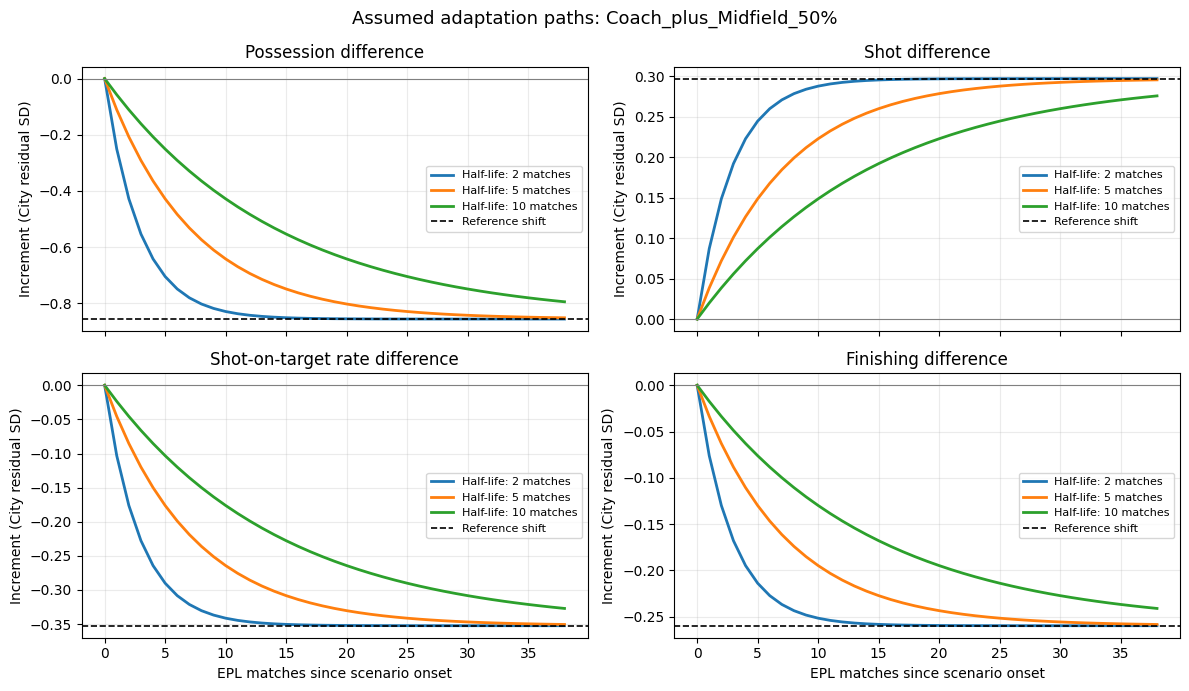

In [102]:
# ==================================================
# 7.2 Conditional adaptation paths
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_MATCHES = 38

# Assumed adaptation half-lives, measured in EPL matches
HALF_LIVES = [2, 5, 10]

# Example shown in the plots; all scenarios are simulated
PLOT_SCENARIO = "Coach_plus_Midfield_50%"

reference_inputs = (
    city_reference_shifts
    .loc[:, city_state_order]
    .astype(float)
    .copy()
)

assert PLOT_SCENARIO in reference_inputs.index
assert np.isfinite(reference_inputs.to_numpy()).all()

n_states = len(city_state_order)

adaptation_matrices = {}
stability_rows = []
path_frames = []

# --------------------------------------------------
# 1. Construct transition matrices and simulate paths
# --------------------------------------------------

for half_life in HALF_LIVES:

    retention = 2.0 ** (-1.0 / half_life)
    kappa = 1.0 - retention

    # A = (1 - kappa) I
    transition_matrix = (
        retention * np.eye(n_states)
    )

    adaptation_matrices[half_life] = pd.DataFrame(
        transition_matrix,
        index=city_state_order,
        columns=city_state_order
    )

    # All eigenvalues equal retention for this matrix
    spectral_radius = abs(retention)

    stability_rows.append({
        "Half_Life_Matches": half_life,
        "Kappa": kappa,
        "Spectral_Radius": spectral_radius,
        "Stable_About_Reference": spectral_radius < 1,
        "Matches_To_95pct": int(
            np.ceil(half_life * np.log2(20))
        )
    })

    for scenario_name, reference in reference_inputs.iterrows():

        target_shift = reference.to_numpy(dtype=float)

        trajectory = np.zeros(
            (N_MATCHES + 1, n_states)
        )

        # d_0 = 0: no incremental response at scenario onset
        for step in range(1, N_MATCHES + 1):

            trajectory[step] = (
                transition_matrix @ trajectory[step - 1]
                + kappa * target_shift
            )

        scenario_path = pd.DataFrame(
            trajectory,
            columns=city_state_order
        )

        scenario_path["Step"] = np.arange(N_MATCHES + 1)
        scenario_path["Scenario"] = scenario_name
        scenario_path["Half_Life_Matches"] = half_life

        path_frames.append(scenario_path)

adaptation_paths = pd.concat(
    path_frames,
    ignore_index=True
)

adaptation_stability = pd.DataFrame(
    stability_rows
)

display(
    adaptation_stability.round(4)
)

# --------------------------------------------------
# 2. Plot one selected scenario
# --------------------------------------------------

state_labels = {
    "Poss_Diff": "Possession difference",
    "Shot_Diff": "Shot difference",
    "SOT_Rate_Diff": "Shot-on-target rate difference",
    "Finishing_Diff": "Finishing difference"
}

selected_paths = adaptation_paths.loc[
    adaptation_paths["Scenario"].eq(PLOT_SCENARIO)
]

selected_reference = reference_inputs.loc[
    PLOT_SCENARIO
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7),
    sharex=True
)

for ax, variable in zip(
    axes.flat,
    city_state_order
):

    for half_life in HALF_LIVES:

        path = selected_paths.loc[
            selected_paths["Half_Life_Matches"].eq(half_life)
        ]

        ax.plot(
            path["Step"],
            path[variable],
            linewidth=2,
            label=f"Half-life: {half_life} matches"
        )

    ax.axhline(
        selected_reference[variable],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Reference shift"
    )

    ax.axhline(
        0,
        color="gray",
        linewidth=0.8
    )

    ax.set_title(state_labels[variable])
    ax.set_ylabel("Increment (City residual SD)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("EPL matches since scenario onset")

fig.suptitle(
    f"Assumed adaptation paths: {PLOT_SCENARIO}",
    fontsize=13
)

fig.tight_layout()
plt.show()

## 7.3 State and Observation Noise

Observed match residuals are noisy measurements of an underlying performance
state. For each state component, the conditional model is written as

$$
d_{t+1}
=
a_h d_t
+
(1-a_h)r
+
\eta_t,
\qquad
\eta_t\sim N(0,Q),
$$

and

$$
y_t=d_t+\epsilon_t,
\qquad
\epsilon_t\sim N(0,R).
$$

A one-dimensional Kalman filter is estimated separately for each of the four
state dimensions. Because the historical sample is small, the noise
decomposition is regularized through a state-variance share rather than by
freely estimating many covariance parameters.

The filter always records the **pre-match** state before assimilating the
current observation. This ordering is essential for later predictive tests.


In [103]:
# ==================================================
# 7.3 Estimate state/observation noise and define filtering
# ==================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar


# --------------------------------------------------
# 1. One-dimensional Kalman filter
#
# mean0 and var0 describe the prior for the FIRST match.
# Subsequent matches use prediction, then observation update.
# --------------------------------------------------

def filter_state_1d(
    y, retention, q_state, r_obs,
    reference=0.0, mean0=0.0, var0=None
):
    y = np.asarray(y, dtype=float).reshape(-1)

    if not 0 <= retention < 1:
        raise ValueError("Require 0 <= retention < 1.")

    parameters = [q_state, r_obs, reference, mean0]

    if (
        not np.isfinite(y).all()
        or not np.isfinite(parameters).all()
    ):
        raise ValueError("Non-finite filter input.")

    if q_state < 0 or r_obs < 0 or q_state + r_obs <= 0:
        raise ValueError("Invalid noise variances.")

    mean = float(mean0)

    # Stationary initialization for historical calibration
    variance = (
        q_state / (1 - retention**2)
        if var0 is None
        else float(var0)
    )

    if not np.isfinite(variance) or variance < 0:
        raise ValueError("Invalid initial variance.")

    output = {
        name: np.empty(len(y))
        for name in [
            "Mean_Pre", "Mean_Post",
            "Var_Pre", "Var_Post",
            "Innovation", "Predictive_Variance", "Gain"
        ]
    }

    for t, observed in enumerate(y):

        # Predict BEFORE observing this match
        if t > 0:
            mean = (
                retention * mean
                + (1 - retention) * reference
            )
            variance = (
                retention**2 * variance + q_state
            )

        innovation = observed - mean
        predictive_variance = variance + r_obs

        if predictive_variance <= 0:
            raise ValueError("Non-positive predictive variance.")

        gain = variance / predictive_variance

        output["Mean_Pre"][t] = mean
        output["Var_Pre"][t] = variance
        output["Innovation"][t] = innovation
        output["Predictive_Variance"][t] = predictive_variance
        output["Gain"][t] = gain

        # Update AFTER observing this match
        mean = mean + gain * innovation

        # Joseph-form covariance update
        variance = (
            (1 - gain)**2 * variance
            + gain**2 * r_obs
        )

        output["Mean_Post"][t] = mean
        output["Var_Post"][t] = variance

    return output


# --------------------------------------------------
# 2. Fit noise variances for a fixed retention parameter
#
# Parameterization:
#   stationary state variance = fraction * total_variance
#   Q = (1 - retention^2) * stationary state variance
#   R = (1 - fraction) * total_variance
#
# Profile out total_variance and optimize fraction in [0, 1].
# Each season starts separately.
# --------------------------------------------------

def fit_state_noise_1d(sequences, retention):

    n = sum(len(y) for y in sequences)

    def profile(fraction):

        q_unit = (1 - retention**2) * fraction
        r_unit = 1 - fraction

        weighted_ss = 0.0
        log_variance = 0.0

        for y in sequences:

            result = filter_state_1d(
                y,
                retention=retention,
                q_state=q_unit,
                r_obs=r_unit
            )

            forecast_var = result["Predictive_Variance"]

            weighted_ss += np.sum(
                result["Innovation"]**2 / forecast_var
            )
            log_variance += np.log(forecast_var).sum()

        total_variance = max(weighted_ss / n, 1e-12)

        nll = 0.5 * (
            n * (
                np.log(2 * np.pi)
                + np.log(total_variance)
                + 1
            )
            + log_variance
        )

        return nll, total_variance

    # Grid-assisted one-dimensional optimization
    grid = np.linspace(0, 1, 21)
    grid_scores = [profile(f)[0] for f in grid]
    best = int(np.argmin(grid_scores))

    lower = grid[max(0, best - 1)]
    upper = grid[min(len(grid) - 1, best + 1)]

    optimum = minimize_scalar(
        lambda f: profile(f)[0],
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-7}
    )

    if not optimum.success:
        raise RuntimeError(optimum.message)

    # Explicitly include both boundary models
    candidates = [
        0.0, 1.0, grid[best], float(optimum.x)
    ]

    fraction = min(
        candidates,
        key=lambda f: profile(f)[0]
    )

    nll, total_variance = profile(fraction)

    return {
        "State_Variance_Share": fraction,
        "Q_State": (
            (1 - retention**2)
            * fraction * total_variance
        ),
        "R_Obs": (1 - fraction) * total_variance,
        "P0_State": fraction * total_variance,
        "NLL": nll
    }


# --------------------------------------------------
# 3. Use the existing two-season refit residuals
# --------------------------------------------------

ssm_observation_cols = [
    f"std_r_{variable}"
    for variable in city_state_order
]

ssm_fit_data = (
    final_data_bt.loc[
        final_data_bt["Split"].isin(["Train", "Validation"]),
        ["Season", "Date"] + ssm_observation_cols
    ]
    .sort_values(["Season", "Date"])
    .reset_index(drop=True)
    .copy()
)

assert len(ssm_fit_data) == 76
assert ssm_fit_data.groupby("Season").size().eq(38).all()

assert np.isfinite(
    ssm_fit_data[ssm_observation_cols].to_numpy(dtype=float)
).all()

ssm_season_data = [
    group.reset_index(drop=True)
    for _, group in ssm_fit_data.groupby("Season", sort=True)
]


# --------------------------------------------------
# 4. Fit each dimension under each assumed half-life
# --------------------------------------------------

state_noise_models = {}
noise_summary_rows = []

for half_ssm in HALF_LIVES:

    retention_ssm = 2.0 ** (-1.0 / half_ssm)
    state_noise_models[half_ssm] = {}

    for variable_ssm in city_state_order:

        column_ssm = f"std_r_{variable_ssm}"

        sequences_ssm = [
            group[column_ssm].to_numpy(dtype=float)
            for group in ssm_season_data
        ]

        fitted_ssm = fit_state_noise_1d(
            sequences_ssm,
            retention=retention_ssm
        )

        fitted_ssm["Retention"] = retention_ssm

        state_noise_models[half_ssm][variable_ssm] = fitted_ssm

        noise_summary_rows.append({
            "Half_Life_Matches": half_ssm,
            "Variable": variable_ssm,
            **fitted_ssm
        })

state_noise_summary = (
    pd.DataFrame(noise_summary_rows)
    .set_index(["Half_Life_Matches", "Variable"])
)

display(
    state_noise_summary[
        [
            "State_Variance_Share",
            "Q_State",
            "R_Obs",
            "P0_State"
        ]
    ].round(6)
)


# --------------------------------------------------
# 5. Illustrate pre-match vs post-match estimates
# This is an IN-SAMPLE calibration replay, not a test.
# --------------------------------------------------

demo_half_ssm = 5
demo_variable_ssm = "Poss_Diff"
demo_data_ssm = ssm_season_data[-1]

demo_parameters_ssm = (
    state_noise_models[demo_half_ssm][demo_variable_ssm]
)

demo_observed_ssm = demo_data_ssm[
    f"std_r_{demo_variable_ssm}"
].to_numpy(dtype=float)

demo_filter_ssm = filter_state_1d(
    demo_observed_ssm,
    retention=demo_parameters_ssm["Retention"],
    q_state=demo_parameters_ssm["Q_State"],
    r_obs=demo_parameters_ssm["R_Obs"]
)

state_update_example = pd.DataFrame(demo_filter_ssm)

state_update_example["Date"] = (
    demo_data_ssm["Date"].to_numpy()
)
state_update_example["Observed"] = demo_observed_ssm

print("Calibration replay: possession difference, half-life = 5")

display(
    state_update_example[
        ["Date", "Observed", "Mean_Pre", "Mean_Post", "Gain"]
    ]
    .head(6)
    .round(4)
)

State_Variance_Share   Q_State     R_Obs  \
Half_Life_Matches Variable                                                   
2                 Poss_Diff                   0.123033  0.060566  0.863407   
                  Shot_Diff                   0.000000  0.000000  0.986842   
                  SOT_Rate_Diff               0.039098  0.019277  0.947549   
                  Finishing_Diff              0.000000  0.000000  0.986842   
5                 Poss_Diff                   0.084800  0.020418  0.910068   
                  Shot_Diff                   0.000000  0.000000  0.986842   
                  SOT_Rate_Diff               0.061897  0.014769  0.924394   
                  Finishing_Diff              0.013969  0.003338  0.973148   
10                Poss_Diff                   0.000000  0.000000  0.986842   
                  Shot_Diff                   0.000000  0.000000  0.986842   
                  SOT_Rate_Diff               0.073011  0.009390  0.920968   
                  Finishing_Diff              0.000000  0.000000  0.986842   

                                  P0_State  
Half_Life_Matches Variable                  
2                 Poss_Diff       0.121131  
                  Shot_Diff       0.000000  
                  SOT_Rate_Diff   0.038555  
                  Finishing_Diff  0.000000  
5                 Poss_Diff       0.084324  
                  Shot_Diff       0.000000  
                  SOT_Rate_Diff   0.060992  
                  Finishing_Diff  0.013786  
10                Poss_Diff       0.000000  
                  Shot_Diff       0.000000  
                  SOT_Rate_Diff   0.072537  
                  Finishing_Diff  0.000000

Calibration replay: possession difference, half-life = 5


,Date,Observed,Mean_Pre,Mean_Post,Gain
0,2024-08-18,-1.2525,0.0000,-0.1062,0.0848
1,2024-08-24,0.7031,-0.0925,-0.0290,0.0798
2,2024-08-31,0.4740,-0.0252,0.0130,0.0766
3,2024-09-14,-1.6238,0.0113,-0.1104,0.0745
4,2024-09-22,2.4314,-0.0961,0.0886,0.0731
5,2024-09-28,0.1605,0.0772,0.0832,0.0722


## 7.4 Frozen-Parameter Historical Evaluation

The state-space specifications calibrated on the first two seasons are replayed
on 2025/26 without retuning. They are compared with a zero-residual benchmark,
which retains the expected-performance baseline from Bayesian strength and
venue but assumes no additional predictable residual state.

The comparison evaluates whether the filtered match-to-match state adds
forecastable information about the next performance residual. RMSE and Gaussian
negative log-likelihood are reported over the same 38 matches and four state
dimensions.


In [104]:
# ==================================================
# 7.4 Frozen-parameter historical evaluation: 2025/26
# ==================================================

import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. Prepare the evaluation season
# --------------------------------------------------

ssm_test_data = (
    final_data_bt.loc[
        final_data_bt["Split"].eq("Test"),
        [
            "Season", "Date", "Venue", "Opponent_Key"
        ] + ssm_observation_cols
    ]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

assert len(ssm_test_data) == 38
assert ssm_test_data["Season"].nunique() == 1
assert (
    ssm_fit_data["Date"].max()
    < ssm_test_data["Date"].min()
)

ssm_test_observed = (
    ssm_test_data[ssm_observation_cols]
    .to_numpy(dtype=float)
)

assert np.isfinite(ssm_test_observed).all()

# --------------------------------------------------
# 2. Zero-residual baseline
#
# Performance expectations from strength and venue
# remain in place. This baseline adds no residual shift.
# Noise variance is estimated from the earlier 76 matches.
# --------------------------------------------------

baseline_variance_ssm = np.mean(
    ssm_fit_data[ssm_observation_cols]
    .to_numpy(dtype=float) ** 2,
    axis=0
)

assert np.isfinite(baseline_variance_ssm).all()
assert (baseline_variance_ssm > 0).all()

state_test_runs = {
    "Zero_Residual": {
        "Mean_Pre": np.zeros_like(ssm_test_observed),
        "Predictive_Variance": np.broadcast_to(
            baseline_variance_ssm,
            ssm_test_observed.shape
        ).copy()
    }
}

# --------------------------------------------------
# 3. Replay each fixed half-life specification
#
# Parameters come directly from Section 7.3.
# Start a new season with mean zero and its fitted
# stationary prior variance, matching calibration.
# --------------------------------------------------

for half_ssm in HALF_LIVES:

    model_name_ssm = f"SSM_H{half_ssm}"

    means_pre_ssm = np.empty_like(ssm_test_observed)
    means_post_ssm = np.empty_like(ssm_test_observed)
    predictive_vars_ssm = np.empty_like(ssm_test_observed)
    gains_ssm = np.empty_like(ssm_test_observed)

    for j_ssm, variable_ssm in enumerate(city_state_order):

        parameters_ssm = (
            state_noise_models[half_ssm][variable_ssm]
        )

        result_ssm = filter_state_1d(
            ssm_test_observed[:, j_ssm],
            retention=parameters_ssm["Retention"],
            q_state=parameters_ssm["Q_State"],
            r_obs=parameters_ssm["R_Obs"],
            reference=0.0,
            mean0=0.0,
            var0=parameters_ssm["P0_State"]
        )

        means_pre_ssm[:, j_ssm] = result_ssm["Mean_Pre"]
        means_post_ssm[:, j_ssm] = result_ssm["Mean_Post"]

        predictive_vars_ssm[:, j_ssm] = (
            result_ssm["Predictive_Variance"]
        )

        gains_ssm[:, j_ssm] = result_ssm["Gain"]

    state_test_runs[model_name_ssm] = {
        "Mean_Pre": means_pre_ssm,
        "Mean_Post": means_post_ssm,
        "Predictive_Variance": predictive_vars_ssm,
        "Gain": gains_ssm
    }

# --------------------------------------------------
# 4. Score PRE-MATCH forecasts only
# --------------------------------------------------

ssm_score_rows = []
ssm_rmse_by_variable = {}

for model_name_ssm, result_ssm in state_test_runs.items():

    prediction_ssm = result_ssm["Mean_Pre"]
    forecast_variance_ssm = result_ssm["Predictive_Variance"]

    assert prediction_ssm.shape == ssm_test_observed.shape
    assert forecast_variance_ssm.shape == ssm_test_observed.shape
    assert np.isfinite(prediction_ssm).all()
    assert np.isfinite(forecast_variance_ssm).all()
    assert (forecast_variance_ssm > 0).all()

    error_ssm = ssm_test_observed - prediction_ssm

    # Pooled across the same 38 matches and four dimensions
    overall_rmse_ssm = np.sqrt(
        np.mean(error_ssm**2)
    )

    # Gaussian negative log-likelihood:
    # averaged across matches and dimensions
    mean_nll_ssm = 0.5 * np.mean(
        np.log(2 * np.pi * forecast_variance_ssm)
        + error_ssm**2 / forecast_variance_ssm
    )

    ssm_score_rows.append({
        "Model": model_name_ssm,
        "N_Matches": len(ssm_test_data),
        "RMSE": overall_rmse_ssm,
        "Mean_Gaussian_NLL": mean_nll_ssm
    })

    ssm_rmse_by_variable[model_name_ssm] = (
        np.sqrt(np.mean(error_ssm**2, axis=0))
    )

ssm_test_comparison = (
    pd.DataFrame(ssm_score_rows)
    .set_index("Model")
)

baseline_rmse_ssm = ssm_test_comparison.loc[
    "Zero_Residual", "RMSE"
]

assert baseline_rmse_ssm > 0

ssm_test_comparison["RMSE_Gain_pct"] = (
    100 * (
        1 - ssm_test_comparison["RMSE"] / baseline_rmse_ssm
    )
)

ssm_test_rmse_by_variable = (
    pd.DataFrame(
        ssm_rmse_by_variable,
        index=city_state_order
    )
    .T
    .rename_axis("Model")
)

print("Exploratory historical evaluation: 2025/26")

display(
    ssm_test_comparison[
        [
            "N_Matches",
            "RMSE",
            "RMSE_Gain_pct",
            "Mean_Gaussian_NLL"
        ]
    ].round(4)
)

display(
    ssm_test_rmse_by_variable.round(4)
)

Exploratory historical evaluation: 2025/26


,N_Matches,RMSE,RMSE_Gain_pct,Mean_Gaussian_NLL
Model,,,,
Zero_Residual,38,1.0466,0.0000,1.4673
SSM_H2,38,1.0480,-0.1406,1.4693
SSM_H5,38,1.0513,-0.4554,1.4731
SSM_H10,38,1.0514,-0.4603,1.4731


,Poss_Diff,Shot_Diff,SOT_Rate_Diff,Finishing_Diff
Model,,,,
Zero_Residual,1.0704,0.7628,1.1952,1.1067
SSM_H2,1.0703,0.7628,1.2005,1.1067
SSM_H5,1.0731,0.7628,1.2080,1.1083
SSM_H10,1.0704,0.7628,1.2120,1.1067


### 7.5 Section 7 Modeling Decision

None of the tested state-space half-life specifications improves on the
zero-residual benchmark in the 2025/26 replay:

$$
RMSE_{\mathrm{Zero}}=1.0466,
$$

compared with

$$
1.0480,\quad 1.0513,\quad 1.0514
$$

for half-lives of 2, 5, and 10 matches.

The Gaussian NLL results move in the same direction. The historical evidence
therefore does not support using the filtered residual state as a standalone
next-match performance predictor.

Section 7 is retained as a **structural and diagnostic layer**: it provides a
coherent way to express gradual adaptation, uncertainty, and post-match state
updating, while avoiding the claim that these dynamics have already been shown
to improve forecasts.


# 8. Score Generation and Historical Probability Evaluation

The forecasting layer converts pre-match structural information into goal
intensities. To keep the final model auditable, the initial score layer uses
independent Poisson regressions for Manchester City goals for and goals
against.

## 8.1 Score-Baseline Selection

Two fixed specifications are compared on the 2024/25 validation season:

$$
\text{Venue Only}: \quad Home_t,
$$

and

$$
\text{Strength + Venue}: \quad \Delta S_t + Home_t.
$$

For each target $Y_t\in\{GF_t,GA_t\}$,

$$
\log \lambda_{Y,t}
=
\alpha_Y
+
\beta_Y\Delta S_t
+
\gamma_Y Home_t.
$$

The `Strength_Home` specification is selected on validation before the 2025/26
test season is evaluated.


In [105]:
# ==================================================
# 8.1 Fit and validate the score baseline
# ==================================================

import warnings
import numpy as np
import pandas as pd

from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.exceptions import ConvergenceWarning

# --------------------------------------------------
# 1. Reuse aligned matches and pre-match predictors
# --------------------------------------------------

score_data = (
    city_backtest_base[
        [
            "Season", "Date", "Split", "Venue", "Opponent_Key",
            "Delta_S", "Home", "GF", "GA"
        ]
    ]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

score_data["Date"] = pd.to_datetime(score_data["Date"])

score_numeric_cols = ["Delta_S", "Home", "GF", "GA"]
score_data[score_numeric_cols] = (
    score_data[score_numeric_cols].astype(float)
)

assert np.isfinite(
    score_data[score_numeric_cols].to_numpy()
).all()

score_goal_values = score_data[["GF", "GA"]].to_numpy()

assert (score_goal_values >= 0).all()
assert np.equal(
    score_goal_values, np.floor(score_goal_values)
).all()

assert score_data["Home"].isin([0, 1]).all()

score_splits = {
    split: score_data.loc[
        score_data["Split"].eq(split)
    ].copy()
    for split in ["Train", "Validation", "Test"]
}

assert all(len(data) == 38 for data in score_splits.values())

assert (
    score_splits["Train"]["Date"].max()
    < score_splits["Validation"]["Date"].min()
)
assert (
    score_splits["Validation"]["Date"].max()
    < score_splits["Test"]["Date"].min()
)

score_train = score_splits["Train"]
score_validation = score_splits["Validation"]

# --------------------------------------------------
# 2. Define the two fixed model specifications
# --------------------------------------------------

score_feature_sets = {
    "Venue_Only": ["Home"],
    "Strength_Home": ["Delta_S", "Home"]
}

score_targets = ["GF", "GA"]

# Rate columns always follow the same GF, GA order.
def evaluate_score_rates(actual, rates):
    actual = np.asarray(actual, dtype=float)
    rates = np.asarray(rates, dtype=float)

    assert actual.shape == rates.shape
    assert actual.ndim == 2 and actual.shape[1] == 2
    assert np.isfinite(rates).all()
    assert (rates > 0).all()

    # Conditional independence:
    # log P(GF, GA) = log P(GF) + log P(GA)
    joint_log_probability = poisson.logpmf(
        actual, rates
    ).sum(axis=1)

    rmse = np.sqrt(np.mean((actual - rates) ** 2, axis=0))

    return {
        "N_Matches": len(actual),
        "Mean_Score_NLL": -joint_log_probability.mean(),
        "GF_RMSE": rmse[0],
        "GA_RMSE": rmse[1]
    }

# --------------------------------------------------
# 3. Fit on Train; predict Validation
# --------------------------------------------------

score_models_train = {}
score_validation_predictions = {}
score_validation_rows = []
score_coefficient_rows = []

for score_name, score_features in score_feature_sets.items():

    X_score_train = score_train[score_features]
    X_score_validation = score_validation[score_features]

    # Unpenalized fitting requires an identifiable design.
    score_design = np.column_stack([
        np.ones(len(X_score_train)),
        X_score_train.to_numpy()
    ])

    assert (
        np.linalg.matrix_rank(score_design)
        == score_design.shape[1]
    )

    score_models_train[score_name] = {}
    score_rates = np.empty((len(score_validation), 2))

    for score_j, score_target in enumerate(score_targets):

        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            score_model = PoissonRegressor(
                alpha=0.0,
                max_iter=1000,
                tol=1e-8
            ).fit(
                X_score_train,
                score_train[score_target]
            )

        score_models_train[score_name][score_target] = score_model

        score_rates[:, score_j] = score_model.predict(
            X_score_validation
        )

        if score_name == "Strength_Home":
            score_coefficient_rows.append({
                "Target": score_target,
                "N_Train": len(score_train),
                "Intercept": score_model.intercept_,
                "Delta_S_coef": score_model.coef_[0],
                "Home_coef": score_model.coef_[1]
            })

    score_predictions = score_validation[
        ["Season", "Date", "Venue", "Opponent_Key", "GF", "GA"]
    ].copy()

    score_predictions["Lambda_City"] = score_rates[:, 0]
    score_predictions["Lambda_Opp"] = score_rates[:, 1]

    score_validation_predictions[score_name] = score_predictions

    score_validation_rows.append({
        "Model": score_name,
        **evaluate_score_rates(
            score_validation[score_targets].to_numpy(),
            score_rates
        )
    })

# --------------------------------------------------
# 4. Inspect coefficients and validation performance
# --------------------------------------------------

score_coefficients_train = (
    pd.DataFrame(score_coefficient_rows)
    .set_index("Target")
)

score_validation_comparison = (
    pd.DataFrame(score_validation_rows)
    .set_index("Model")
)

display(score_coefficients_train.round(4))
display(score_validation_comparison.round(4))

,N_Train,Intercept,Delta_S_coef,Home_coef
Target,,,,
GF,38,0.2539,0.1393,0.1112
GA,38,-0.0175,-0.0088,-0.1176


,N_Matches,Mean_Score_NLL,GF_RMSE,GA_RMSE
Model,,,,
Venue_Only,38,3.2128,1.5154,1.1698
Strength_Home,38,3.0992,1.3783,1.1618


## 8.2 Refit and 2025/26 Score Test

After model selection, both score specifications are refitted on the first two
seasons (76 matches) and evaluated on the chronologically later 2025/26
season.

The validation-selected `Strength_Home` model gives

$$
GF\ RMSE=1.2285,\qquad
GA\ RMSE=1.0230,\qquad
NLL=2.9274.
$$

The simpler venue-only model gives a slightly lower test NLL and GA RMSE, while
the strength model gives a slightly lower GF RMSE. This is **mixed test
evidence**, not a strong win for the richer score model.

The specification is nevertheless kept frozen because it was selected before
the test season was examined. The test season is not used to switch models
after the fact. This limitation is recorded explicitly in the final project
summary.


In [106]:
# ==================================================
# 8.2 Refit the score models and evaluate 2025/26
# ==================================================

# Fixed from the validation comparison in Section 8.1
score_selected_name = "Strength_Home"

score_refit = (
    pd.concat(
        [score_splits["Train"], score_splits["Validation"]],
        ignore_index=True
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

score_test = (
    score_splits["Test"]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

assert len(score_refit) == 76
assert len(score_test) == 38
assert score_refit["Date"].max() < score_test["Date"].min()

score_models_refit = {}
score_test_predictions = {}
score_test_rows = []
score_refit_coefficient_rows = []

# --------------------------------------------------
# 1. Refit both specifications on the same 76 matches
# --------------------------------------------------

for score_name, score_features in score_feature_sets.items():

    X_score_refit = score_refit[score_features]
    X_score_test = score_test[score_features]

    score_design_refit = np.column_stack([
        np.ones(len(X_score_refit)),
        X_score_refit.to_numpy()
    ])

    assert (
        np.linalg.matrix_rank(score_design_refit)
        == score_design_refit.shape[1]
    )

    score_models_refit[score_name] = {}
    score_test_rates = np.empty((len(score_test), 2))

    for score_j, score_target in enumerate(score_targets):

        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            score_model_refit = PoissonRegressor(
                alpha=0.0,
                max_iter=1000,
                tol=1e-8
            ).fit(
                X_score_refit,
                score_refit[score_target]
            )

        score_models_refit[score_name][score_target] = (
            score_model_refit
        )

        score_test_rates[:, score_j] = (
            score_model_refit.predict(X_score_test)
        )

        if score_name == score_selected_name:
            score_refit_coefficient_rows.append({
                "Target": score_target,
                "N_Refit": len(score_refit),
                "Intercept": score_model_refit.intercept_,
                "Delta_S_coef": score_model_refit.coef_[0],
                "Home_coef": score_model_refit.coef_[1]
            })

    # --------------------------------------------------
    # 2. Save pre-match rates and evaluate actual scores
    # --------------------------------------------------

    score_prediction_table = score_test[
        [
            "Season", "Date", "Venue", "Opponent_Key",
            "Delta_S", "Home", "GF", "GA"
        ]
    ].copy()

    score_prediction_table["Lambda_City"] = (
        score_test_rates[:, 0]
    )
    score_prediction_table["Lambda_Opp"] = (
        score_test_rates[:, 1]
    )

    # Actual goals are used only for evaluation here.
    score_prediction_table["Actual_Score_NLL"] = (
        -poisson.logpmf(
            score_test[score_targets].to_numpy(),
            score_test_rates
        ).sum(axis=1)
    )

    score_test_predictions[score_name] = score_prediction_table

    score_test_rows.append({
        "Model": score_name,
        "Selected_on_Validation": (
            score_name == score_selected_name
        ),
        **evaluate_score_rates(
            score_test[score_targets].to_numpy(),
            score_test_rates
        )
    })

# --------------------------------------------------
# 3. Display refitted coefficients and historical results
# --------------------------------------------------

score_coefficients_refit = (
    pd.DataFrame(score_refit_coefficient_rows)
    .set_index("Target")
)

score_test_comparison = (
    pd.DataFrame(score_test_rows)
    .set_index("Model")
)

selected_score_test_predictions = (
    score_test_predictions[score_selected_name].copy()
)

print("Selected model:", score_selected_name)
display(score_coefficients_refit.round(4))

print("Historical score evaluation: 2025/26")
display(score_test_comparison.round(4))

print("Selected model: first five pre-match predictions")
display(
    selected_score_test_predictions[
        [
            "Date", "Venue", "Opponent_Key",
            "Lambda_City", "Lambda_Opp", "GF", "GA"
        ]
    ]
    .head(5)
    .round(4)
)

Selected model: Strength_Home


,N_Refit,Intercept,Delta_S_coef,Home_coef
Target,,,,
GF,76,0.1643,0.1368,0.2353
GA,76,0.5065,-0.1477,-0.0130


Historical score evaluation: 2025/26


,Selected_on_Validation,N_Matches,Mean_Score_NLL,GF_RMSE,GA_RMSE
Model,,,,,
Venue_Only,False,38,2.9032,1.2360,0.9892
Strength_Home,True,38,2.9274,1.2285,1.0230


Selected model: first five pre-match predictions


,Date,Venue,Opponent_Key,Lambda_City,Lambda_Opp,GF,GA
0,2025-08-16,Away,Wolves,1.7585,1.0773,4.0,0.0
1,2025-08-23,Home,Tottenham,1.9650,1.2161,0.0,2.0
2,2025-08-31,Away,Brighton,1.5685,1.2188,1.0,2.0
3,2025-09-14,Home,Man United,2.0066,1.1889,3.0,0.0
4,2025-09-21,Away,Arsenal,1.1014,1.7854,1.0,1.0


## 8.3 From Goal Intensities to Score Probabilities

Conditional on the two fitted goal intensities, the baseline score generator
assumes independent Poisson counts:

$$
GF_t\sim Pois(\lambda_{\mathrm{City},t}),
\qquad
GA_t\sim Pois(\lambda_{\mathrm{Opp},t}).
$$

Hence

$$
P(GF=i,GA=j)
=
P(GF=i)\,P(GA=j).
$$

The implementation expands the score grid until omitted probability mass is
negligible, reports win/draw/loss probabilities, and extracts the five most
probable exact scores. A visible $0$--$5$ grid is retained for interpretation
without renormalizing away the remaining tail probability.


In [107]:
# ==================================================
# 8.3 Convert goal rates into score probabilities
# ==================================================

from scipy.stats import poisson, skellam

def build_score_distribution(lambda_city, lambda_opp):

    rates = np.array([lambda_city, lambda_opp], dtype=float)

    assert np.isfinite(rates).all()
    assert (rates > 0).all()

    # --------------------------------------------------
    # 1. Expand the grid until omitted mass is negligible
    # --------------------------------------------------

    tail_tolerance = 1e-10

    limits = np.maximum(
        5,
        poisson.ppf(
            1 - tail_tolerance / 2,
            rates
        ).astype(int)
    )

    city_goals = np.arange(limits[0] + 1)
    opp_goals = np.arange(limits[1] + 1)

    joint_probability = np.outer(
        poisson.pmf(city_goals, rates[0]),
        poisson.pmf(opp_goals, rates[1])
    )

    tails = poisson.sf(limits, rates)

    omitted_mass = float(
        tails[0] + tails[1] - tails.prod()
    )

    assert omitted_mass <= tail_tolerance * 1.01

    # --------------------------------------------------
    # 2. Find the five most probable exact scores
    # --------------------------------------------------

    top_indices = np.argsort(
        -joint_probability.ravel(),
        kind="stable"
    )[:5]

    top_city, top_opp = np.unravel_index(
        top_indices,
        joint_probability.shape
    )

    top_probabilities = joint_probability[top_city, top_opp]

    # No omitted score can displace the fifth-ranked score.
    assert top_probabilities[-1] > omitted_mass

    top5 = pd.DataFrame({
        "Rank": np.arange(1, 6),
        "Score_City_Opp": [
            f"{city}-{opp}"
            for city, opp in zip(top_city, top_opp)
        ],
        "Probability": top_probabilities
    }).set_index("Rank")

    # --------------------------------------------------
    # 3. Compute win/draw/loss over the full distribution
    # --------------------------------------------------

    win_probability = float(skellam.sf(0, *rates))
    draw_probability = float(skellam.pmf(0, *rates))
    loss_probability = float(skellam.cdf(-1, *rates))

    assert np.isclose(
        win_probability + draw_probability + loss_probability,
        1.0,
        atol=1e-10,
        rtol=0
    )

    # --------------------------------------------------
    # 4. Keep the displayed 0-5 grid unnormalized
    # --------------------------------------------------

    grid_0_5 = pd.DataFrame(
        joint_probability[:6, :6],
        index=pd.Index(range(6), name="City goals"),
        columns=pd.Index(range(6), name="Opponent goals")
    )

    tails_0_5 = poisson.sf(5, rates)

    outside_0_5 = float(
        tails_0_5[0] + tails_0_5[1] - tails_0_5.prod()
    )

    assert np.isclose(
        grid_0_5.to_numpy().sum() + outside_0_5,
        1.0,
        atol=1e-12,
        rtol=0
    )

    return {
        "Grid_0_5": grid_0_5,
        "Top5": top5,
        "Summary": {
            "P_Win": win_probability,
            "P_Draw": draw_probability,
            "P_Loss": loss_probability,
            "P_Outside_0_5": outside_0_5,
            "Top5_Probability_Mass": top_probabilities.sum()
        }
    }


# --------------------------------------------------
# 5. Generate distributions for all 38 historical matches
# --------------------------------------------------

score_probability_matches = (
    selected_score_test_predictions
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

score_distributions_test = [
    build_score_distribution(
        row.Lambda_City,
        row.Lambda_Opp
    )
    for row in score_probability_matches.itertuples(index=False)
]

score_probability_summary = pd.concat(
    [
        score_probability_matches[
            [
                "Date", "Venue", "Opponent_Key",
                "Lambda_City", "Lambda_Opp"
            ]
        ],
        pd.DataFrame([
            result["Summary"]
            for result in score_distributions_test
        ])
    ],
    axis=1
)

# --------------------------------------------------
# 6. Display the first historical match as an example
# --------------------------------------------------

score_example_index = 0

score_example_match = score_probability_matches.iloc[
    score_example_index
]

score_example_distribution = score_distributions_test[
    score_example_index
]

print(
    f"{score_example_match['Date']:%Y-%m-%d} | "
    f"Man City vs {score_example_match['Opponent_Key']} | "
    f"City venue: {score_example_match['Venue']}"
)

print("Outcome probabilities (%)")

display(
    (
        score_probability_summary.loc[
            [score_example_index],
            [
                "P_Win", "P_Draw", "P_Loss",
                "P_Outside_0_5", "Top5_Probability_Mass"
            ]
        ] * 100
    ).round(2)
)

print("Exact-score grid (%): rows = City, columns = opponent")

display(
    (
        score_example_distribution["Grid_0_5"] * 100
    ).round(2)
)

print("Top 5 exact scores: City-opponent")

display(
    score_example_distribution["Top5"]
    .assign(
        Probability_pct=lambda data: 100 * data["Probability"]
    )
    [["Score_City_Opp", "Probability_pct"]]
    .round(2)
)

2025-08-16 | Man City vs Wolves | City venue: Away
Outcome probabilities (%)


,P_Win,P_Draw,P_Loss,P_Outside_0_5,Top5_Probability_Mass
0,53.33,23.5,23.17,1.02,46.6


Exact-score grid (%): rows = City, columns = opponent


Opponent goals,0,1,2,3,4,5
City goals,,,,,,
0,5.87,6.32,3.40,1.22,0.33,0.07
1,10.32,11.12,5.99,2.15,0.58,0.12
2,9.07,9.77,5.26,1.89,0.51,0.11
3,5.32,5.73,3.09,1.11,0.30,0.06
4,2.34,2.52,1.36,0.49,0.13,0.03
5,0.82,0.89,0.48,0.17,0.05,0.01


Top 5 exact scores: City-opponent


,Score_City_Opp,Probability_pct
Rank,,
1,1-1,11.12
2,1-0,10.32
3,2-1,9.77
4,2-0,9.07
5,0-1,6.32


## 8.4 Historical Probability Audit

Exact-score forecasts are evaluated match by match rather than judged only by
whether the single most likely score is correct. The audit records:

- the actual score;
- the five highest-probability exact scores;
- whether the actual score appears in the Top 5;
- the probability mass contained in the Top 5;
- win/draw/loss Brier score;
- exact-score negative log-likelihood.

Exact scores are intrinsically diffuse. A match falling outside the Top 5 is
therefore not, by itself, evidence of a broken probability model. The more
important diagnostics are probability calibration, NLL, and whether the goal
intensities distinguish different match environments.


In [108]:
# ==================================================
# 8.4 Summarize historical probability performance
# ==================================================

score_probability_audit_rows = []

for score_eval_name, score_eval_data in score_test_predictions.items():

    score_eval_data = (
        score_eval_data
        .sort_values("Date")
        .reset_index(drop=True)
    )

    for score_eval_match in score_eval_data.itertuples(index=False):

        score_eval_distribution = build_score_distribution(
            score_eval_match.Lambda_City,
            score_eval_match.Lambda_Opp
        )

        score_eval_summary = score_eval_distribution["Summary"]
        score_eval_top5 = score_eval_distribution["Top5"]

        # Probability order: City win, draw, City loss
        score_eval_wdl = np.array([
            score_eval_summary["P_Win"],
            score_eval_summary["P_Draw"],
            score_eval_summary["P_Loss"]
        ])

        if score_eval_match.GF > score_eval_match.GA:
            score_actual_result_index = 0
        elif score_eval_match.GF == score_eval_match.GA:
            score_actual_result_index = 1
        else:
            score_actual_result_index = 2

        score_actual_onehot = np.eye(3)[
            score_actual_result_index
        ]

        # Multiclass Brier score: sum over three outcomes.
        # Range: 0 to 2; lower is better.
        score_wdl_brier = np.sum(
            (score_eval_wdl - score_actual_onehot) ** 2
        )

        score_actual_text = (
            f"{int(score_eval_match.GF)}-"
            f"{int(score_eval_match.GA)}"
        )

        score_top5_hit = bool(
            score_eval_top5["Score_City_Opp"]
            .eq(score_actual_text)
            .any()
        )

        score_probability_audit_rows.append({
            "Model": score_eval_name,
            "Date": score_eval_match.Date,
            "Opponent_Key": score_eval_match.Opponent_Key,
            "Actual_Score": score_actual_text,
            "Top1_Score": score_eval_top5.iloc[0]["Score_City_Opp"],
            "Top5_Hit": score_top5_hit,
            "Top5_Mass": score_eval_summary["Top5_Probability_Mass"],
            "WDL_Brier": score_wdl_brier,
            "Score_NLL": score_eval_match.Actual_Score_NLL
        })

score_probability_audit = pd.DataFrame(
    score_probability_audit_rows
)


# Aggregate audit summary; defined here so the cell is restart-safe.
score_probability_evaluation = (
    score_probability_audit
    .groupby("Model", sort=False)
    .agg(
        N_Matches=("Date", "size"),
        Top5_Hits=("Top5_Hit", "sum"),
        Mean_Top5_Mass=("Top5_Mass", "mean"),
        Mean_WDL_Brier=("WDL_Brier", "mean"),
        Mean_Score_NLL=("Score_NLL", "mean")
    )
)

score_probability_evaluation["Top5_Hit_Rate"] = (
    score_probability_evaluation["Top5_Hits"]
    / score_probability_evaluation["N_Matches"]
)

print("Aggregate historical probability audit")
display(score_probability_evaluation.round(4))

# ==================================================
# Display all matches with complete Top 5 predictions
# ==================================================

score_detail_model = score_selected_name

score_detail_source = (
    score_test_predictions[score_detail_model]
    .sort_values("Date")
    .reset_index(drop=True)
)

score_detail_rows = []

for match_no, match in enumerate(
    score_detail_source.itertuples(index=False),
    start=1
):
    distribution = build_score_distribution(
        match.Lambda_City,
        match.Lambda_Opp
    )

    top5 = distribution["Top5"]
    actual_score = f"{int(match.GF)}-{int(match.GA)}"

    matched_ranks = top5.index[
        top5["Score_City_Opp"].eq(actual_score)
    ]

    detail_row = {
        "Match_No": match_no,
        "Date": match.Date.strftime("%Y-%m-%d"),
        "Venue": match.Venue,
        "Opponent": match.Opponent_Key,
        "Actual_Score": actual_score
    }

    for rank, prediction in top5.iterrows():
        detail_row[f"Top{rank}"] = (
            f"{prediction['Score_City_Opp']} "
            f"({prediction['Probability']:.2%})"
        )

    detail_row["Actual_Rank"] = (
        str(int(matched_ranks[0]))
        if len(matched_ranks)
        else ">5"
    )

    score_detail_rows.append(detail_row)

score_match_details = (
    pd.DataFrame(score_detail_rows)
    .set_index("Match_No")
)

# Confirm that the detailed table matches the aggregate result.
assert (
    score_match_details["Actual_Rank"].ne(">5").sum()
    == score_probability_evaluation.loc[
        score_detail_model, "Top5_Hits"
    ]
)

print(f"All {len(score_match_details)} matches: {score_detail_model}")
print("Scores are always City-opponent; parentheses show probability.")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(score_match_details)


Aggregate historical probability audit


,N_Matches,Top5_Hits,Mean_Top5_Mass,Mean_WDL_Brier,Mean_Score_NLL,Top5_Hit_Rate
Model,,,,,,
Venue_Only,38,22,0.4405,0.5396,2.9032,0.5789
Strength_Home,38,17,0.4448,0.5501,2.9274,0.4474


All 38 matches: Strength_Home
Scores are always City-opponent; parentheses show probability.


,Date,Venue,Opponent,Actual_Score,Top1,Top2,Top3,Top4,Top5,Actual_Rank
Match_No,,,,,,,,,,
1,2025-08-16,Away,Wolves,4-0,1-1 (11.12%),1-0 (10.32%),2-1 (9.77%),2-0 (9.07%),0-1 (6.32%),>5
2,2025-08-23,Home,Tottenham,0-2,1-1 (9.93%),2-1 (9.75%),1-0 (8.16%),2-0 (8.02%),3-1 (6.39%),>5
3,2025-08-31,Away,Brighton,1-2,1-1 (11.77%),1-0 (9.66%),2-1 (9.23%),2-0 (7.58%),0-1 (7.51%),>5
4,2025-09-14,Home,Man United,3-0,2-1 (9.80%),1-1 (9.77%),2-0 (8.24%),1-0 (8.22%),3-1 (6.56%),>5
5,2025-09-21,Away,Arsenal,1-1,1-1 (10.96%),0-1 (9.95%),1-2 (9.79%),0-2 (8.89%),1-0 (6.14%),1
6,2025-09-27,Home,Burnley,5-1,2-0 (10.18%),2-1 (9.24%),3-0 (8.75%),3-1 (7.94%),1-0 (7.90%),>5
7,2025-10-05,Away,Brentford,1-0,1-1 (11.70%),1-0 (9.79%),2-1 (9.34%),2-0 (7.81%),0-1 (7.33%),2
8,2025-10-18,Home,Everton,2-0,2-1 (9.85%),1-1 (9.45%),2-0 (8.63%),1-0 (8.28%),3-1 (6.84%),3
9,2025-10-26,Away,Aston Villa,0-1,1-1 (11.82%),1-0 (9.57%),2-1 (9.16%),0-1 (7.62%),2-0 (7.42%),4


### 8.5 Score-Layer Decision

The score baseline is intentionally kept simple. The 2025/26 audit shows that
its exact-score distribution is often concentrated around moderate scores such
as 1--1, 1--0, 2--1, and 2--0. This is a known consequence of using a small
predictor set with independent Poisson scoring.

The project therefore treats the score layer as a transparent baseline rather
than claiming high exact-score accuracy. More flexible count distributions can
be investigated later, but they are not introduced here merely to improve the
appearance of the final results.


# 9. Final Model Selection and Stability Verification

The remaining steps verify the conditional adaptation mathematics and test one
last question: whether the Section 7 latent state should be allowed to modify
the score intensities.

## 9.1 Numerical Stability of the Conditional Adaptation System

For a fixed reference state $\mathbf r$, define the deviation

$$
\mathbf e_t=\mathbf d_t-\mathbf r.
$$

Then

$$
\mathbf e_{t+1}=A_h\mathbf e_t.
$$

The numerical check verifies the eigenvalues, the discrete Lyapunov equation,
and the analytical trajectory for each assumed half-life. Because
$A_h=a_hI$ with $0<a_h<1$, asymptotic stability is expected by construction.
The check confirms mathematical consistency; it is **not** empirical evidence
that the assumed adaptation speed is the true football dynamic.


In [109]:
# ==================================================
# 9.1 Numerical verification of conditional adaptation
# ==================================================

from scipy.linalg import solve_discrete_lyapunov

check_steps = np.arange(N_MATCHES + 1)
check_identity = np.eye(len(city_state_order))

numerical_check_rows = []

for check_half_life in HALF_LIVES:

    check_retention = 2.0 ** (-1.0 / check_half_life)

    check_A = (
        adaptation_matrices[check_half_life]
        .loc[city_state_order, city_state_order]
        .to_numpy(dtype=float)
    )

    # Confirm the model form used by the analytical solution.
    assert np.allclose(
        check_A,
        check_retention * check_identity,
        atol=1e-12,
        rtol=0
    )

    # --------------------------------------------------
    # 1. Eigenvalues and discrete Lyapunov equation
    # --------------------------------------------------

    check_spectral_radius = float(
        np.max(np.abs(np.linalg.eigvals(check_A)))
    )

    # SciPy solves M X M.T - X + Q = 0.
    # Passing M = A.T gives A.T L A - L + I = 0.
    check_L = solve_discrete_lyapunov(
        check_A.T,
        check_identity
    )

    check_min_eigenvalue_L = float(
        np.linalg.eigvalsh(check_L).min()
    )

    check_lyapunov_error = float(
        np.linalg.norm(
            check_A.T @ check_L @ check_A
            - check_L
            + check_identity,
            ord="fro"
        )
    )

    # --------------------------------------------------
    # 2. Compare every stored scenario with its solution
    # --------------------------------------------------

    check_path_errors = []

    for check_scenario, check_reference in reference_inputs.iterrows():

        check_saved_path = (
            adaptation_paths.loc[
                adaptation_paths["Half_Life_Matches"].eq(
                    check_half_life
                )
                & adaptation_paths["Scenario"].eq(check_scenario)
            ]
            .sort_values("Step")
        )

        assert np.array_equal(
            check_saved_path["Step"].to_numpy(),
            check_steps
        )

        check_target = (
            check_reference.loc[city_state_order]
            .to_numpy(dtype=float)
        )

        check_analytical_path = (
            (1 - check_retention ** check_steps)[:, None]
            * check_target[None, :]
        )

        check_path_errors.append(
            np.max(np.abs(
                check_saved_path[city_state_order].to_numpy()
                - check_analytical_path
            ))
        )

    check_max_path_error = float(max(check_path_errors))

    # --------------------------------------------------
    # 3. Worst-case remaining initial perturbation
    # --------------------------------------------------

    check_remaining_perturbation = float(
        np.linalg.norm(
            np.linalg.matrix_power(check_A, N_MATCHES),
            ord=2
        )
    )

    numerical_check_rows.append({
        "Half_Life": check_half_life,
        "Spectral_Radius": check_spectral_radius,
        "Min_Eig_L": check_min_eigenvalue_L,
        "Lyapunov_Error": check_lyapunov_error,
        "Max_Path_Error": check_max_path_error,
        "Remaining_Perturbation_pct": (
            100 * check_remaining_perturbation
        ),
        "Check_Passed": (
            check_spectral_radius < 1
            and check_min_eigenvalue_L > 0
            and check_lyapunov_error < 1e-10
            and check_max_path_error < 1e-10
        )
    })

numerical_stability_check = (
    pd.DataFrame(numerical_check_rows)
    .set_index("Half_Life")
)

print(
    f"Fixed-reference verification over {N_MATCHES} matches"
)

display(
    numerical_stability_check.style.format({
        "Spectral_Radius": "{:.6f}",
        "Min_Eig_L": "{:.4f}",
        "Lyapunov_Error": "{:.2e}",
        "Max_Path_Error": "{:.2e}",
        "Remaining_Perturbation_pct": "{:.6f}"
    })
)

Fixed-reference verification over 38 matches


,Spectral_Radius,Min_Eig_L,Lyapunov_Error,Max_Path_Error,Remaining_Perturbation_pct,Check_Passed
Half_Life,,,,,,
2,0.707107,2.0000,4.44e-16,2.22e-16,0.000191,True
5,0.870551,4.1298,0.00e+00,4.44e-16,0.515433,True
10,0.933033,7.7250,0.00e+00,5.55e-16,7.179365,True


## 9.2 Final Test of the Latent-State Scoring Extension

The Section 7 filter is now converted into strictly pre-match state features.
Only dimensions with non-zero estimated state variation are retained. Two
Poisson score specifications are compared on 2025/26:

$$
\text{Baseline}:
\quad
\Delta S_t+Home_t,
$$

and

$$
\text{State extension}:
\quad
\Delta S_t+Home_t+\mathbf d_{t|t-1}.
$$

This is the final gate for integrating the dynamic state into the operational
score forecaster.


In [ ]:
# ==================================================
# 9.2 Connect Section 7 latent state to score intensity
# Historical OOS test: 2025/26
# ==================================================

from sklearn.linear_model import PoissonRegressor
import numpy as np
import pandas as pd

ONLINE_HALF_LIFE = 5

# --------------------------------------------------
# 1. Build strictly PRE-MATCH latent-state features
# --------------------------------------------------

def build_prematch_state_features(data, half_life):

    frames = []

    for season, group in (
        data
        .sort_values(["Season", "Date"])
        .groupby("Season", sort=False)
    ):

        group = group.copy().reset_index(drop=True)

        state_frame = group[
            [
                "Season", "Date", "Split", "Venue",
                "Opponent_Key", "Delta_S", "Home",
                "GF", "GA"
            ]
        ].copy()

        for variable in city_state_order:

            params = state_noise_models[
                half_life
            ][variable]

            observed = group[
                f"std_r_{variable}"
            ].to_numpy(dtype=float)

            filtered = filter_state_1d(
                observed,
                retention=params["Retention"],
                q_state=params["Q_State"],
                r_obs=params["R_Obs"],
                reference=0.0,
                mean0=0.0,
                var0=params["P0_State"]
            )

            state_frame[
                f"StatePre_{variable}"
            ] = filtered["Mean_Pre"]

        frames.append(state_frame)

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values(["Season", "Date"])
        .reset_index(drop=True)
    )


score_state_data = build_prematch_state_features(
    final_data_bt,
    ONLINE_HALF_LIFE
)

assert len(score_state_data) == 114


# --------------------------------------------------
# 2. Keep only state dimensions that can actually move
# --------------------------------------------------

active_state_variables = [
    variable
    for variable in city_state_order
    if (
        state_noise_models[ONLINE_HALF_LIFE][variable]["Q_State"] > 1e-12
        or
        state_noise_models[ONLINE_HALF_LIFE][variable]["P0_State"] > 1e-12
    )
]

state_feature_columns = [
    f"StatePre_{variable}"
    for variable in active_state_variables
]

print("Active Section 7 state variables:")
print(active_state_variables)


# --------------------------------------------------
# 3. Historical refit / exploratory chronological evaluation
# --------------------------------------------------

score_state_refit = score_state_data.loc[
    score_state_data["Split"].isin(["Train", "Validation"])
].copy()

score_state_test = score_state_data.loc[
    score_state_data["Split"].eq("Test")
].copy()

assert len(score_state_refit) == 76
assert len(score_state_test) == 38

model_specs = {
    "Strength_Home": [
        "Delta_S", "Home"
    ],
    "Strength_Home_State": [
        "Delta_S", "Home"
    ] + state_feature_columns
}

comparison_rows = []
state_score_models = {}

for model_name, features in model_specs.items():

    state_score_models[model_name] = {}
    predicted_rates = np.empty(
        (len(score_state_test), 2)
    )

    for j, target in enumerate(["GF", "GA"]):

        model = PoissonRegressor(
            alpha=0.0,
            max_iter=2000,
            tol=1e-9
        ).fit(
            score_state_refit[features],
            score_state_refit[target]
        )

        state_score_models[
            model_name
        ][target] = model

        predicted_rates[:, j] = model.predict(
            score_state_test[features]
        )

    evaluation = evaluate_score_rates(
        score_state_test[["GF", "GA"]].to_numpy(),
        predicted_rates
    )

    comparison_rows.append({
        "Model": model_name,
        **evaluation
    })


state_score_test_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")
)

baseline_nll = state_score_test_comparison.loc[
    "Strength_Home",
    "Mean_Score_NLL"
]

state_score_test_comparison[
    "NLL_Gain_pct"
] = 100 * (
    1
    - state_score_test_comparison[
        "Mean_Score_NLL"
    ] / baseline_nll
)

display(
    state_score_test_comparison.round(4)
)

Active Section 7 state variables:
['Poss_Diff', 'SOT_Rate_Diff', 'Finishing_Diff']


,N_Matches,Mean_Score_NLL,GF_RMSE,GA_RMSE,NLL_Gain_pct
Model,,,,,
Strength_Home,38,2.9274,1.2285,1.0230,0.0000
Strength_Home_State,38,2.9910,1.2368,1.1046,-2.1732


### 9.2.1 Result and Model-Selection Decision

Before incorporating the Section 7 latent performance state into the final
score-generation model, its incremental predictive value is evaluated on the
2025/26 historical test season.

The existing score baseline uses only pre-match Bayesian strength difference
and venue:

$$
\log \lambda_t
=
\alpha
+
\beta \Delta S_t
+
\gamma Home_t.
$$

The candidate extension augments this baseline with the strictly pre-match
latent state estimated from Section 7:

$$
\log \lambda_t
=
\alpha
+
\beta \Delta S_t
+
\gamma Home_t
+
\mathbf w^\top \mathbf d_{t|t-1}.
$$

Only latent-state dimensions with non-zero estimated state variation under the
five-match adaptation scenario are retained. These are possession difference,
shot-on-target-rate difference, and finishing difference.

The 2025/26 historical comparison is:

| Model | Mean score NLL | GF RMSE | GA RMSE |
|---|---:|---:|---:|
| Strength + venue | 2.9274 | 1.2285 | 1.0230 |
| Strength + venue + latent state | 2.9910 | 1.2368 | 1.1046 |

The latent-state extension therefore produces an NLL improvement of

$$
-2.17\%.
$$

It also increases both goals-for and goals-against RMSE.

Thus, the available historical evidence does not support using the Section 7
latent state as an additional predictor of match scoring intensity.

This result does **not** imply that coaching changes, midfield reconstruction,
or tactical adaptation have no real football effect. Rather, it indicates that
the current four-dimensional latent-state representation does not provide
stable additional information for next-match score prediction beyond the
Bayesian strength and venue baseline.

Accordingly, the latent state is retained as a structural and diagnostic layer,
while the validation-selected central score forecast remains based on:

$$
\boxed{
\text{Bayesian strength difference}
+
\text{venue}
\rightarrow
\text{Poisson scoring intensity}
}
$$

This separation avoids forcing a more complex dynamic specification into the
final forecaster when the historical test does not support it. It should also
be read together with Section 8.2: the selected strength-and-venue score model
itself has mixed 2025/26 test evidence relative to the venue-only baseline, so
the final production model is intentionally treated as a transparent first
version rather than a definitive forecasting benchmark.


## 9.3 Prospective Refit for 2026/27

After the model-selection decisions are frozen, all three completed historical
seasons are used to refit the chosen score specification for prospective
2026/27 use.

This refit changes coefficient estimates but does **not** reopen model
selection. The historical backtest results remain the evidence used to judge
the specification; the 114-match refit is only the production fit used by the
online forecaster.


In [111]:
# ==================================================
# 9.3 Refit score models for prospective use in 2026/27
# ==================================================

# All three seasons are now historical training data.
# Original backtest models and predictions remain archived.
forecast_score_training = (
    score_data
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

assert len(forecast_score_training) == 114
assert forecast_score_training["Season"].nunique() == 3

forecast_score_models = {}
forecast_coefficient_rows = []

for forecast_model_name, forecast_features in score_feature_sets.items():

    forecast_score_models[forecast_model_name] = {}

    for forecast_target in score_targets:

        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            forecast_model = PoissonRegressor(
                alpha=0.0,
                max_iter=1000,
                tol=1e-8
            ).fit(
                forecast_score_training[forecast_features],
                forecast_score_training[forecast_target]
            )

        forecast_score_models[forecast_model_name][
            forecast_target
        ] = forecast_model

        # Compare old/new coefficients for the selected specification.
        if forecast_model_name == score_selected_name:

            historical_model = score_models_refit[
                forecast_model_name
            ][forecast_target]

            for version, fitted_model, n_matches in [
                (
                    "Historical_Backtest",
                    historical_model,
                    len(score_refit)
                ),
                (
                    "Forecast_2026_27",
                    forecast_model,
                    len(forecast_score_training)
                )
            ]:
                coefficient_map = dict(zip(
                    forecast_features,
                    fitted_model.coef_
                ))

                forecast_coefficient_rows.append({
                    "Target": forecast_target,
                    "Version": version,
                    "N_Fit": n_matches,
                    "Intercept": fitted_model.intercept_,
                    "Delta_S_coef": coefficient_map["Delta_S"],
                    "Home_coef": coefficient_map["Home"]
                })

forecast_coefficient_comparison = pd.DataFrame(
    forecast_coefficient_rows
)

forecast_score_metadata = {
    "Target_Season": "2026/27",
    "Training_Seasons": ", ".join(
        sorted(forecast_score_training["Season"].unique())
    ),
    "N_Matches": len(forecast_score_training),
    "Last_Training_Match": (
        forecast_score_training["Date"].max().date()
    ),
    "Selected_Specification": score_selected_name
}

display(pd.DataFrame([forecast_score_metadata]))
display(forecast_coefficient_comparison.round(6))


,Target_Season,Training_Seasons,N_Matches,Last_Training_Match,Selected_Specification
0,2026/27,"2023/24, 2024/25, 2025/26",114,2026-05-24,Strength_Home


,Target,Version,N_Fit,Intercept,Delta_S_coef,Home_coef
0,GF,Historical_Backtest,76,0.164340,0.136783,0.235337
1,GF,Forecast_2026_27,114,0.235581,0.119089,0.266306
2,GA,Historical_Backtest,76,0.506473,-0.147708,-0.012981
3,GA,Forecast_2026_27,114,0.409703,-0.123146,-0.127614


# 10. Online 2026/27 Forecasting Workflow

The operational system preserves a clear information boundary:

$$
\text{completed historical results}
\rightarrow
\text{pre-match strengths}
\rightarrow
\text{forecast}
\rightarrow
\text{new result}
\rightarrow
\text{updated strengths}.
$$

Score-model coefficients remain fixed during the season. Match results update
the Bayesian team-strength state, not the Poisson regression coefficients.
Because Section 9.2 did not support the latent-state scoring extension, the
production score rates use the validation-selected strength-and-venue model.

## 10.1 Initialize or Resume the Online Forecaster

The season state is stored in `season_state.json`. If that file already exists,
the notebook resumes the existing season rather than resetting prior results or
saved forecasts. On first creation, the forecaster snapshots the preseason
prior, Bayesian parameters, and fixed score-model coefficients.


In [112]:
# ==================================================
# 10.1 Initialize the online 2026/27 forecaster
# ==================================================

from pathlib import Path
import pandas as pd

from city_online_forecast import CitySeasonForecaster

# Existing exports from bayesian_prior.ipynb
prior_path = PROCESSED / "bayesian_preseason_prior_2026_27.csv"
parameter_path = PROCESSED / "bayesian_model_parameters.csv"

# Keep this file: it stores the model, results and forecasts
online_state_path = (
    PROCESSED
    / "online_2026_27"
    / "season_state.json"
)

if online_state_path.exists():

    # Resume without resetting previous results
    online = CitySeasonForecaster.load(online_state_path)

else:

    opening_prior = pd.read_csv(prior_path)

    bayesian_parameters = (
        pd.read_csv(parameter_path)
        .set_index("Parameter")["Value"]
        .astype(float)
        .to_dict()
    )

    assert len(opening_prior) == 20
    assert opening_prior["Team"].nunique() == 20

    online = CitySeasonForecaster.create(
        state_file=online_state_path,
        prior=opening_prior,
        bayes_params=bayesian_parameters,
        score_models=forecast_score_models,
        feature_sets=score_feature_sets,
        selected_model=score_selected_name,
        training_cutoff=forecast_score_metadata[
            "Last_Training_Match"
        ],
        season="2026/27"
    )

display(online.summary())
display(online.strength_table().round(4))


,Target_Season,Selected_Model,N_Teams,N_Results,N_City_Results,Last_Result_Date,N_Saved_Forecasts
0,2026/27,Strength_Home,20,5,5,2026-09-20,1


,Team,Strength_Mean,Strength_SD
0,Man City,3.2185,0.9029
1,Arsenal,3.2031,0.9210
2,Liverpool,1.7091,1.0072
3,Man United,1.0342,1.0089
4,Chelsea,0.9818,1.0295
5,Aston Villa,0.7966,1.0139
6,Newcastle,0.7321,0.9569
7,Brighton,0.6525,0.9347
8,Bournemouth,0.5459,0.8966
9,Brentford,0.5111,1.0337


## 10.2 One-Time Roster Alignment

The preseason prior may contain promoted/relegated-team placeholders inherited
from the upstream export. The roster-correction helper aligns the online state
with the intended 2026/27 league membership while preserving any results that
have already been stored.

This is a setup operation, not part of the repeated match-by-match forecasting
loop.


In [113]:
# 10.2 One-time roster alignment

import importlib
import city_online_forecast

importlib.reload(city_online_forecast)

online = city_online_forecast.CitySeasonForecaster.load(
    online_state_path
)

display(online.correct_2026_27_roster())


,Target_Season,Selected_Model,N_Teams,N_Results,N_City_Results,Last_Result_Date,N_Saved_Forecasts,Roster_Corrected
0,2026/27,Strength_Home,20,5,5,2026-09-20,1,False


## 10.3 Backfill Already-Completed Results

If the online system is started after the season has begun, completed matches
must be entered before generating a new forecast. The current cell backfills
the completed Manchester City league fixtures available at the time this
notebook version was prepared.

For the most complete league-wide strength update, newly completed EPL matches
for other clubs can also be supplied through `record_results`. The forecaster
does not invent missing league results.

Backfilled or reconstructed forecasts should not be confused with genuinely
issued pre-match forecasts.


In [114]:
# 10.3 Backfill completed City league matches

completed_matches = pd.DataFrame(
    [
        ["2026-08-23", "Man City", "Bournemouth", 2, 1],
        ["2026-08-28", "Crystal Palace", "Man City", 1, 4],
        ["2026-09-05", "Man City", "Coventry", 1, 0],
        ["2026-09-13", "Man United", "Man City", 0, 1],
        ["2026-09-20", "Man City", "Sunderland", 5, 3],
    ],
    columns=["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
)

display(online.record_results(completed_matches))


,Target_Season,Selected_Model,N_Teams,N_Results,N_City_Results,Last_Result_Date,N_Saved_Forecasts,Added_Results
0,2026/27,Strength_Home,20,5,5,2026-09-20,1,0


## 10.4 Before the Match: Generate and Save a Forecast

For routine use, enter only:

- match date;
- opponent;
- City venue (`Home` or `Away`).

The forecaster uses all stored results dated before the fixture to reconstruct
the current Bayesian strengths, computes $\Delta S$, obtains the two Poisson
goal intensities, and saves the forecast before any result from that match is
known.

This cell is one of the two cells intended for repeated use during the season.


In [ ]:
# ==================================================
# 10.4 Before the match: generate and save a forecast
# ==================================================

next_fixture = {
    "date": input("Match date (YYYY-MM-DD): ").strip(),
    "opponent": input("Opponent team name: ").strip(),
    "venue": input("City venue (Home / Away): ").strip()
}

next_prediction = online.predict(**next_fixture)

print("Match information and expected goals")
display(next_prediction["Match"].round(4))

print("Outcome probabilities (%)")
display(
    next_prediction["Outcome_Probabilities_pct"].round(2)
)

print("Top 5 exact scores: City-opponent")
display(next_prediction["Top5"].round(2))


## 10.5 After the Match: Record the Result and Update Strength

Once the match is complete, enter the same fixture identifiers together with
Manchester City's goals for and goals against. The result is added to the
season history and the Bayesian team-strength distribution is updated.

The next pre-match forecast therefore uses the newly updated historical state.
The fitted Poisson coefficients remain unchanged.

This cell is the second part of the repeated online loop:

$$
\boxed{
\text{10.4 Forecast}
\rightarrow
\text{match occurs}
\rightarrow
\text{10.5 Update}
\rightarrow
\text{10.4 Forecast next match}
}
$$


In [ ]:
# ==================================================
# 10.5 After the match: record the result and update strengths
# ==================================================

completed_fixture = {
    "date": input("Completed match date (YYYY-MM-DD): ").strip(),
    "opponent": input("Opponent team name: ").strip(),
    "venue": input("City venue (Home / Away): ").strip()
}

update_summary = online.record_city_result(
    **completed_fixture,
    gf=int(input("City goals scored: ")),
    ga=int(input("City goals conceded: "))
)

print("Update summary")
display(update_summary)

print("Updated team strengths")
display(online.strength_table().round(4))


## 10.6 Season Audit and Export

The season report joins stored forecasts with completed results and exports a
CSV audit trail. `Prediction_Source` distinguishes forecasts that were actually
saved before a match from forecasts reconstructed later by replay.

When `replay_missing=True`, missing historical forecasts can be reconstructed
for diagnostic completeness. These replayed rows are **not** treated as
prospective evidence of live forecasting accuracy.


In [116]:
# 10.6 Compare season forecasts with actual results

season_report = online.season_report(
    replay_missing=True
)

report_columns = [
    "Date", "Venue", "Opponent",
    "Prediction_Source",
    "Top1", "Top2", "Top3", "Top4", "Top5",
    "Actual_Score", "Actual_Rank", "Top5_Hit"
]

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None
):
    display(season_report[report_columns])

report_path = (
    online_state_path.parent
    / "season_prediction_results.csv"
)

season_report.to_csv(report_path, index=False)

print("Saved report:", report_path)


,Date,Venue,Opponent,Prediction_Source,Top1,Top2,Top3,Top4,Top5,Actual_Score,Actual_Rank,Top5_Hit
0,2026-08-23,Home,Bournemouth,Saved_replay,2-0 (10.10%),2-1 (9.83%),1-0 (9.07%),1-1 (8.83%),3-0 (7.50%),2-1,2,True
1,2026-08-28,Away,Crystal Palace,Replayed_now,1-1 (10.72%),1-0 (10.51%),2-1 (9.89%),2-0 (9.71%),3-1 (6.09%),4-1,>5,False
2,2026-09-05,Home,Coventry,Replayed_now,2-0 (11.00%),3-0 (10.81%),2-1 (8.01%),4-0 (7.97%),3-1 (7.87%),1-0,>5,False
3,2026-09-13,Away,Man United,Replayed_now,1-1 (11.68%),1-0 (9.95%),2-1 (9.40%),2-0 (8.01%),0-1 (7.25%),1-0,2,True
4,2026-09-20,Home,Sunderland,Replayed_now,2-0 (10.97%),3-0 (9.58%),2-1 (9.03%),1-0 (8.38%),3-1 (7.89%),5-3,>5,False


Saved report: d:\Man_project\processed_data\processed\online_2026_27\season_prediction_results.csv


# 11. Final Architecture, Findings, and Limitations

## 11.1 Final Operational Forecast

The first completed version of the project uses a deliberately compact
production forecast:

$$
\boxed{
\text{Bayesian team strength}
+
\text{venue}
\rightarrow
\text{Poisson goal intensities}
\rightarrow
\text{score probabilities}
}
$$

For each match,

$$
\Delta S_t
=
S_{\mathrm{City},t}^{pre}
-
S_{\mathrm{Opp},t}^{pre},
$$

and

$$
\log \lambda_{\mathrm{City},t}
=
\alpha_{GF}
+
\beta_{GF}\Delta S_t
+
\gamma_{GF}Home_t,
$$

$$
\log \lambda_{\mathrm{Opp},t}
=
\alpha_{GA}
+
\beta_{GA}\Delta S_t
+
\gamma_{GA}Home_t.
$$

After the match, the observed result updates the Bayesian strength state and is
therefore available to the next forecast. The score-regression coefficients are
not refitted during the season.

## 11.2 Structural Modules Retained Outside the Production Score Rate

The project contains several richer structural modules that remain useful even
though they are not forced into the final goal-intensity equation.

**Maresca tactical signature.** Chelsea provides external evidence about the
direction of a possible coaching-regime shift. The transferred signature is
treated as weak prior information because Chelsea-to-City transport uncertainty
cannot be identified from the historical sample.

**Midfield reconstruction.** The six-dimensional SVD representation provides a
data-driven description of the Rodri--Bernardo to Enzo--Anderson structural
change. The historical midfield bridge contains some signal, especially for
possession and shot difference, but its calibrated improvement is exploratory
rather than a clean prospective validation.

**Conditional adaptation state.** Section 7 provides a stable state-space
mechanism for expressing gradual structural adaptation and noisy observations.
However, neither the frozen state-space replay nor the final latent-state
scoring extension improves the historical test enough to justify inclusion in
the production score model.

These modules are therefore retained as **structural analysis and diagnostic
layers**, not discarded as football-irrelevant.

## 11.3 Main Empirical Findings

1. Bayesian structural strength and venue explain meaningful variation in
   possession and shot-volume baselines, while shot-on-target rate and
   finishing remain much noisier at match level.

2. Endogenous match-to-match dynamics are weak. The regularized VAR does not
   beat the no-dynamics benchmark on the held-out season.

3. The conditional state-space models are mathematically stable, but stability
   is a property of the chosen adaptation specification and does not establish
   predictive usefulness.

4. The Maresca transfer exercise identifies a clearer possession-direction
   signal than the other three state dimensions, while cross-team transport
   uncertainty remains substantial.

5. Midfield structure is descriptively meaningful and the calibrated historical
   bridge shows exploratory improvements in some outcomes, but the evidence is
   not sufficiently prospective to treat the pair projection as a validated
   causal input.

6. Adding the Section 7 pre-match latent state to the Poisson scorer worsens the
   2025/26 score NLL and both goal RMSE measures. The latent state is therefore
   excluded from the production score rates.

## 11.4 Important Validation Limitations

The first project version should not be read as a final benchmark of forecasting
skill. Several limitations remain:

- only three Manchester City seasons (114 league matches) are available for the
  main historical score analysis;
- the 2025/26 season has been revisited in several exploratory modeling stages,
  so it is not an untouched test for every downstream decision;
- the midfield SVD/scaling representation is retrospectively constructed and
  team midfield profiles are contemporaneous with the season outcomes they help
  explain;
- the Chelsea-derived coaching signature is external prior information rather
  than a City-specific identified treatment effect;
- the selected `Strength_Home` score model was chosen on validation, but its
  2025/26 test advantage over the venue-only model is mixed;
- independent Poisson scoring tends to concentrate probability around moderate
  scores and may underrepresent some forms of match-level overdispersion or
  score dependence;
- replayed 2026/27 forecasts are operational reconstructions, not genuine
  prospective predictions.

These limitations are recorded rather than tuned away.

## 11.5 Next Validation Audit

A future revision should focus on evaluation design rather than adding more
football variables. The highest-priority improvements are:

1. rebuild the full pipeline with a strictly nested chronological
   training/validation/test protocol;
2. avoid reusing the final test season for repeated model-selection decisions;
3. evaluate calibration, NLL, RMSE, and win/draw/loss probabilities together;
4. compare the independent Poisson baseline with carefully justified count
   alternatives only after the validation protocol is fixed;
5. maintain a genuinely prospective 2026/27 forecast log that cannot be
   overwritten after results become known.

The first version is therefore considered **model-complete**: the structural
ideas have been implemented, candidate dynamics have been tested rather than
forced, and the final forecasting workflow can be run match by match.
